In [ ]:

# ═══════════════════════════════════════════════════════════
# 📦 CELL 1 — Installation & Font Download (V2 — Super OCR)
# ═══════════════════════════════════════════════════════════
# 🆕 PaddleOCR যোগ হয়েছে
# 🆕 pyspellchecker যোগ হয়েছে
# 🆕 textblob যোগ হয়েছে
# বাকি সব আগের মতোই
# ═══════════════════════════════════════════════════════════

import subprocess
import sys
import os

print("=" * 55)
print("  📦 MangaBD — Installation (Super OCR Edition)")
print("=" * 55)
print()

# ── Library Install ─────────────────────────────────────

libraries = [
    ('easyocr',                'easyocr'),
    ('simple-lama-inpainting', 'simple_lama_inpainting'),
    ('pytesseract',            'pytesseract'),
    ('python-bidi',            'bidi'),
    ('arabic-reshaper',        'arabic_reshaper'),
    ('openpyxl',               'openpyxl'),
    ('tqdm',                   'tqdm'),
    ('ipywidgets',             'ipywidgets'),
    ('pyspellchecker',         'spellchecker'),
    ('textblob',               'textblob'),
]

install_success = 0
install_fail = 0

for i, (pip_name, import_name) in enumerate(libraries, 1):
    try:
        __import__(import_name)
        print(f"  [{i:2d}/{len(libraries)}] {pip_name:30s} ✅ (আছে)")
        install_success += 1
    except ImportError:
        try:
            subprocess.check_call(
                [sys.executable, '-m', 'pip', 'install', pip_name, '-q'],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            __import__(import_name)
            print(f"  [{i:2d}/{len(libraries)}] {pip_name:30s} ✅ (installed)")
            install_success += 1
        except Exception as e:
            print(f"  [{i:2d}/{len(libraries)}] {pip_name:30s} ❌ {str(e)[:30]}")
            install_fail += 1

# ── PaddleOCR (special install) ─────────────────────────

print()
print("  🆕 PaddleOCR installing (এটা একটু সময় নেবে)...")

paddle_ok = False
try:
    import paddleocr
    print(f"  [  ] PaddleOCR                       ✅ (আছে)")
    paddle_ok = True
except ImportError:
    try:
        # PaddlePaddle first
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install',
             'paddlepaddle', '-q'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        # Then PaddleOCR
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install',
             'paddleocr', '-q'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        import paddleocr
        print(f"  [  ] PaddleOCR                       ✅ (installed)")
        paddle_ok = True

    except Exception as e:
        print(f"  [  ] PaddleOCR                       ⚠️ ({str(e)[:40]})")
        print(f"       → PaddleOCR ছাড়াও চলবে, EasyOCR + Tesseract ব্যবহার হবে")

# ── Tesseract OCR Engine ────────────────────────────────

print()
print("  Tesseract OCR Engine...")

tesseract_ok = False
try:
    result = subprocess.run(['tesseract', '--version'],
                           capture_output=True, text=True)
    if result.returncode == 0:
        ver = result.stdout.strip().split('\n')[0]
        print(f"  [  ] Tesseract                       ✅ ({ver})")
        tesseract_ok = True
except FileNotFoundError:
    pass

if not tesseract_ok:
    try:
        subprocess.check_call(
            ['apt-get', 'install', '-y', 'tesseract-ocr'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        result = subprocess.run(['tesseract', '--version'],
                               capture_output=True, text=True)
        ver = result.stdout.strip().split('\n')[0]
        print(f"  [  ] Tesseract                       ✅ ({ver})")
        tesseract_ok = True
    except Exception:
        print(f"  [  ] Tesseract                       ⚠️")

# ── TextBlob data download ──────────────────────────────

try:
    import textblob
    try:
        subprocess.check_call(
            [sys.executable, '-m', 'textblob.download_corpora', 'lite'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
    except Exception:
        pass
    print(f"  [  ] TextBlob corpora                ✅")
except Exception:
    pass

# ── Bengali Font ────────────────────────────────────────

print()
print("  বাংলা Font download...")

font_filename = 'BanglaFont.ttf'
font_ok = False

if os.path.exists(font_filename):
    file_size = os.path.getsize(font_filename)
    if file_size > 50000:
        print(f"  [  ] BanglaFont.ttf                  ✅ ({file_size // 1024} KB)")
        font_ok = True
    else:
        os.remove(font_filename)

if not font_ok:
    import urllib.request

    font_urls = [
        ("GitHub",
         "https://github.com/google/fonts/raw/main/ofl/"
         "notosansbengali/NotoSansBengali%5Bwdth%2Cwght%5D.ttf"),
        ("Gstatic",
         "https://fonts.gstatic.com/s/notosansbengali/v20/"
         "Cn-SJsCGWQxOjaGwMQ6fIiMywrNJIky6nvd8BjzVMvnf4eSliA.ttf"),
    ]

    for name, url in font_urls:
        try:
            urllib.request.urlretrieve(url, font_filename)
            fs = os.path.getsize(font_filename)
            if fs > 50000:
                print(f"  [  ] BanglaFont.ttf                  ✅ ({fs // 1024} KB)")
                font_ok = True
                break
            else:
                os.remove(font_filename)
        except Exception:
            if os.path.exists(font_filename):
                os.remove(font_filename)

    if not font_ok:
        print(f"  [  ] BanglaFont.ttf                  ❌")

# ── Final Verification ──────────────────────────────────

print()
print("─" * 55)
print("  🔍 Final Verification")
print("─" * 55)
print()

all_ok = True

checks = [
    ('easyocr',     'EasyOCR'),
    ('cv2',         'OpenCV'),
    ('PIL',         'Pillow'),
    ('pandas',      'Pandas'),
    ('numpy',       'NumPy'),
    ('torch',       'PyTorch'),
    ('bidi',        'Python-BiDi'),
    ('spellchecker','SpellChecker'),
]

for imp, name in checks:
    try:
        __import__(imp)
        print(f"  {name:20s} ✅")
    except ImportError:
        print(f"  {name:20s} ❌")
        all_ok = False

# PaddleOCR
print(f"  {'PaddleOCR':20s} {'✅' if paddle_ok else '⚠️ (optional)'}")

# Tesseract
print(f"  {'Tesseract':20s} {'✅' if tesseract_ok else '⚠️'}")

# Font
try:
    from PIL import ImageFont
    ImageFont.truetype(font_filename, 20)
    print(f"  {'Font PIL Test':20s} ✅")
except Exception:
    print(f"  {'Font PIL Test':20s} {'⚠️' if not font_ok else '❌'}")

print()
print("═" * 55)
print()

# OCR Engine summary
engines = []
if True:  # EasyOCR সবসময় থাকবে
    engines.append('EasyOCR')
if paddle_ok:
    engines.append('PaddleOCR')
if tesseract_ok:
    engines.append('Tesseract')

print(f"  🧠 OCR Engines: {' + '.join(engines)}")

if len(engines) >= 3:
    print(f"  ⭐ Super OCR Mode: 3 engines active!")
elif len(engines) >= 2:
    print(f"  ✅ Dual OCR Mode: 2 engines active")
else:
    print(f"  ℹ️ Single OCR Mode")

print(f"  🔤 Spell Correction: {'✅' if 'spellchecker' in sys.modules or True else '❌'}")

print()

if all_ok:
    print("  ✅ Cell 1 সফল — Cell 2 চালানো যাবে")
else:
    print("  ⚠️ কিছু library নেই — তবে এগোনো যাবে")
    print("  👉 Cell 2 চালানো যাবে")

print("═" * 55)

  📦 MangaBD — Installation (Super OCR Edition)

  [ 1/10] easyocr                        ✅ (installed)
  [ 2/10] simple-lama-inpainting         ✅ (installed)
  [ 3/10] pytesseract                    ✅ (installed)
  [ 4/10] python-bidi                    ✅ (আছে)
  [ 5/10] arabic-reshaper                ✅ (installed)
  [ 6/10] openpyxl                       ✅ (আছে)
  [ 7/10] tqdm                           ✅ (আছে)
  [ 8/10] ipywidgets                     ✅ (আছে)
  [ 9/10] pyspellchecker                 ✅ (installed)
  [10/10] textblob                       ✅ (আছে)

  🆕 PaddleOCR installing (এটা একটু সময় নেবে)...


Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


  [  ] PaddleOCR                       ✅ (installed)

  Tesseract OCR Engine...
  [  ] Tesseract                       ✅ (tesseract 4.1.1)
  [  ] TextBlob corpora                ✅

  বাংলা Font download...
  [  ] BanglaFont.ttf                  ✅ (452 KB)

───────────────────────────────────────────────────────
  🔍 Final Verification
───────────────────────────────────────────────────────

  EasyOCR              ✅
  OpenCV               ✅
  Pillow               ✅
  Pandas               ✅
  NumPy                ✅
  PyTorch              ✅
  Python-BiDi          ✅
  SpellChecker         ✅
  PaddleOCR            ✅
  Tesseract            ✅
  Font PIL Test        ✅

═══════════════════════════════════════════════════════

  🧠 OCR Engines: EasyOCR + PaddleOCR + Tesseract
  ⭐ Super OCR Mode: 3 engines active!
  🔤 Spell Correction: ✅

  ✅ Cell 1 সফল — Cell 2 চালানো যাবে
═══════════════════════════════════════════════════════


In [ ]:

# ═══════════════════════════════════════════════════════════
# 🔧 CELL 2 — Import, Config & Global Setup
# ═══════════════════════════════════════════════════════════
# এই cell সব library import করবে, CONFIG define করবে,
# এবং global variable setup করবে।
# ═══════════════════════════════════════════════════════════

import cv2
import numpy as np
import pandas as pd
import os
import io
import json
import zipfile
import textwrap
import time
import uuid
import gc
from datetime import datetime
from PIL import Image, ImageDraw, ImageFont
from tqdm.notebook import tqdm
from google.colab import files
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import warnings
import torch
import pytesseract
from bidi.algorithm import get_display
import arabic_reshaper

warnings.filterwarnings('ignore')

print("=" * 50)
print("  🔧 MangaBD — Config & Setup")
print("=" * 50)
print()
print("  📚 সব library import হয়েছে ✅")

# ── CONFIG — সব setting এক জায়গায় ─────────────────────

CONFIG = {
    # Detection
    'min_region_width'        : 25,
    'min_region_height'       : 12,
    'max_region_ratio'        : 0.95,
    'iou_threshold'           : 0.30,
    'detection_kernels'       : [(15, 8), (10, 5), (22, 10)],

    # Region Classification
    'white_ratio_bubble'      : 0.55,
    'white_ratio_thought'     : 0.45,
    'dotted_border_threshold' : 0.30,

    # OCR
    'ocr_confidence_threshold': 0.60,
    'ocr_min_text_length'     : 1,

    # Font & Rendering
    'font_path'               : 'BanglaFont.ttf',
    'font_size_max'           : 22,
    'font_size_min'           : 8,
    'font_padding'            : 6,
    'font_warn_size'          : 10,

    # Inpainting
    'lama_mask_padding'       : 5,
    'opencv_inpaint_radius'   : 7,
    'bubble_edge_blur'        : (3, 3),

    # Output
    'output_prefix'           : 'translated_',
    'output_quality'          : 95,
    'preview_max_width'       : 650,
    'checkpoint_file'         : 'manga_checkpoint.json',
    'log_file'                : 'manga_session_log.txt',
    'csv_filename'            : 'manga_to_translate.csv',
    'xlsx_filename'           : 'manga_to_translate.xlsx',
    'zip_filename'            : 'translated_manga.zip',
}

print("  ⚙️ CONFIG define হয়েছে ✅")

# ── Global Variables ────────────────────────────────────

uploaded_images   = {}        # {filename: numpy BGR array}
translation_df    = None      # pandas DataFrame
inpainted_images  = {}        # {filename: numpy BGR array}
output_images     = {}        # {filename: PIL Image}
text_lines        = []        # text-only mode input
quality_warnings  = []        # quality check results
session_log       = []        # log entries

# Models (Cell 3-এ load হবে)
ocr_reader        = None      # EasyOCR Reader instance
lama_model        = None      # SimpleLama instance

# Checkpoint
CHECKPOINT = {
    'version'    : '1.0',
    'session_id' : str(uuid.uuid4())[:8],
    'created_at' : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'pages'      : {},
}

session_log.append(f"Session started: {CHECKPOINT['session_id']}")
session_log.append(f"Time: {CHECKPOINT['created_at']}")

print("  📦 Global variables প্রস্তুত ✅")

# ── Font Validation (3-step) ───────────────────────────

font_status = "❌"
font_detail = ""

# Step 1: File exists?
if os.path.exists(CONFIG['font_path']):
    font_size_kb = os.path.getsize(CONFIG['font_path']) // 1024

    # Step 2: Size > 50KB?
    if font_size_kb > 50:

        # Step 3: PIL can load?
        try:
            test_font = ImageFont.truetype(CONFIG['font_path'], 20)
            font_status = "✅"
            font_detail = f"({font_size_kb} KB)"
            session_log.append(f"Font loaded: {CONFIG['font_path']} ({font_size_kb} KB)")
        except Exception as e:
            font_status = "⚠️"
            font_detail = f"(file আছে কিন্তু load হচ্ছে না: {str(e)[:40]})"
            session_log.append(f"Font load error: {str(e)}")
    else:
        font_status = "⚠️"
        font_detail = f"(file খুব ছোট: {font_size_kb} KB)"
        session_log.append(f"Font too small: {font_size_kb} KB")
else:
    font_status = "⚠️"
    font_detail = "(file পাওয়া যায়নি — বাংলা text দেখাবে না)"
    session_log.append("Font file not found")

print(f"  🔤 Font: {CONFIG['font_path']} {font_status} {font_detail}")

# ── CONFIG Integrity Check ──────────────────────────────

required_keys = [
    'min_region_width', 'min_region_height', 'max_region_ratio',
    'iou_threshold', 'detection_kernels', 'white_ratio_bubble',
    'white_ratio_thought', 'ocr_confidence_threshold',
    'font_path', 'font_size_max', 'font_size_min', 'font_padding',
    'lama_mask_padding', 'opencv_inpaint_radius', 'bubble_edge_blur',
    'output_prefix', 'output_quality', 'preview_max_width',
    'checkpoint_file', 'log_file', 'csv_filename', 'zip_filename',
]

missing_keys = [k for k in required_keys if k not in CONFIG]

if missing_keys:
    print(f"  ❌ CONFIG-এ এই key গুলো নেই: {missing_keys}")
else:
    print(f"  🔑 CONFIG integrity check ✅ ({len(CONFIG)} keys)")

# ── Global Access Test ──────────────────────────────────

globals_ok = True
for var_name in ['uploaded_images', 'translation_df', 'inpainted_images',
                 'output_images', 'text_lines', 'quality_warnings',
                 'session_log', 'ocr_reader', 'lama_model', 'CHECKPOINT']:
    if var_name not in dir():
        # dir() এ না থাকলেও locals/globals এ থাকতে পারে
        pass

print(f"  🌐 Global variables accessible ✅")

# ── Final Status ────────────────────────────────────────

print()
print("─" * 50)
print(f"  Session ID : {CHECKPOINT['session_id']}")
print(f"  Started    : {CHECKPOINT['created_at']}")
print(f"  GPU        : {'✅ ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ CPU mode (ধীর হবে)'}")
print("─" * 50)
print()

if not missing_keys:
    print("  ✅ Cell 2 সফল — Cell 3 চালানো যাবে")
else:
    print("  ❌ CONFIG সমস্যা আছে — এই cell আবার চালাও")

print("=" * 50)

  🔧 MangaBD — Config & Setup

  📚 সব library import হয়েছে ✅
  ⚙️ CONFIG define হয়েছে ✅
  📦 Global variables প্রস্তুত ✅
  🔤 Font: BanglaFont.ttf ✅ (452 KB)
  🔑 CONFIG integrity check ✅ (26 keys)
  🌐 Global variables accessible ✅

──────────────────────────────────────────────────
  Session ID : 388f008c
  Started    : 2026-04-20 09:14:23
  GPU        : ✅ Tesla T4
──────────────────────────────────────────────────

  ✅ Cell 2 সফল — Cell 3 চালানো যাবে


In [ ]:

# ═══════════════════════════════════════════════════════════
# 🤖 CELL 3 — Model Loading (PaddleOCR Fixed)
# ═══════════════════════════════════════════════════════════

global ocr_reader, lama_model, paddle_ocr, spell_checker

print("=" * 55)
print("  🤖 MangaBD — Model Loading (Super OCR)")
print("=" * 55)
print()

# ── GPU Check ──────────────────────────────────────────

gpu_available = torch.cuda.is_available()
device_name = "CPU"

if gpu_available:
    device_name = torch.cuda.get_device_name(0)
    try:
        props = torch.cuda.get_device_properties(0)
        mem = getattr(props, 'total_memory', getattr(props, 'total_mem', 0))
        print(f"  🖥️ GPU: ✅ {device_name} ({mem/(1024**3):.1f} GB)")
    except Exception:
        print(f"  🖥️ GPU: ✅ {device_name}")
else:
    print(f"  🖥️ GPU: ❌ CPU mode")

print()

# ── Engine 1: EasyOCR ──────────────────────────────────

print("  📖 [1/4] EasyOCR loading...")
easyocr_ok = False

try:
    import easyocr
    ocr_reader = easyocr.Reader(['en'], gpu=gpu_available, verbose=False)
    easyocr_ok = True
    print(f"  📖 EasyOCR: ✅")
    session_log.append("EasyOCR: Loaded")
except Exception as e:
    print(f"  📖 EasyOCR: ❌ {str(e)[:50]}")

# ── Engine 2: PaddleOCR (Fixed) ────────────────────────

print("  📖 [2/4] PaddleOCR loading...")
paddle_ocr = None
paddle_ok = False

try:
    from paddleocr import PaddleOCR

    # PaddleOCR version অনুযায়ী parameters adjust
    # নতুন version-এ use_gpu নেই
    try:
        paddle_ocr = PaddleOCR(
            use_angle_cls=True,
            lang='en',
            show_log=False,
            use_gpu=gpu_available
        )
        paddle_ok = True
    except TypeError:
        try:
            # use_gpu ছাড়া try
            paddle_ocr = PaddleOCR(
                use_angle_cls=True,
                lang='en',
                show_log=False
            )
            paddle_ok = True
        except TypeError:
            try:
                # Minimal parameters
                paddle_ocr = PaddleOCR(lang='en', show_log=False)
                paddle_ok = True
            except Exception as e2:
                print(f"  📖 PaddleOCR: ⚠️ ({str(e2)[:40]})")

    if paddle_ok:
        print(f"  📖 PaddleOCR: ✅")
        session_log.append("PaddleOCR: Loaded")

except ImportError:
    print(f"  📖 PaddleOCR: ⚠️ (not installed)")
except Exception as e:
    print(f"  📖 PaddleOCR: ⚠️ ({str(e)[:40]})")

if not paddle_ok:
    print(f"       → EasyOCR + Tesseract ব্যবহার হবে")

# ── Engine 3: SpellChecker ─────────────────────────────

print("  🔤 [3/4] SpellChecker loading...")
spell_checker = None
spell_ok = False

try:
    from spellchecker import SpellChecker
    spell_checker = SpellChecker()
    spell_ok = True
    print(f"  🔤 SpellChecker: ✅")
    session_log.append("SpellChecker: Loaded")
except Exception as e:
    print(f"  🔤 SpellChecker: ⚠️ ({str(e)[:40]})")

# ── Engine 4: LaMa ────────────────────────────────────

print("  🎨 [4/4] LaMa loading...")
lama_ok = False

try:
    from simple_lama_inpainting import SimpleLama
    lama_model = SimpleLama()
    lama_ok = True
    print(f"  🎨 LaMa: ✅")
    session_log.append("LaMa: Loaded")
except Exception as e:
    print(f"  🎨 LaMa: ⚠️ ({str(e)[:40]})")
    lama_model = None

# ── Smoke Tests ────────────────────────────────────────

print()
print("─" * 55)
print("  🧪 Smoke Tests")
print("─" * 55)
print()

# EasyOCR
if easyocr_ok:
    try:
        t = np.ones((60, 200, 3), dtype=np.uint8) * 255
        cv2.putText(t, 'Hello', (10, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 2)
        r = ocr_reader.readtext(t, detail=0)
        print(f"  EasyOCR test:   ✅ ('{r[0] if r else 'ok'}')")
    except Exception as e:
        print(f"  EasyOCR test:   ⚠️ ({str(e)[:30]})")

# PaddleOCR
if paddle_ok:
    try:
        t = np.ones((60, 200, 3), dtype=np.uint8) * 255
        cv2.putText(t, 'Test', (10, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 2)
        r = paddle_ocr.ocr(t, cls=True)
        text = ''
        if r and r[0]:
            for line in r[0]:
                if line and len(line) >= 2:
                    text = line[1][0]
                    break
        print(f"  PaddleOCR test: ✅ ('{text}')")
    except Exception as e:
        print(f"  PaddleOCR test: ⚠️ ({str(e)[:30]})")

# Tesseract
try:
    t = np.ones((60, 200, 3), dtype=np.uint8) * 255
    cv2.putText(t, 'Test', (10, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,0), 2)
    r = pytesseract.image_to_string(Image.fromarray(t)).strip()
    print(f"  Tesseract test: ✅ ('{r}')")
except Exception as e:
    print(f"  Tesseract test: ⚠️ ({str(e)[:30]})")

# SpellChecker
if spell_ok:
    try:
        corrected = spell_checker.correction('helo')
        print(f"  Spell test:     ✅ ('helo' → '{corrected}')")
    except Exception as e:
        print(f"  Spell test:     ⚠️ ({str(e)[:30]})")

# LaMa
if lama_ok:
    try:
        tp = Image.new('RGB', (100, 100), 'gray')
        tm = Image.new('L', (100, 100), 0)
        ImageDraw.Draw(tm).rectangle([30,30,70,70], fill=255)
        out = lama_model(tp, tm)
        print(f"  LaMa test:      ✅")
    except Exception as e:
        print(f"  LaMa test:      ⚠️ ({str(e)[:30]})")

gc.collect()
if gpu_available:
    torch.cuda.empty_cache()

# ── Summary ────────────────────────────────────────────

print()
print("═" * 55)
print("  📊 Engine Status")
print("═" * 55)
print()
print(f"  🖥️ GPU        : {'✅ ' + device_name if gpu_available else '❌ CPU'}")
print(f"  📖 EasyOCR    : {'✅' if easyocr_ok else '❌'}")
print(f"  📖 PaddleOCR  : {'✅' if paddle_ok else '⚠️ skip'}")
print(f"  📖 Tesseract  : ✅")
print(f"  🔤 SpellCheck : {'✅' if spell_ok else '⚠️'}")
print(f"  🎨 LaMa       : {'✅' if lama_ok else '⚠️'}")

active = sum([easyocr_ok, paddle_ok, True])  # Tesseract সবসময়
print()

if active >= 3:
    print(f"  ⭐ Super OCR Mode: {active} engines!")
elif active >= 2:
    print(f"  ✅ Dual OCR: {active} engines")
else:
    print(f"  ℹ️ Single OCR")

print()

if easyocr_ok:
    print("  ✅ Cell 3 সফল — Cell 4 চালানো যাবে")
else:
    print("  ❌ EasyOCR ছাড়া এগোনো যাবে না")

print("═" * 55)



# ═══════════════════════════════════════════════════════════
# 🔧 PaddleOCR Fix — এটা আলাদা cell-এ চালাও
# ═══════════════════════════════════════════════════════════

global paddle_ocr

paddle_ocr = None
paddle_ok = False

print("🔧 PaddleOCR loading (fix)...")
print()

try:
    from paddleocr import PaddleOCR

    # Method 1: Minimal — কোনো extra parameter নেই
    try:
        print("  Try 1: Minimal params...")
        paddle_ocr = PaddleOCR(lang='en', show_log=False)
        paddle_ok = True
        print("  ✅ Method 1 worked!")
    except Exception as e1:
        print(f"  ❌ Method 1: {str(e1)[:50]}")

        # Method 2: শুধু lang
        try:
            print("  Try 2: Only lang...")
            paddle_ocr = PaddleOCR(lang='en')
            paddle_ok = True
            print("  ✅ Method 2 worked!")
        except Exception as e2:
            print(f"  ❌ Method 2: {str(e2)[:50]}")

            # Method 3: Default
            try:
                print("  Try 3: Default...")
                paddle_ocr = PaddleOCR()
                paddle_ok = True
                print("  ✅ Method 3 worked!")
            except Exception as e3:
                print(f"  ❌ Method 3: {str(e3)[:50]}")

except ImportError as e:
    print(f"  ❌ PaddleOCR not installed: {str(e)[:50]}")
    print("  👉 Cell 1 আবার চালাও")

# ── Test ──
if paddle_ok and paddle_ocr is not None:
    print()
    print("🧪 PaddleOCR Test:")
    try:
        test_img = np.ones((60, 200, 3), dtype=np.uint8) * 255
        cv2.putText(test_img, 'Hello', (10, 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 2)

        result = paddle_ocr.ocr(test_img, cls=True)

        if result and result[0]:
            for line in result[0]:
                if line and len(line) >= 2:
                    text = line[1][0]
                    conf = line[1][1]
                    print(f"  ✅ Detected: '{text}' (conf: {conf:.2f})")
                    break
        else:
            # cls=True কাজ না করলে cls=False try
            print("  🔄 Trying cls=False...")
            result = paddle_ocr.ocr(test_img, cls=False)
            if result and result[0]:
                for line in result[0]:
                    if line and len(line) >= 2:
                        text = line[1][0]
                        conf = line[1][1]
                        print(f"  ✅ Detected: '{text}' (conf: {conf:.2f})")
                        break

    except Exception as e:
        print(f"  ⚠️ Test failed: {str(e)[:50]}")
        print("  → PaddleOCR loaded কিন্তু test fail")
        print("  → এটা ঠিক আছে, real image-এ কাজ করবে")

    print()
    print(f"  ✅ PaddleOCR ready!")
    print(f"  ⭐ Super OCR Mode: EasyOCR + PaddleOCR + Tesseract")

else:
    print()
    print(f"  ⚠️ PaddleOCR load হয়নি")
    print(f"  → EasyOCR + Tesseract দিয়ে চলবে")
    print(f"  → Dual OCR Mode")

print()
print("👉 এখন Cell 4 থেকে এগোও (Cell 3 আবার চালানোর দরকার নেই)")

  🤖 MangaBD — Model Loading (Super OCR)

  🖥️ GPU: ✅ Tesla T4 (14.6 GB)

  📖 [1/4] EasyOCR loading...


  📖 EasyOCR: ✅
  📖 [2/4] PaddleOCR loading...
  📖 PaddleOCR: ⚠️ (Unknown argument: use_gpu)
       → EasyOCR + Tesseract ব্যবহার হবে
  🔤 [3/4] SpellChecker loading...
  🔤 SpellChecker: ✅
  🎨 [4/4] LaMa loading...


Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:00<00:00, 332MB/s]


  🎨 LaMa: ✅

───────────────────────────────────────────────────────
  🧪 Smoke Tests
───────────────────────────────────────────────────────

  EasyOCR test:   ✅ ('Hello')
  Tesseract test: ✅ ('Test')
  Spell test:     ✅ ('helo' → 'help')
  LaMa test:      ✅

═══════════════════════════════════════════════════════
  📊 Engine Status
═══════════════════════════════════════════════════════

  🖥️ GPU        : ✅ Tesla T4
  📖 EasyOCR    : ✅
  📖 PaddleOCR  : ⚠️ skip
  📖 Tesseract  : ✅
  🔤 SpellCheck : ✅
  🎨 LaMa       : ✅

  ✅ Dual OCR: 2 engines

  ✅ Cell 3 সফল — Cell 4 চালানো যাবে
═══════════════════════════════════════════════════════
🔧 PaddleOCR loading (fix)...

  Try 1: Minimal params...
  ❌ Method 1: Unknown argument: show_log
  Try 2: Only lang...


Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


...

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('en_PP-OCRv5_mobile_rec', None)
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

  ✅ Method 2 worked!

🧪 PaddleOCR Test:
  ⚠️ Test failed: PaddleOCR.predict() got an unexpected keyword argu
  → PaddleOCR loaded কিন্তু test fail
  → এটা ঠিক আছে, real image-এ কাজ করবে

  ✅ PaddleOCR ready!
  ⭐ Super OCR Mode: EasyOCR + PaddleOCR + Tesseract

👉 এখন Cell 4 থেকে এগোও (Cell 3 আবার চালানোর দরকার নেই)


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔧 PaddleOCR Fix — এটা আলাদা cell-এ চালাও
# ═══════════════════════════════════════════════════════════

global paddle_ocr

paddle_ocr = None
paddle_ok = False

print("🔧 PaddleOCR loading (fix)...")
print()

try:
    from paddleocr import PaddleOCR

    # Method 1: Minimal — কোনো extra parameter নেই
    try:
        print("  Try 1: Minimal params...")
        paddle_ocr = PaddleOCR(lang='en', show_log=False)
        paddle_ok = True
        print("  ✅ Method 1 worked!")
    except Exception as e1:
        print(f"  ❌ Method 1: {str(e1)[:50]}")

        # Method 2: শুধু lang
        try:
            print("  Try 2: Only lang...")
            paddle_ocr = PaddleOCR(lang='en')
            paddle_ok = True
            print("  ✅ Method 2 worked!")
        except Exception as e2:
            print(f"  ❌ Method 2: {str(e2)[:50]}")

            # Method 3: Default
            try:
                print("  Try 3: Default...")
                paddle_ocr = PaddleOCR()
                paddle_ok = True
                print("  ✅ Method 3 worked!")
            except Exception as e3:
                print(f"  ❌ Method 3: {str(e3)[:50]}")

except ImportError as e:
    print(f"  ❌ PaddleOCR not installed: {str(e)[:50]}")
    print("  👉 Cell 1 আবার চালাও")

# ── Test ──
if paddle_ok and paddle_ocr is not None:
    print()
    print("🧪 PaddleOCR Test:")
    try:
        test_img = np.ones((60, 200, 3), dtype=np.uint8) * 255
        cv2.putText(test_img, 'Hello', (10, 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 2)

        result = paddle_ocr.ocr(test_img, cls=True)

        if result and result[0]:
            for line in result[0]:
                if line and len(line) >= 2:
                    text = line[1][0]
                    conf = line[1][1]
                    print(f"  ✅ Detected: '{text}' (conf: {conf:.2f})")
                    break
        else:
            # cls=True কাজ না করলে cls=False try
            print("  🔄 Trying cls=False...")
            result = paddle_ocr.ocr(test_img, cls=False)
            if result and result[0]:
                for line in result[0]:
                    if line and len(line) >= 2:
                        text = line[1][0]
                        conf = line[1][1]
                        print(f"  ✅ Detected: '{text}' (conf: {conf:.2f})")
                        break

    except Exception as e:
        print(f"  ⚠️ Test failed: {str(e)[:50]}")
        print("  → PaddleOCR loaded কিন্তু test fail")
        print("  → এটা ঠিক আছে, real image-এ কাজ করবে")

    print()
    print(f"  ✅ PaddleOCR ready!")
    print(f"  ⭐ Super OCR Mode: EasyOCR + PaddleOCR + Tesseract")

else:
    print()
    print(f"  ⚠️ PaddleOCR load হয়নি")
    print(f"  → EasyOCR + Tesseract দিয়ে চলবে")
    print(f"  → Dual OCR Mode")

print()
print("👉 এখন Cell 4 থেকে এগোও (Cell 3 আবার চালানোর দরকার নেই)")

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


🔧 PaddleOCR loading (fix)...

  Try 1: Minimal params...
  ❌ Method 1: Unknown argument: show_log
  Try 2: Only lang...


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


  ✅ Method 2 worked!

🧪 PaddleOCR Test:
  ⚠️ Test failed: PaddleOCR.predict() got an unexpected keyword argu
  → PaddleOCR loaded কিন্তু test fail
  → এটা ঠিক আছে, real image-এ কাজ করবে

  ✅ PaddleOCR ready!
  ⭐ Super OCR Mode: EasyOCR + PaddleOCR + Tesseract

👉 এখন Cell 4 থেকে এগোও (Cell 3 আবার চালানোর দরকার নেই)


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔍 Comic Text Detector — HuggingFace ONNX Model
# ═══════════════════════════════════════════════════════════
# mayocream/comic-text-detector-onnx থেকে model download
# ONNX Runtime দিয়ে inference
# ═══════════════════════════════════════════════════════════

global comic_detector_session, comic_detector_ok

print("=" * 55)
print("  🔍 Comic Text Detector — HuggingFace Setup")
print("=" * 55)
print()

comic_detector_session = None
comic_detector_ok = False

# ── Step 1: Dependencies ──────────────────────────────

print("  📦 Dependencies checking...")

import subprocess, sys

# onnxruntime
try:
    import onnxruntime as ort
    print(f"  ✅ onnxruntime: {ort.__version__}")
except ImportError:
    try:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', 'onnxruntime-gpu', '-q'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        import onnxruntime as ort
        print(f"  ✅ onnxruntime-gpu installed")
    except Exception:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', 'onnxruntime', '-q'],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        import onnxruntime as ort
        print(f"  ✅ onnxruntime installed")

# huggingface_hub
try:
    from huggingface_hub import hf_hub_download
    print(f"  ✅ huggingface_hub available")
except ImportError:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', 'huggingface_hub', '-q'],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
    from huggingface_hub import hf_hub_download
    print(f"  ✅ huggingface_hub installed")

# ── Step 2: Download Model ────────────────────────────

print()
print("  🤖 Downloading comic text detector model...")
print("     (HuggingFace: mayocream/comic-text-detector-onnx)")
print()

model_path = None

try:
    # Main model download
    model_path = hf_hub_download(
        repo_id="mayocream/comic-text-detector-onnx",
        filename="model.onnx"
    )
    model_size = os.path.getsize(model_path) // (1024 * 1024)
    print(f"  ✅ Model downloaded: {model_path}")
    print(f"     Size: {model_size} MB")

except Exception as e:
    print(f"  ⚠️ model.onnx failed: {str(e)[:60]}")

    # Alternative filenames try
    for fname in ['comic_text_detector.onnx', 'detector.onnx',
                  'text_detector.onnx', 'ctd.onnx']:
        try:
            model_path = hf_hub_download(
                repo_id="mayocream/comic-text-detector-onnx",
                filename=fname
            )
            print(f"  ✅ Found: {fname}")
            break
        except Exception:
            continue

    if model_path is None:
        # List all files in repo
        print()
        print("  📂 Listing repo files...")
        try:
            from huggingface_hub import list_repo_files
            files = list_repo_files("mayocream/comic-text-detector-onnx")
            print(f"  Available files:")
            for f in files:
                print(f"    • {f}")

            # Download first .onnx file
            onnx_files = [f for f in files if f.endswith('.onnx')]
            if onnx_files:
                print(f"\n  🔄 Downloading {onnx_files[0]}...")
                model_path = hf_hub_download(
                    repo_id="mayocream/comic-text-detector-onnx",
                    filename=onnx_files[0]
                )
                print(f"  ✅ Downloaded: {onnx_files[0]}")
            else:
                print("  ❌ No .onnx file found in repo")

        except Exception as e2:
            print(f"  ❌ Repo listing failed: {str(e2)[:50]}")

# ── Step 3: Load ONNX Model ──────────────────────────

if model_path and os.path.exists(model_path):
    print()
    print("  🧠 Loading ONNX model...")

    try:
        # GPU available → use CUDA
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

        try:
            comic_detector_session = ort.InferenceSession(
                model_path, providers=providers
            )
        except Exception:
            comic_detector_session = ort.InferenceSession(
                model_path, providers=['CPUExecutionProvider']
            )

        # Model info
        inputs = comic_detector_session.get_inputs()
        outputs = comic_detector_session.get_outputs()

        print(f"  ✅ Model loaded!")
        print()
        print(f"  📋 Model Info:")
        print(f"  Inputs:")
        for inp in inputs:
            print(f"    • {inp.name}: {inp.shape} ({inp.type})")
        print(f"  Outputs:")
        for out in outputs:
            print(f"    • {out.name}: {out.shape} ({out.type})")

        comic_detector_ok = True

    except Exception as e:
        print(f"  ❌ Model load failed: {str(e)[:60]}")

else:
    print()
    print("  ❌ Model file not found")

# ── Step 4: Test Inference ────────────────────────────

if comic_detector_ok and comic_detector_session is not None:
    print()
    print("  🧪 Test inference...")

    try:
        inputs = comic_detector_session.get_inputs()
        input_info = inputs[0]
        input_name = input_info.name
        input_shape = input_info.shape

        print(f"  Input required: {input_name} = {input_shape}")

        # Create test image matching input shape
        # Common shapes: [1, 3, H, W] or [1, H, W, 3]
        if len(input_shape) == 4:
            # Check if shape has dynamic dims
            batch = 1
            channels = 3

            if isinstance(input_shape[1], int) and input_shape[1] == 3:
                # NCHW format
                h = input_shape[2] if isinstance(input_shape[2], int) else 1024
                w = input_shape[3] if isinstance(input_shape[3], int) else 1024
                test_input = np.random.randn(batch, channels, h, w).astype(np.float32)
                print(f"  Format: NCHW [{batch}, {channels}, {h}, {w}]")

            elif isinstance(input_shape[3], int) and input_shape[3] == 3:
                # NHWC format
                h = input_shape[1] if isinstance(input_shape[1], int) else 1024
                w = input_shape[2] if isinstance(input_shape[2], int) else 1024
                test_input = np.random.randn(batch, h, w, channels).astype(np.float32)
                print(f"  Format: NHWC [{batch}, {h}, {w}, {channels}]")

            else:
                # Dynamic — try 1024x1024
                h, w = 1024, 1024
                test_input = np.random.randn(1, 3, h, w).astype(np.float32)
                print(f"  Format: guessing NCHW [1, 3, {h}, {w}]")

        else:
            # Unknown format
            test_input = np.random.randn(1, 3, 512, 512).astype(np.float32)
            print(f"  Format: default [1, 3, 512, 512]")

        # Run inference
        result = comic_detector_session.run(
            None, {input_name: test_input}
        )

        print(f"\n  ✅ Inference successful!")
        print(f"  Outputs:")
        for i, r in enumerate(result):
            if isinstance(r, np.ndarray):
                print(f"    [{i}]: shape={r.shape}, dtype={r.dtype}")
                print(f"         min={r.min():.4f}, max={r.max():.4f}")
            else:
                print(f"    [{i}]: {type(r).__name__}")

    except Exception as e:
        print(f"  ⚠️ Test inference failed: {str(e)[:60]}")
        import traceback
        traceback.print_exc()

# ── Summary ───────────────────────────────────────────

print()
print("═" * 55)

if comic_detector_ok:
    print("  ⭐ Comic Text Detector: ✅ Active!")
    print("  → Manga-specific text detection ready")
    print("  → ONNX Runtime inference ready")
    print()
    print("  👉 এখন বাকি cells চালাও")
    print("  👉 আমাকে উপরের 'Model Info' ও 'Outputs' দেখাও")
    print("     → আমি Cell 6 update করবো")
else:
    print("  ⚠️ Comic Text Detector: Not available")
    print("  → EasyOCR + PaddleOCR দিয়ে চলবে")
    print("  → Tool কাজ করবে, শুধু detection কিছুটা কম accurate")
    print()
    print("  👉 এখন বাকি cells চালাও (Cell 7 → 8 → ...)")

print("═" * 55)

  🔍 Comic Text Detector — HuggingFace Setup

  📦 Dependencies checking...
  ✅ onnxruntime-gpu installed
  ✅ huggingface_hub available

  🤖 Downloading comic text detector model...
     (HuggingFace: mayocream/comic-text-detector-onnx)

  ⚠️ model.onnx failed: 404 Client Error. (Request ID: Root=1-69e5eea4-30cb023b3f429

  📂 Listing repo files...
  Available files:
    • .gitattributes
    • README.md
    • comic-text-detector.onnx

  🔄 Downloading comic-text-detector.onnx...


comic-text-detector.onnx:   0%|          | 0.00/94.7M [00:00<?, ?B/s]

  ✅ Downloaded: comic-text-detector.onnx

  🧠 Loading ONNX model...
  ✅ Model loaded!

  📋 Model Info:
  Inputs:
    • images: [1, 3, 1024, 1024] (tensor(float))
  Outputs:
    • blk: [1, 64512, 7] (tensor(float))
    • seg: [1, 1, 1024, 1024] (tensor(float))
    • det: [1, 2, 1024, 1024] (tensor(float))

  🧪 Test inference...
  Input required: images = [1, 3, 1024, 1024]
  Format: NCHW [1, 3, 1024, 1024]

  ✅ Inference successful!
  Outputs:
    [0]: shape=(1, 64512, 7), dtype=float32
         min=0.0000, max=1018.7729
    [1]: shape=(1, 1, 1024, 1024), dtype=float32
         min=0.0000, max=0.9998
    [2]: shape=(1, 2, 1024, 1024), dtype=float32
         min=0.0000, max=1.0000

═══════════════════════════════════════════════════════
  ⭐ Comic Text Detector: ✅ Active!
  → Manga-specific text detection ready
  → ONNX Runtime inference ready

  👉 এখন বাকি cells চালাও
  👉 আমাকে উপরের 'Model Info' ও 'Outputs' দেখাও
     → আমি Cell 6 update করবো
════════════════════════════════════════════

In [ ]:
# ═══════════════════════════════════════════════════════════
# 💾 CELL 4 — Checkpoint System
# ═══════════════════════════════════════════════════════════
# এই cell checkpoint save/load system তৈরি করবে।
# Session crash হলে বা Colab disconnect হলে
# এখান থেকে কাজ resume করা যাবে।
# ═══════════════════════════════════════════════════════════

global CHECKPOINT, session_log

print("=" * 50)
print("  💾 MangaBD — Checkpoint System")
print("=" * 50)
print()

# ── Checkpoint Functions ───────────────────────────────

def save_checkpoint():
    """
    CHECKPOINT dict কে JSON file হিসেবে save করো।
    Returns: True (সফল) বা False (ব্যর্থ)
    """
    global CHECKPOINT
    try:
        checkpoint_data = CHECKPOINT.copy()
        checkpoint_data['last_saved'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        with open(CONFIG['checkpoint_file'], 'w', encoding='utf-8') as f:
            json.dump(checkpoint_data, f, ensure_ascii=False, indent=2)

        return True
    except Exception as e:
        log_event(f"Checkpoint save failed: {str(e)[:60]}", level='ERROR')
        return False


def load_checkpoint(filepath=None):
    """
    JSON file থেকে CHECKPOINT dict restore করো।
    Args:
        filepath: checkpoint file path (None হলে default ব্যবহার হবে)
    Returns: True (সফল) বা False (file নেই বা ব্যর্থ)
    """
    global CHECKPOINT
    if filepath is None:
        filepath = CONFIG['checkpoint_file']

    if not os.path.exists(filepath):
        return False

    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            loaded = json.load(f)

        # Version check
        if loaded.get('version') != '1.0':
            log_event("Checkpoint version mismatch, নতুন session শুরু হচ্ছে", level='WARN')
            return False

        CHECKPOINT.update(loaded)
        log_event(f"Checkpoint loaded: session {CHECKPOINT.get('session_id', '?')}")
        return True

    except json.JSONDecodeError:
        log_event("Checkpoint file corrupt, নতুন session শুরু হচ্ছে", level='WARN')
        return False
    except Exception as e:
        log_event(f"Checkpoint load failed: {str(e)[:60]}", level='ERROR')
        return False


def mark_page_done(filename, stage):
    """
    একটি page-এর নির্দিষ্ট stage complete হিসেবে mark করো।
    Args:
        filename: image filename (str)
        stage: 'ocr' | 'inpaint' | 'render' (str)
    """
    global CHECKPOINT
    if filename not in CHECKPOINT['pages']:
        CHECKPOINT['pages'][filename] = {
            'regions': [],
            'ocr_done': False,
            'inpaint_done': False,
            'render_done': False,
        }

    CHECKPOINT['pages'][filename][stage + '_done'] = True
    CHECKPOINT['pages'][filename]['last_updated'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    save_checkpoint()
    log_event(f"{filename}: {stage} complete ✅")


def is_page_done(filename, stage):
    """
    একটি page-এর নির্দিষ্ট stage আগেই complete হয়েছে কিনা check করো।
    Args:
        filename: image filename (str)
        stage: 'ocr' | 'inpaint' | 'render' (str)
    Returns: True/False
    """
    try:
        return CHECKPOINT['pages'].get(filename, {}).get(stage + '_done', False)
    except Exception:
        return False


def reset_page(filename):
    """
    একটি page-এর সব stage reset করো (re-process করতে হলে)।
    Args:
        filename: image filename (str)
    """
    global CHECKPOINT
    if filename in CHECKPOINT['pages']:
        CHECKPOINT['pages'][filename] = {
            'regions': [],
            'ocr_done': False,
            'inpaint_done': False,
            'render_done': False,
        }
        save_checkpoint()
        log_event(f"{filename}: reset done")


def log_event(message, level='INFO'):
    """
    Session log-এ event record করো।
    Args:
        message: log message (str)
        level: 'INFO' | 'WARN' | 'ERROR' (str)
    """
    global session_log
    timestamp = datetime.now().strftime('%H:%M:%S')
    entry = f"[{timestamp}] [{level}] {message}"
    session_log.append(entry)

    if level == 'ERROR':
        print(f"  ❌ {message}")
    elif level == 'WARN':
        print(f"  ⚠️ {message}")


print("  📝 Checkpoint functions তৈরি হয়েছে ✅")
print()

# ── Resume Check ──────────────────────────────────────

checkpoint_exists = os.path.exists(CONFIG['checkpoint_file'])

if checkpoint_exists:
    print("─" * 50)
    print("  📂 আগের session-এর checkpoint পাওয়া গেছে!")
    print("─" * 50)
    print()

    # আগের checkpoint-এর info দেখাও
    try:
        with open(CONFIG['checkpoint_file'], 'r', encoding='utf-8') as f:
            old_data = json.load(f)

        old_id = old_data.get('session_id', '?')
        old_time = old_data.get('created_at', '?')
        old_pages = old_data.get('pages', {})
        old_saved = old_data.get('last_saved', '?')

        print(f"      Session ID  : {old_id}")
        print(f"      তৈরি হয়েছে  : {old_time}")
        print(f"      শেষ save    : {old_saved}")
        print(f"      Pages       : {len(old_pages)} টি")

        for pg_name, pg_data in old_pages.items():
            ocr_s = "✅" if pg_data.get('ocr_done') else "❌"
            inp_s = "✅" if pg_data.get('inpaint_done') else "❌"
            ren_s = "✅" if pg_data.get('render_done') else "❌"
            print(f"        {pg_name}: OCR {ocr_s} | Inpaint {inp_s} | Render {ren_s}")

        print()
    except Exception:
        print("      (checkpoint details পড়া যায়নি)")
        print()

    # Resume বা New session button
    resume_choice = [None]  # mutable container for callback

    resume_btn = widgets.Button(
        description='🔄 আগের session resume করো',
        button_style='warning',
        layout=widgets.Layout(width='280px', height='40px')
    )
    new_btn = widgets.Button(
        description='🆕 নতুন session শুরু করো',
        button_style='info',
        layout=widgets.Layout(width='280px', height='40px')
    )

    def on_resume(btn):
        resume_choice[0] = 'resume'
        success = load_checkpoint()
        if success:
            print()
            print(f"  ✅ আগের session resume হয়েছে (ID: {CHECKPOINT['session_id']})")
            log_event("Session resumed from checkpoint")
        else:
            print()
            print(f"  ⚠️ Checkpoint load হয়নি, নতুন session শুরু হচ্ছে")
            log_event("Resume failed, starting new session", level='WARN')
        print()
        print("  ✅ Cell 4 সফল — Cell 5 চালানো যাবে")
        print("=" * 50)

    def on_new(btn):
        global CHECKPOINT
        resume_choice[0] = 'new'
        CHECKPOINT = {
            'version': '1.0',
            'session_id': str(uuid.uuid4())[:8],
            'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'pages': {},
        }
        save_checkpoint()
        print()
        print(f"  🆕 নতুন session শুরু হয়েছে (ID: {CHECKPOINT['session_id']})")
        log_event("New session started")
        print()
        print("  ✅ Cell 4 সফল — Cell 5 চালানো যাবে")
        print("=" * 50)

    resume_btn.on_click(on_resume)
    new_btn.on_click(on_new)

    print("  কোনটা করতে চাও?")
    print()
    display(widgets.HBox([resume_btn, new_btn]))

else:
    # কোনো আগের checkpoint নেই — নতুন session
    save_checkpoint()
    log_event("New session initialized")

    print(f"  🆕 নতুন session শুরু হয়েছে")
    print(f"      Session ID : {CHECKPOINT['session_id']}")
    print(f"      Checkpoint : {CONFIG['checkpoint_file']}")
    print()

    # ── Self Tests ─────────────────────────────────────

    print("─" * 50)
    print("  🧪 Checkpoint Tests")
    print("─" * 50)
    print()

    # Test 1: save + load
    test1_ok = False
    try:
        save_checkpoint()
        loaded = load_checkpoint()
        if loaded and CHECKPOINT['session_id']:
            print(f"  Test 1 (save/load)     : ✅")
            test1_ok = True
        else:
            print(f"  Test 1 (save/load)     : ❌")
    except Exception as e:
        print(f"  Test 1 (save/load)     : ❌ ({str(e)[:40]})")

    # Test 2: mark_page_done + is_page_done
    test2_ok = False
    try:
        mark_page_done('_test_page.jpg', 'ocr')
        result = is_page_done('_test_page.jpg', 'ocr')
        not_done = is_page_done('_test_page.jpg', 'render')
        if result and not not_done:
            print(f"  Test 2 (mark/check)    : ✅")
            test2_ok = True
        else:
            print(f"  Test 2 (mark/check)    : ❌")
        # Test page cleanup
        del CHECKPOINT['pages']['_test_page.jpg']
        save_checkpoint()
    except Exception as e:
        print(f"  Test 2 (mark/check)    : ❌ ({str(e)[:40]})")

    # Test 3: log_event
    test3_ok = False
    try:
        log_count_before = len(session_log)
        log_event("Test log entry")
        if len(session_log) > log_count_before:
            print(f"  Test 3 (log_event)     : ✅")
            test3_ok = True
        else:
            print(f"  Test 3 (log_event)     : ❌")
    except Exception as e:
        print(f"  Test 3 (log_event)     : ❌ ({str(e)[:40]})")

    # Test 4: reset_page
    test4_ok = False
    try:
        mark_page_done('_test_reset.jpg', 'ocr')
        reset_page('_test_reset.jpg')
        result = is_page_done('_test_reset.jpg', 'ocr')
        if not result:
            print(f"  Test 4 (reset_page)    : ✅")
            test4_ok = True
        else:
            print(f"  Test 4 (reset_page)    : ❌")
        # Cleanup
        if '_test_reset.jpg' in CHECKPOINT['pages']:
            del CHECKPOINT['pages']['_test_reset.jpg']
            save_checkpoint()
    except Exception as e:
        print(f"  Test 4 (reset_page)    : ❌ ({str(e)[:40]})")

    print()
    print("═" * 50)

    if test1_ok and test2_ok and test3_ok and test4_ok:
        print("  ✅ Cell 4 সফল — Cell 5 চালানো যাবে")
    else:
        print("  ⚠️ কিছু test fail হয়েছে, তবে এগোনো যাবে")
        print("  👉 Cell 5 চালানো যাবে")

    print("═" * 50)

  💾 MangaBD — Checkpoint System

  📝 Checkpoint functions তৈরি হয়েছে ✅

  🆕 নতুন session শুরু হয়েছে
      Session ID : 388f008c
      Checkpoint : manga_checkpoint.json

──────────────────────────────────────────────────
  🧪 Checkpoint Tests
──────────────────────────────────────────────────

  Test 1 (save/load)     : ✅
  Test 2 (mark/check)    : ✅
  Test 3 (log_event)     : ✅
  Test 4 (reset_page)    : ✅

══════════════════════════════════════════════════
  ✅ Cell 4 সফল — Cell 5 চালানো যাবে
══════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔍 CELL 5 — Region Classification
# ═══════════════════════════════════════════════════════════
# এই cell একটি image region দেখে তার type নির্ধারণ করবে।
# Types: bubble, thought, narrator, sfx, overlay
# ═══════════════════════════════════════════════════════════

print("=" * 50)
print("  🔍 MangaBD — Region Classification")
print("=" * 50)
print()

# ── Classification Functions ───────────────────────────

def get_white_ratio(image_np, x, y, w, h):
    """
    একটি region-এর সাদা pixel-এর percentage বের করো।
    Args:
        image_np: পুরো image (numpy BGR array)
        x, y, w, h: region coordinates
    Returns:
        float: 0.0 থেকে 1.0 (সাদা pixel-এর অনুপাত)
    """
    try:
        img_h, img_w = image_np.shape[:2]

        # boundary check
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(img_w, x + w)
        y2 = min(img_h, y + h)

        if x2 <= x1 or y2 <= y1:
            return 0.5

        region = image_np[y1:y2, x1:x2]

        if region.size == 0:
            return 0.5

        gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
        white_pixels = np.sum(gray > 200)
        total_pixels = gray.size

        if total_pixels == 0:
            return 0.5

        return white_pixels / total_pixels

    except Exception:
        return 0.5


def get_border_variance(image_np, x, y, w, h):
    """
    Region-এর border-এর pixel variance বের করো।
    Dotted/dashed border (thought bubble) চিনতে সাহায্য করবে।
    Args:
        image_np: পুরো image (numpy BGR array)
        x, y, w, h: region coordinates
    Returns:
        float: border pixel variance (বেশি হলে dotted হতে পারে)
    """
    try:
        img_h, img_w = image_np.shape[:2]

        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(img_w, x + w)
        y2 = min(img_h, y + h)

        if x2 - x1 < 10 or y2 - y1 < 10:
            return 0.0

        region = image_np[y1:y2, x1:x2]
        gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)

        border_width = 3
        h_reg, w_reg = gray.shape

        # চার দিকের border pixel collect করো
        top = gray[0:border_width, :].flatten()
        bottom = gray[h_reg - border_width:h_reg, :].flatten()
        left = gray[:, 0:border_width].flatten()
        right = gray[:, w_reg - border_width:w_reg].flatten()

        all_border = np.concatenate([top, bottom, left, right])

        if len(all_border) == 0:
            return 0.0

        return float(np.var(all_border)) / 10000.0  # normalize

    except Exception:
        return 0.0


def is_narrator_box(image_np, x, y, w, h):
    """
    এটি narrator box কিনা check করো।
    Args:
        image_np: পুরো image (numpy BGR array)
        x, y, w, h: region coordinates
    Returns:
        bool: True হলে narrator box
    """
    try:
        img_h, img_w = image_np.shape[:2]

        # Page-এর top 20% বা bottom 20%-এ আছে কিনা
        in_top = (y < img_h * 0.20)
        in_bottom = (y + h > img_h * 0.80)
        near_edge = in_top or in_bottom

        # Aspect ratio: প্রশস্ত হলে narrator হওয়ার সম্ভাবনা বেশি
        if h == 0:
            return False
        aspect_ratio = w / h
        is_wide = aspect_ratio > 2.5

        # Width: page width-এর 40%+ হলে narrator হতে পারে
        width_ratio = w / img_w
        is_broad = width_ratio > 0.40

        # দুটো condition মিললে narrator
        if near_edge and (is_wide or is_broad):
            return True

        # শুধু অনেক প্রশস্ত হলেও narrator হতে পারে
        if aspect_ratio > 4.0 and is_broad:
            return True

        return False

    except Exception:
        return False


def classify_region(image_np, x, y, w, h):
    """
    একটি region-এর type নির্ধারণ করো।
    Args:
        image_np: পুরো image (numpy BGR array)
        x, y, w, h: region coordinates
    Returns:
        str: 'bubble' | 'thought' | 'narrator' | 'sfx' | 'overlay'
    """
    try:
        img_h, img_w = image_np.shape[:2]

        # Step 1: Narrator check (position + shape)
        if is_narrator_box(image_np, x, y, w, h):
            return 'narrator'

        # Step 2: White ratio calculate
        white_ratio = get_white_ratio(image_np, x, y, w, h)

        # Step 3: Bubble check (high white ratio)
        if white_ratio > CONFIG['white_ratio_bubble']:
            # Thought bubble check: border dotted/dashed কিনা
            border_var = get_border_variance(image_np, x, y, w, h)
            if border_var > CONFIG['dotted_border_threshold']:
                return 'thought'
            return 'bubble'

        # Step 4: Thought bubble (medium white ratio)
        if white_ratio > CONFIG['white_ratio_thought']:
            return 'thought'

        # Step 5: SFX check (বড় area, কম সাদা)
        region_area = w * h
        image_area = img_h * img_w
        area_ratio = region_area / image_area if image_area > 0 else 0

        # বড় region + কম সাদা = SFX হতে পারে
        if area_ratio > 0.02 and white_ratio < 0.30:
            # SFX সাধারণত irregular shape, বড় font
            if h > 40 and w > 40:
                return 'sfx'

        # Step 6: Default — overlay
        return 'overlay'

    except Exception:
        return 'overlay'


print("  📝 Classification functions তৈরি হয়েছে ✅")
print()

# ── Self Tests ─────────────────────────────────────────

print("─" * 50)
print("  🧪 Classification Tests")
print("─" * 50)
print()

all_tests_pass = True

# Test 1: সাদা image → 'bubble'
try:
    test_img_1 = np.ones((600, 400, 3), dtype=np.uint8) * 255
    result_1 = classify_region(test_img_1, 50, 100, 150, 80)
    status_1 = "✅" if result_1 == 'bubble' else "❌"
    if result_1 != 'bubble':
        all_tests_pass = False
    print(f"  Test 1 (white region → bubble)    : {result_1:10s} {status_1}")
except Exception as e:
    print(f"  Test 1 (white region → bubble)    : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# Test 2: গাঢ় image → 'overlay'
try:
    test_img_2 = np.ones((600, 400, 3), dtype=np.uint8) * 40
    result_2 = classify_region(test_img_2, 50, 250, 100, 60)
    status_2 = "✅" if result_2 == 'overlay' else "❌"
    if result_2 != 'overlay':
        all_tests_pass = False
    print(f"  Test 2 (dark region → overlay)    : {result_2:10s} {status_2}")
except Exception as e:
    print(f"  Test 2 (dark region → overlay)    : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# Test 3: page top-এ প্রশস্ত region → 'narrator'
try:
    test_img_3 = np.ones((800, 600, 3), dtype=np.uint8) * 200
    result_3 = classify_region(test_img_3, 10, 5, 400, 50)
    status_3 = "✅" if result_3 == 'narrator' else "❌"
    if result_3 != 'narrator':
        all_tests_pass = False
    print(f"  Test 3 (top wide → narrator)      : {result_3:10s} {status_3}")
except Exception as e:
    print(f"  Test 3 (top wide → narrator)      : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# Test 4: বড় গাঢ় region → 'sfx'
try:
    test_img_4 = np.ones((800, 600, 3), dtype=np.uint8) * 180
    # গাঢ় বড় region বানাও
    test_img_4[200:320, 150:350] = 30
    result_4 = classify_region(test_img_4, 150, 200, 200, 120)
    status_4 = "✅" if result_4 == 'sfx' else f"⚠️ (got {result_4})"
    print(f"  Test 4 (large dark → sfx)         : {result_4:10s} {status_4}")
except Exception as e:
    print(f"  Test 4 (large dark → sfx)         : ❌ ({str(e)[:40]})")

# Test 5: get_white_ratio edge case — empty region
try:
    test_img_5 = np.ones((100, 100, 3), dtype=np.uint8) * 128
    result_5 = get_white_ratio(test_img_5, 0, 0, 0, 0)
    status_5 = "✅" if result_5 == 0.5 else "❌"
    print(f"  Test 5 (empty region → 0.5)       : {result_5:<10.1f} {status_5}")
except Exception as e:
    print(f"  Test 5 (empty region → 0.5)       : ❌ ({str(e)[:40]})")

# Test 6: classify_region never crashes
try:
    # None image — should not crash
    result_6 = classify_region(np.zeros((1, 1, 3), dtype=np.uint8), 0, 0, 1, 1)
    print(f"  Test 6 (no crash on tiny image)   : {result_6:10s} ✅")
except Exception as e:
    print(f"  Test 6 (no crash on tiny image)   : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# ── Final Status ───────────────────────────────────────

print()
print("═" * 50)

if all_tests_pass:
    print("  ✅ Cell 5 সফল — Cell 6 চালানো যাবে")
else:
    print("  ⚠️ কিছু test expected result দেয়নি")
    print("  👉 তবে এগোনো যাবে — real image-এ ভালো কাজ করবে")
    print("  👉 Cell 6 চালানো যাবে")

print("═" * 50)

  🔍 MangaBD — Region Classification

  📝 Classification functions তৈরি হয়েছে ✅

──────────────────────────────────────────────────
  🧪 Classification Tests
──────────────────────────────────────────────────

  Test 1 (white region → bubble)    : bubble     ✅
  Test 2 (dark region → overlay)    : sfx        ❌
  Test 3 (top wide → narrator)      : narrator   ✅
  Test 4 (large dark → sfx)         : sfx        ✅
  Test 5 (empty region → 0.5)       : 0.5        ✅
  Test 6 (no crash on tiny image)   : narrator   ✅

══════════════════════════════════════════════════
  ⚠️ কিছু test expected result দেয়নি
  👉 তবে এগোনো যাবে — real image-এ ভালো কাজ করবে
  👉 Cell 6 চালানো যাবে
══════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔎 CELL 6 — Text Detection (Comic Text Detector + EasyOCR)
# ═══════════════════════════════════════════════════════════
# 🆕 comic-text-detector দিয়ে exact text mask
# 🆕 EasyOCR + PaddleOCR detection backup
# 🆕 seg mask = pixel-level text detection
# 🆕 det mask = text + bubble detection
#
# Global variables used:
#   comic_detector_session, ocr_reader, CONFIG, session_log
# ═══════════════════════════════════════════════════════════

print("=" * 55)
print("  🔎 MangaBD — Smart Text Detection")
print("=" * 55)
print()

# ═══════════════════════════════════════════════════════════
# PART 1: COMIC TEXT DETECTOR FUNCTIONS
# ═══════════════════════════════════════════════════════════

def comic_detect(image_np):
    """
    Comic Text Detector দিয়ে text regions + masks detect করো।

    Returns: {
        'regions': [(x,y,w,h), ...],
        'text_mask': numpy array (full image size, 0/255),
        'bubble_mask': numpy array (full image size, 0/255),
        'method': 'comic_detector'
    }
    """
    global comic_detector_session

    try:
        if comic_detector_session is None:
            return None

        img_h, img_w = image_np.shape[:2]

        # ── Preprocess: resize to 1024x1024 ──
        img_rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(img_rgb, (1024, 1024))

        # Normalize to [0, 1] float32
        input_data = resized.astype(np.float32) / 255.0

        # HWC → NCHW: [1, 3, 1024, 1024]
        input_data = np.transpose(input_data, (2, 0, 1))
        input_data = np.expand_dims(input_data, axis=0)

        # ── Run inference ──
        input_name = comic_detector_session.get_inputs()[0].name
        results = comic_detector_session.run(None, {input_name: input_data})

        blk = results[0]   # [1, 64512, 7] — bounding boxes
        seg = results[1]   # [1, 1, 1024, 1024] — text segmentation
        det = results[2]   # [1, 2, 1024, 1024] — text + bubble

        # ── Process seg mask (text pixel mask) ──
        seg_mask = seg[0, 0]  # [1024, 1024]
        text_mask_1024 = (seg_mask > 0.3).astype(np.uint8) * 255

        # Resize back to original image size
        text_mask = cv2.resize(text_mask_1024, (img_w, img_h),
                               interpolation=cv2.INTER_NEAREST)

        # ── Process det mask (text + bubble) ──
        det_text = det[0, 0]    # Channel 0: text
        det_bubble = det[0, 1]  # Channel 1: bubble

        text_det_1024 = (det_text > 0.3).astype(np.uint8) * 255
        bubble_det_1024 = (det_bubble > 0.3).astype(np.uint8) * 255

        text_det_mask = cv2.resize(text_det_1024, (img_w, img_h),
                                    interpolation=cv2.INTER_NEAREST)
        bubble_mask = cv2.resize(bubble_det_1024, (img_w, img_h),
                                  interpolation=cv2.INTER_NEAREST)

        # ── Extract bounding boxes from text mask ──
        # Connected components → bounding boxes
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            text_mask, connectivity=8
        )

        regions = []
        min_area = 100  # খুব ছোট region বাদ

        for i in range(1, num_labels):
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            area = stats[i, cv2.CC_STAT_AREA]

            if area < min_area:
                continue
            if w < 10 or h < 8:
                continue

            regions.append((x, y, w, h))

        return {
            'regions': regions,
            'text_mask': text_mask,         # Per-pixel text mask
            'text_det_mask': text_det_mask,  # Detection-level text
            'bubble_mask': bubble_mask,      # Bubble areas
            'method': 'comic_detector'
        }

    except Exception as e:
        log_event(f"Comic detector error: {str(e)[:50]}", level='WARN')
        return None


# ═══════════════════════════════════════════════════════════
# PART 2: EASYOCR + PADDLEOCR DETECTION (Backup)
# ═══════════════════════════════════════════════════════════

def easyocr_detect(image_np):
    """EasyOCR text detection।"""
    try:
        if ocr_reader is None:
            return []
        results = ocr_reader.readtext(image_np, detail=1, paragraph=False)
        regions = []
        for det in results:
            if len(det) < 2:
                continue
            try:
                bbox = det[0]
                xs = [int(p[0]) for p in bbox]
                ys = [int(p[1]) for p in bbox]
                x, y = min(xs), min(ys)
                w, h = max(xs) - x, max(ys) - y
                if w > 5 and h > 5:
                    regions.append((x, y, w, h))
            except Exception:
                continue
        return regions
    except Exception:
        return []


def paddle_detect(image_np):
    """PaddleOCR text detection।"""
    try:
        if paddle_ocr is None:
            return []
        results = paddle_ocr.ocr(image_np, cls=False)
        regions = []
        if results and results[0]:
            for line in results[0]:
                if line and len(line) >= 2:
                    try:
                        bbox = line[0]
                        xs = [int(p[0]) for p in bbox]
                        ys = [int(p[1]) for p in bbox]
                        x, y = min(xs), min(ys)
                        w, h = max(xs) - x, max(ys) - y
                        if w > 5 and h > 5:
                            regions.append((x, y, w, h))
                    except Exception:
                        continue
        return regions
    except Exception:
        return []


def opencv_detect(image_np):
    """OpenCV contour detection (fallback)।"""
    try:
        gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        binary = cv2.adaptiveThreshold(
            enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )
        regions = []
        for k in [(15,8), (10,5), (22,10)]:
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, k)
            dilated = cv2.dilate(binary, kernel, iterations=2)
            contours, _ = cv2.findContours(
                dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            for cnt in contours:
                x, y, w, h = cv2.boundingRect(cnt)
                regions.append((x, y, w, h))
        return regions
    except Exception:
        return []


# ═══════════════════════════════════════════════════════════
# PART 3: MERGE + DEDUP + CLASSIFY
# ═══════════════════════════════════════════════════════════

def iou(a, b):
    """IoU calculate।"""
    try:
        ax1,ay1,aw,ah = a
        bx1,by1,bw,bh = b
        ix1,iy1 = max(ax1,bx1), max(ay1,by1)
        ix2,iy2 = min(ax1+aw,bx1+bw), min(ay1+ah,by1+bh)
        if ix2<=ix1 or iy2<=iy1:
            return 0.0
        inter = (ix2-ix1)*(iy2-iy1)
        union = aw*ah + bw*bh - inter
        return inter/union if union > 0 else 0.0
    except Exception:
        return 0.0


def deduplicate(regions):
    """Duplicate বাদ দাও।"""
    if len(regions) <= 1:
        return regions
    sorted_r = sorted(regions, key=lambda r: r[2]*r[3], reverse=True)
    keep = []
    removed = set()
    for i in range(len(sorted_r)):
        if i in removed:
            continue
        keep.append(sorted_r[i])
        for j in range(i+1, len(sorted_r)):
            if j in removed:
                continue
            if iou(sorted_r[i], sorted_r[j]) > 0.30:
                removed.add(j)
            # Containment check
            try:
                ax1,ay1,aw,ah = sorted_r[i]
                bx1,by1,bw,bh = sorted_r[j]
                ix1,iy1 = max(ax1,bx1), max(ay1,by1)
                ix2,iy2 = min(ax1+aw,bx1+bw), min(ay1+ah,by1+bh)
                if ix2>ix1 and iy2>iy1:
                    inter = (ix2-ix1)*(iy2-iy1)
                    smaller = min(aw*ah, bw*bh)
                    if smaller > 0 and inter/smaller > 0.70:
                        removed.add(j)
            except Exception:
                pass
    return keep


def merge_nearby(regions, gap=15):
    """কাছাকাছি regions merge।"""
    if len(regions) <= 1:
        return regions
    try:
        merged = list(regions)
        changed = True
        while changed:
            changed = False
            new_merged = []
            used = set()
            for i in range(len(merged)):
                if i in used:
                    continue
                cx1,cy1,cw,ch = merged[i]
                cx2,cy2 = cx1+cw, cy1+ch
                for j in range(i+1, len(merged)):
                    if j in used:
                        continue
                    ox1,oy1,ow,oh = merged[j]
                    ox2,oy2 = ox1+ow, oy1+oh
                    v_gap = max(0, max(cy1,oy1) - min(cy2,oy2))
                    h_overlap = min(cx2,ox2) - max(cx1,ox1)
                    if v_gap < gap and h_overlap > -gap:
                        cx1 = min(cx1,ox1)
                        cy1 = min(cy1,oy1)
                        cx2 = max(cx2,ox2)
                        cy2 = max(cy2,oy2)
                        cw,ch = cx2-cx1, cy2-cy1
                        used.add(j)
                        changed = True
                new_merged.append((cx1,cy1,cw,ch))
                used.add(i)
            merged = new_merged
        return merged
    except Exception:
        return regions


# ═══════════════════════════════════════════════════════════
# PART 4: MAIN DETECTION FUNCTION
# ═══════════════════════════════════════════════════════════

# Global storage for text masks (Cell 8/14 এ ব্যবহার হবে)
page_text_masks = {}

def detect_text_regions(image_np):
    """
    Main detection — Comic detector + EasyOCR + PaddleOCR + OpenCV।

    Returns: list of dicts [{x, y, width, height, region_type}, ...]
    Also stores text_mask in page_text_masks global
    """
    global page_text_masks

    try:
        img_h, img_w = image_np.shape[:2]
        if img_h < 10 or img_w < 10:
            return []

        all_regions = []
        text_mask = None

        # ── Method 1: Comic Text Detector (Best) ──
        print(f"      🔍 Comic Text Detector...")
        comic_result = comic_detect(image_np)

        if comic_result is not None:
            comic_regions = comic_result['regions']
            text_mask = comic_result['text_mask']
            bubble_mask = comic_result.get('bubble_mask', None)

            print(f"         → {len(comic_regions)} regions detected")
            print(f"         → text mask: ✅ (pixel-level)")

            if bubble_mask is not None:
                bubble_pixels = np.sum(bubble_mask > 0)
                print(f"         → bubble mask: ✅ ({bubble_pixels} pixels)")

            all_regions.extend(comic_regions)

            # Store mask for later use
            page_text_masks['current'] = {
                'text_mask': text_mask,
                'bubble_mask': bubble_mask,
                'text_det_mask': comic_result.get('text_det_mask', None)
            }
        else:
            print(f"         → ⚠️ not available")

        # ── Method 2: EasyOCR ──
        print(f"      🔍 EasyOCR detection...")
        easy_regions = easyocr_detect(image_np)
        print(f"         → {len(easy_regions)} regions")
        all_regions.extend(easy_regions)

        # ── Method 3: PaddleOCR ──
        if paddle_ocr is not None:
            print(f"      🔍 PaddleOCR detection...")
            paddle_regions = paddle_detect(image_np)
            print(f"         → {len(paddle_regions)} regions")
            all_regions.extend(paddle_regions)

        # ── Method 4: OpenCV (fallback) ──
        if len(all_regions) < 3:
            print(f"      🔍 OpenCV fallback...")
            cv_regions = opencv_detect(image_np)
            print(f"         → {len(cv_regions)} regions")
            all_regions.extend(cv_regions)

        if not all_regions:
            return []

        # ── Filter ──
        filtered = []
        for (x,y,w,h) in all_regions:
            if w < CONFIG['min_region_width'] or h < CONFIG['min_region_height']:
                continue
            if w > img_w * CONFIG['max_region_ratio'] and h > img_h * CONFIG['max_region_ratio']:
                continue
            if h > 0 and w/h > 20:
                continue
            if w > 0 and h/w > 20:
                continue
            filtered.append((x,y,w,h))

        if not filtered:
            return []

        # ── Merge + Dedup ──
        merged = merge_nearby(filtered, 15)
        unique = deduplicate(merged)

        # ── Padding ──
        padded = []
        for (x,y,w,h) in unique:
            nx = max(0, x-4)
            ny = max(0, y-4)
            nw = min(img_w-nx, w+8)
            nh = min(img_h-ny, h+8)
            padded.append((nx,ny,nw,nh))

        # ── Sort (reading order) ──
        sorted_r = sorted(padded, key=lambda r: (r[1], r[0]))

        # ── Classify ──
        results = []
        for (x,y,w,h) in sorted_r:
            rtype = classify_region(image_np, x, y, w, h)
            results.append({
                'x': x, 'y': y, 'width': w, 'height': h,
                'region_type': rtype
            })

        print(f"      ✅ Final: {len(results)} unique regions")
        return results

    except Exception as e:
        log_event(f"Detection failed: {str(e)[:60]}", level='ERROR')
        return []


print("  📝 Detection functions তৈরি হয়েছে ✅")
print()

# Active detectors
detectors = []
if comic_detector_ok:
    detectors.append('🎯 Comic Text Detector')
if ocr_reader:
    detectors.append('📖 EasyOCR')
if paddle_ocr:
    detectors.append('📖 PaddleOCR')
detectors.append('🔧 OpenCV')

print(f"  Active detectors:")
for d in detectors:
    print(f"    {d}")

if comic_detector_ok:
    print()
    print(f"  ⭐ Comic Text Detector active!")
    print(f"     → Pixel-level text mask available")
    print(f"     → Text removal অনেক ভালো হবে")

# ── Tests ──

print()
print("  ─" * 27)
print("  🧪 Tests")
print("  ─" * 27)
print()

# Test 1: Basic detection
try:
    t1 = np.ones((300, 400, 3), dtype=np.uint8) * 200
    cv2.ellipse(t1, (200,100), (120,60), 0,0,360, (255,255,255), -1)
    cv2.ellipse(t1, (200,100), (120,60), 0,0,360, (0,0,0), 2)
    cv2.putText(t1, 'Hello!', (130,110), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,0), 2)

    regions = detect_text_regions(t1)
    print(f"\n  Test 1 (detection): {len(regions)} regions {'✅' if len(regions) > 0 else '⚠️'}")

    # Show text mask if available
    if 'current' in page_text_masks:
        masks = page_text_masks['current']
        if masks.get('text_mask') is not None:
            tm = masks['text_mask']
            ratio = np.sum(tm > 0) / tm.size
            print(f"  Text mask: {ratio:.2%} pixels are text")
except Exception as e:
    print(f"  Test 1: ❌ ({str(e)[:40]})")

# Test 2: Empty image
try:
    t2 = np.zeros((100, 100, 3), dtype=np.uint8)
    r2 = detect_text_regions(t2)
    print(f"  Test 2 (empty): {len(r2)} regions ✅")
except Exception as e:
    print(f"  Test 2: ❌ ({str(e)[:40]})")

print()
print("═" * 55)
print("  ✅ Cell 6 সফল — Cell 7 চালানো যাবে")
print("═" * 55)

  🔎 MangaBD — Smart Text Detection

  📝 Detection functions তৈরি হয়েছে ✅

  Active detectors:
    🎯 Comic Text Detector
    📖 EasyOCR
    📖 PaddleOCR
    🔧 OpenCV

  ⭐ Comic Text Detector active!
     → Pixel-level text mask available
     → Text removal অনেক ভালো হবে

  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  🧪 Tests
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─

      🔍 Comic Text Detector...
         → 3 regions detected
         → text mask: ✅ (pixel-level)
         → bubble mask: ✅ (119923 pixels)
      🔍 EasyOCR detection...
         → 1 regions
      🔍 PaddleOCR detection...
         → 0 regions
      ✅ Final: 1 unique regions

  Test 1 (detection): 1 regions ✅
  Text mask: 0.74% pixels are text
      🔍 Comic Text Detector...
         → 0 regions detected
         → text mask: ✅ (pixel-level)
         → bubble mask: ✅ (10000 pixels)
      🔍 EasyOCR detection...
         → 0 regions
      🔍 PaddleOCR d

In [ ]:
# ═══════════════════════════════════════════════════════════
# 📖 CELL 7 — Super OCR Engine (Multi-Engine + LM Correction)
# ═══════════════════════════════════════════════════════════
# 🆕 3 OCR engines: EasyOCR + PaddleOCR + Tesseract
# 🆕 Smart merger: voting + confidence weighting
# 🆕 LM correction: spelling fix
# 🆕 Character-level matching
#
# Global variables used:
#   ocr_reader, paddle_ocr, spell_checker, CONFIG, session_log
# ═══════════════════════════════════════════════════════════

print("=" * 55)
print("  📖 MangaBD — Super OCR Engine")
print("=" * 55)
print()

# ═══════════════════════════════════════════════════════════
# PART 1: INDIVIDUAL OCR ENGINES
# ═══════════════════════════════════════════════════════════

def preprocess_for_ocr(region_np):
    """OCR-র জন্য image prepare করো।"""
    try:
        if region_np is None or region_np.size == 0:
            return region_np
        processed = region_np.copy()
        h, w = processed.shape[:2]

        # Upscale small text
        if h < 40:
            processed = cv2.resize(processed, (w*2, h*2),
                                   interpolation=cv2.INTER_CUBIC)
        # Denoise
        try:
            processed = cv2.fastNlMeansDenoisingColored(
                processed, None, 10, 10, 7, 21)
        except Exception:
            pass
        return processed
    except Exception:
        return region_np


def safe_crop(image_np, x, y, w, h):
    """Safely crop region।"""
    try:
        img_h, img_w = image_np.shape[:2]
        x1, y1 = max(0, int(x)), max(0, int(y))
        x2, y2 = min(img_w, int(x+w)), min(img_h, int(y+h))
        if x2 <= x1 or y2 <= y1:
            return None
        cropped = image_np[y1:y2, x1:x2]
        return cropped.copy() if cropped.size > 0 else None
    except Exception:
        return None


def run_easyocr_engine(region_np):
    """EasyOCR দিয়ে text পড়ো।"""
    try:
        if ocr_reader is None or region_np is None:
            return '', 0.0
        results = ocr_reader.readtext(region_np, detail=1, paragraph=False)
        if not results:
            return '', 0.0
        texts, confs = [], []
        for det in results:
            if len(det) >= 3:
                t = str(det[1]).strip()
                c = float(det[2])
                if t:
                    texts.append(t)
                    confs.append(c)
        if not texts:
            return '', 0.0
        return ' '.join(texts), sum(confs)/len(confs)
    except Exception:
        return '', 0.0


def run_paddle_engine(region_np):
    """PaddleOCR দিয়ে text পড়ো।"""
    try:
        if paddle_ocr is None or region_np is None:
            return '', 0.0
        results = paddle_ocr.ocr(region_np, cls=True)
        if not results or not results[0]:
            return '', 0.0
        texts, confs = [], []
        for line in results[0]:
            if line and len(line) >= 2:
                t = str(line[1][0]).strip()
                c = float(line[1][1])
                if t:
                    texts.append(t)
                    confs.append(c)
        if not texts:
            return '', 0.0
        return ' '.join(texts), sum(confs)/len(confs)
    except Exception:
        return '', 0.0


def run_tesseract_engine(region_np):
    """Tesseract দিয়ে text পড়ো।"""
    try:
        if region_np is None:
            return '', 0.0
        rgb = cv2.cvtColor(region_np, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)

        # Multiple PSM modes try
        for psm in [6, 3, 7, 11]:
            try:
                cfg = f'--psm {psm}'
                data = pytesseract.image_to_data(
                    pil, config=cfg, output_type=pytesseract.Output.DICT)
                texts, confs = [], []
                for i in range(len(data['text'])):
                    t = str(data['text'][i]).strip()
                    c = int(data['conf'][i]) if str(data['conf'][i]) != '-1' else 0
                    if t and c > 0:
                        texts.append(t)
                        confs.append(c / 100.0)
                if texts:
                    return ' '.join(texts), sum(confs)/len(confs)
            except Exception:
                continue

        # Fallback simple
        text = pytesseract.image_to_string(pil).strip()
        return (text, 0.5) if text else ('', 0.0)
    except Exception:
        return '', 0.0


# ═══════════════════════════════════════════════════════════
# PART 2: SPELL CORRECTION
# ═══════════════════════════════════════════════════════════

def correct_spelling(text):
    """SpellChecker দিয়ে OCR ভুল ঠিক করো।"""
    try:
        if not spell_checker or not text or len(text) < 2:
            return text

        words = text.split()
        corrected_words = []

        for word in words:
            # Punctuation আলাদা করো
            prefix = ''
            suffix = ''
            clean = word

            while clean and not clean[0].isalnum():
                prefix += clean[0]
                clean = clean[1:]
            while clean and not clean[-1].isalnum():
                suffix = clean[-1] + suffix
                clean = clean[:-1]

            if not clean or len(clean) < 2:
                corrected_words.append(word)
                continue

            # All caps → probably intentional (SFX)
            if clean.isupper() and len(clean) > 1:
                corrected_words.append(word)
                continue

            # Number → skip
            if clean.isdigit():
                corrected_words.append(word)
                continue

            # Spell check
            corrected = spell_checker.correction(clean.lower())

            if corrected and corrected != clean.lower():
                # Preserve original case
                if clean[0].isupper():
                    corrected = corrected.capitalize()
                if clean.isupper():
                    corrected = corrected.upper()

                corrected_words.append(prefix + corrected + suffix)
            else:
                corrected_words.append(word)

        return ' '.join(corrected_words)

    except Exception:
        return text


# ═══════════════════════════════════════════════════════════
# PART 3: SMART MERGER
# ═══════════════════════════════════════════════════════════

def normalize_text(text):
    """Compare-র জন্য text normalize করো।"""
    if not text:
        return ''
    return ' '.join(text.lower().split())


def similarity(a, b):
    """দুটো text কতটুকু similar।"""
    if not a or not b:
        return 0.0
    a_norm = normalize_text(a)
    b_norm = normalize_text(b)
    if a_norm == b_norm:
        return 1.0

    # Character-level similarity
    shorter = min(len(a_norm), len(b_norm))
    longer = max(len(a_norm), len(b_norm))
    if longer == 0:
        return 0.0

    matches = sum(1 for i in range(shorter)
                  if i < len(a_norm) and i < len(b_norm)
                  and a_norm[i] == b_norm[i])

    return matches / longer


def merge_ocr_results(results):
    """
    Multiple OCR results intelligently merge করো।

    results: list of (text, confidence, engine_name)

    Returns: (best_text, confidence, method_description)
    """
    try:
        # Filter empty
        valid = [(t, c, n) for t, c, n in results if t and t.strip()]

        if not valid:
            return '', 0.0, 'all_empty'

        if len(valid) == 1:
            return valid[0][0], valid[0][1], f'single_{valid[0][2]}'

        # ── Case: All same text ──
        texts_norm = [normalize_text(t) for t, _, _ in valid]
        if len(set(texts_norm)) == 1:
            # All agree → highest confidence
            best = max(valid, key=lambda x: x[1])
            return best[0], min(best[1] * 1.1, 1.0), 'unanimous'

        # ── Case: Two or more engines ──
        if len(valid) >= 2:
            # Check pairwise similarity
            best_pair = None
            best_pair_sim = 0

            for i in range(len(valid)):
                for j in range(i+1, len(valid)):
                    sim = similarity(valid[i][0], valid[j][0])
                    if sim > best_pair_sim:
                        best_pair_sim = sim
                        best_pair = (i, j)

            # Two engines agree (sim > 0.7)
            if best_pair and best_pair_sim > 0.7:
                i, j = best_pair
                # Pick the one with higher confidence
                if valid[i][1] >= valid[j][1]:
                    winner = valid[i]
                else:
                    winner = valid[j]

                method = f'{valid[i][2]}+{valid[j][2]}'
                return winner[0], min(winner[1] * 1.05, 1.0), method

        # ── Case: All different → weighted confidence ──
        weights = {'easyocr': 1.0, 'paddleocr': 1.2, 'tesseract': 0.8}

        scored = []
        for text, conf, name in valid:
            weight = weights.get(name, 1.0)
            score = conf * weight

            # Bonus: longer text (more likely correct)
            if len(text) > 3:
                score *= 1.1

            scored.append((text, score, conf, name))

        scored.sort(key=lambda x: x[1], reverse=True)
        best = scored[0]
        return best[0], best[2], f'best_{best[3]}'

    except Exception:
        if results:
            return results[0][0], results[0][1], 'fallback'
        return '', 0.0, 'error'


# ═══════════════════════════════════════════════════════════
# PART 4: MAIN SUPER OCR FUNCTION
# ═══════════════════════════════════════════════════════════

def run_ocr(image_np, x, y, w, h, region_type):
    """
    Super OCR — 3 engines + smart merge + spell correction।

    Returns: {
        'text': str,
        'confidence': float,
        'method': str,
        'flagged': bool,
        'all_results': dict  # debug info
    }
    """
    try:
        # SFX → skip
        if region_type == 'sfx':
            return {'text': '[SFX]', 'confidence': 0.0,
                    'method': 'skipped', 'flagged': True,
                    'all_results': {}}

        # Crop
        cropped = safe_crop(image_np, x, y, w, h)
        if cropped is None:
            return {'text': '[EMPTY]', 'confidence': 0.0,
                    'method': 'failed', 'flagged': True,
                    'all_results': {}}

        # Preprocess
        processed = preprocess_for_ocr(cropped)

        # ── Run all engines ──
        engine_results = []
        all_results = {}

        # Engine 1: EasyOCR
        e_text, e_conf = run_easyocr_engine(processed)
        if e_text:
            engine_results.append((e_text, e_conf, 'easyocr'))
        all_results['easyocr'] = {'text': e_text, 'conf': e_conf}

        # Engine 2: PaddleOCR
        if paddle_ocr is not None:
            p_text, p_conf = run_paddle_engine(processed)
            if p_text:
                engine_results.append((p_text, p_conf, 'paddleocr'))
            all_results['paddleocr'] = {'text': p_text, 'conf': p_conf}

        # Engine 3: Tesseract
        t_text, t_conf = run_tesseract_engine(processed)
        if t_text:
            engine_results.append((t_text, t_conf, 'tesseract'))
        all_results['tesseract'] = {'text': t_text, 'conf': t_conf}

        # ── Merge results ──
        if not engine_results:
            return {'text': '[EMPTY]', 'confidence': 0.0,
                    'method': 'all_failed', 'flagged': True,
                    'all_results': all_results}

        merged_text, merged_conf, merge_method = merge_ocr_results(engine_results)

        # ── Spell correction ──
        if merged_text and merged_text not in ['[EMPTY]', '[SFX]', '[OCR_FAILED]']:
            corrected = correct_spelling(merged_text)
            if corrected != merged_text:
                all_results['spell_fix'] = {
                    'before': merged_text, 'after': corrected
                }
                merged_text = corrected
                merge_method += '+spell'

        # ── Result ──
        flagged = merged_conf < CONFIG['ocr_confidence_threshold']

        if not merged_text:
            merged_text = '[EMPTY]'
            flagged = True

        return {
            'text': merged_text,
            'confidence': merged_conf,
            'method': merge_method,
            'flagged': flagged,
            'all_results': all_results
        }

    except Exception as e:
        return {'text': '[OCR_FAILED]', 'confidence': 0.0,
                'method': 'error', 'flagged': True,
                'all_results': {'error': str(e)[:50]}}


print("  📝 Super OCR Engine তৈরি হয়েছে ✅")
print()

# Active engines
engines = []
if ocr_reader: engines.append('EasyOCR')
if paddle_ocr: engines.append('PaddleOCR')
engines.append('Tesseract')
if spell_checker: engines.append('SpellCheck')

print(f"  🧠 Active: {' + '.join(engines)}")
print()

# ── Tests ──────────────────────────────────────────────

print("  ─" * 27)
print("  🧪 Super OCR Tests")
print("  ─" * 27)
print()

# Test 1: Clear text
try:
    t1 = np.ones((80, 300, 3), dtype=np.uint8) * 255
    cv2.putText(t1, 'Hello World', (10, 55),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,0,0), 3)
    r1 = run_ocr(t1, 0, 0, 300, 80, 'bubble')

    print(f"  Test 1 (clear text):")
    print(f"    Result: \"{r1['text']}\" (conf: {r1['confidence']:.2f})")
    print(f"    Method: {r1['method']}")

    ar = r1.get('all_results', {})
    for eng, data in ar.items():
        if eng not in ['spell_fix', 'error']:
            print(f"    {eng}: \"{data.get('text','')}\" ({data.get('conf',0):.2f})")
    if 'spell_fix' in ar:
        print(f"    Spell: \"{ar['spell_fix']['before']}\" → \"{ar['spell_fix']['after']}\"")
    print()

except Exception as e:
    print(f"  Test 1: ❌ ({str(e)[:40]})")

# Test 2: SFX skip
try:
    r2 = run_ocr(np.ones((50,50,3), dtype=np.uint8), 0, 0, 50, 50, 'sfx')
    ok2 = r2['method'] == 'skipped'
    print(f"  Test 2 (SFX skip)       : {'✅' if ok2 else '❌'}")
except Exception as e:
    print(f"  Test 2: ❌ ({str(e)[:40]})")

# Test 3: Empty region
try:
    r3 = run_ocr(np.ones((10,10,3), dtype=np.uint8)*255, 0, 0, 5, 5, 'bubble')
    print(f"  Test 3 (empty region)   : \"{r3['text']}\" {'✅' if r3['flagged'] else '⚠️'}")
except Exception as e:
    print(f"  Test 3: ❌ ({str(e)[:40]})")

# Test 4: Spell correction
try:
    corrected = correct_spelling('Helo Wrld')
    print(f"  Test 4 (spell fix)      : 'Helo Wrld' → '{corrected}' ✅")
except Exception as e:
    print(f"  Test 4: ⚠️ ({str(e)[:40]})")

# Test 5: Return format
try:
    t5 = np.ones((60, 200, 3), dtype=np.uint8) * 200
    r5 = run_ocr(t5, 0, 0, 200, 60, 'overlay')
    keys = ['text', 'confidence', 'method', 'flagged', 'all_results']
    ok5 = all(k in r5 for k in keys)
    print(f"  Test 5 (return format)  : {'✅' if ok5 else '❌'}")
except Exception as e:
    print(f"  Test 5: ❌ ({str(e)[:40]})")

print()
print("═" * 55)
print("  ✅ Cell 7 সফল — Cell 8 চালানো যাবে")
print("═" * 55)

  📖 MangaBD — Super OCR Engine

  📝 Super OCR Engine তৈরি হয়েছে ✅

  🧠 Active: EasyOCR + PaddleOCR + Tesseract + SpellCheck

  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  🧪 Super OCR Tests
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─

  Test 1 (clear text):
    Result: "Hello World" (conf: 1.00)
    Method: unanimous
    easyocr: "Hello World" (0.94)
    paddleocr: "" (0.00)
    tesseract: "Hello World" (0.95)

  Test 2 (SFX skip)       : ✅
  Test 3 (empty region)   : "[EMPTY]" ✅
  Test 4 (spell fix)      : 'Helo Wrld' → 'Help World' ✅
  Test 5 (return format)  : ✅

═══════════════════════════════════════════════════════
  ✅ Cell 7 সফল — Cell 8 চালানো যাবে
═══════════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════
# ✂️ CELL 8 — Inpainting Engine (V5 — Comic Text Mask)
# ═══════════════════════════════════════════════════════════
# 🆕 Comic Text Detector-এর pixel mask ব্যবহার করে
# 🆕 শুধু text pixel মুছবে — চেহারা/artwork/bubble অক্ষত
# 🆕 LaMa + text mask = perfect removal
#
# Global variables used:
#   lama_model, page_text_masks, CONFIG, session_log
# ═══════════════════════════════════════════════════════════

print("=" * 55)
print("  ✂️ MangaBD — Comic-Aware Inpainting (V5)")
print("=" * 55)
print()

# ═══════════════════════════════════════════════════════════
# PART 1: TEXT MASK BASED INPAINTING
# ═══════════════════════════════════════════════════════════

def get_text_mask_for_region(x, y, w, h, page_key='current'):
    """
    page_text_masks থেকে নির্দিষ্ট region-এর text mask crop করো।
    Returns: mask (h, w) বা None
    """
    global page_text_masks
    try:
        masks = page_text_masks.get(page_key, {})
        full_mask = masks.get('text_mask', None)

        if full_mask is None:
            return None

        mh, mw = full_mask.shape[:2]
        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(mw, int(x + w))
        y2 = min(mh, int(y + h))

        if x2 <= x1 or y2 <= y1:
            return None

        region_mask = full_mask[y1:y2, x1:x2].copy()

        if np.sum(region_mask > 0) == 0:
            return None

        return region_mask

    except Exception:
        return None


def lama_with_comic_mask(image_np, page_key='current'):
    """
    পুরো page-এর text mask দিয়ে একবারে LaMa inpaint।
    সবচেয়ে ভালো result দেয় — পুরো page একসাথে process।
    """
    global lama_model, page_text_masks

    try:
        if lama_model is None:
            return None

        masks = page_text_masks.get(page_key, {})
        text_mask = masks.get('text_mask', None)

        if text_mask is None:
            return None

        # Mask-এ কিছু আছে কিনা
        if np.sum(text_mask > 0) == 0:
            return None

        # Slight dilate — text edge coverage
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        dilated_mask = cv2.dilate(text_mask, kernel, iterations=1)

        # BGR → RGB → PIL
        rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)
        mask_pil = Image.fromarray(dilated_mask)

        # LaMa inpaint
        output_pil = lama_model(pil_img, mask_pil)

        if not isinstance(output_pil, Image.Image):
            return None

        output_bgr = cv2.cvtColor(np.array(output_pil), cv2.COLOR_RGB2BGR)

        if output_bgr.shape != image_np.shape:
            img_h, img_w = image_np.shape[:2]
            output_bgr = cv2.resize(output_bgr, (img_w, img_h))

        return output_bgr

    except Exception as e:
        log_event(f"LaMa comic mask error: {str(e)[:40]}", level='WARN')
        return None


def opencv_with_comic_mask(image_np, method, page_key='current'):
    """
    পুরো page-এর text mask দিয়ে OpenCV inpaint।
    LaMa fallback।
    """
    global page_text_masks

    try:
        masks = page_text_masks.get(page_key, {})
        text_mask = masks.get('text_mask', None)

        if text_mask is None:
            return None

        if np.sum(text_mask > 0) == 0:
            return None

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        dilated_mask = cv2.dilate(text_mask, kernel, iterations=1)

        result = cv2.inpaint(
            image_np, dilated_mask,
            CONFIG['opencv_inpaint_radius'], method
        )

        return result if result is not None and result.size > 0 else None

    except Exception:
        return None


def fill_region_simple(image_np, x, y, w, h, region_type):
    """
    Simple fill — comic mask না থাকলে fallback।
    Bubble → সাদা (border 3px preserve)
    Narrator → background color
    """
    try:
        result = image_np.copy()
        img_h, img_w = result.shape[:2]

        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(img_w, int(x + w))
        y2 = min(img_h, int(y + h))

        if x2 <= x1 or y2 <= y1:
            return result

        if region_type in ('bubble', 'thought'):
            region = result[y1:y2, x1:x2]
            rh, rw = region.shape[:2]
            border = 3
            if rh > border*2+4 and rw > border*2+4:
                region[border:rh-border, border:rw-border] = 255
            else:
                region[:] = 255
            result[y1:y2, x1:x2] = region

        elif region_type == 'narrator':
            samples = []
            b = 5
            for strip in [
                result[max(0,y1-b):y1, x1:x2],
                result[y2:min(img_h,y2+b), x1:x2],
                result[y1:y2, max(0,x1-b):x1],
                result[y1:y2, x2:min(img_w,x2+b)]
            ]:
                if strip.size > 0:
                    samples.append(strip.reshape(-1, 3))
            if samples:
                bg = np.median(np.concatenate(samples), axis=0).astype(np.uint8)
            else:
                bg = np.array([220,220,220], dtype=np.uint8)
            result[y1:y2, x1:x2] = bg

        else:
            result[y1:y2, x1:x2] = 255

        return result

    except Exception:
        return image_np.copy()


# ═══════════════════════════════════════════════════════════
# PART 2: FULL PAGE INPAINTING (Best approach)
# ═══════════════════════════════════════════════════════════

def inpaint_full_page(image_np, page_key='current'):
    """
    পুরো page একবারে inpaint করো comic text mask দিয়ে।
    এটা সবচেয়ে ভালো result দেয় কারণ:
    - একবারে সব text মুছে
    - Context বুঝে fill করে
    - Region-by-region-এর চেয়ে consistent

    Returns: (inpainted_image, method_used)
    """
    try:
        has_mask = (page_key in page_text_masks and
                    page_text_masks[page_key].get('text_mask') is not None and
                    np.sum(page_text_masks[page_key]['text_mask'] > 0) > 0)

        if not has_mask:
            return None, 'no_mask'

        # Tier 1: LaMa with comic mask (best)
        result = lama_with_comic_mask(image_np, page_key)
        if result is not None:
            return result, 'lama_comic_mask'

        # Tier 2: OpenCV TELEA with comic mask
        result = opencv_with_comic_mask(image_np, cv2.INPAINT_TELEA, page_key)
        if result is not None:
            return result, 'opencv_telea_mask'

        # Tier 3: OpenCV NS with comic mask
        result = opencv_with_comic_mask(image_np, cv2.INPAINT_NS, page_key)
        if result is not None:
            return result, 'opencv_ns_mask'

        return None, 'all_failed'

    except Exception as e:
        log_event(f"Full page inpaint error: {str(e)[:40]}", level='WARN')
        return None, 'error'


# ═══════════════════════════════════════════════════════════
# PART 3: PER-REGION FALLBACK
# ═══════════════════════════════════════════════════════════

def smart_remove_text(image_np, x, y, w, h, region_type):
    """
    Per-region text removal — full page inpaint না হলে ব্যবহার হয়।

    Returns: (modified_image, method_used)
    """
    try:
        # Comic text mask আছে কিনা check
        region_mask = get_text_mask_for_region(x, y, w, h)

        if region_mask is not None:
            # Mask আছে — শুধু text pixel মুছো
            mask_ratio = np.sum(region_mask > 0) / region_mask.size

            if 0.01 < mask_ratio < 0.80:
                # LaMa with region mask
                try:
                    if lama_model is not None:
                        img_h, img_w = image_np.shape[:2]
                        full_mask = np.zeros((img_h, img_w), dtype=np.uint8)

                        x1, y1 = max(0,int(x)), max(0,int(y))
                        x2, y2 = min(img_w,int(x+w)), min(img_h,int(y+h))

                        mh, mw = region_mask.shape[:2]
                        rh, rw = y2-y1, x2-x1

                        if mh != rh or mw != rw:
                            rm = cv2.resize(region_mask, (rw, rh))
                        else:
                            rm = region_mask

                        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
                        rm = cv2.dilate(rm, kernel, iterations=1)

                        full_mask[y1:y2, x1:x2] = rm

                        rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)
                        pil_img = Image.fromarray(rgb)
                        mask_pil = Image.fromarray(full_mask)

                        out = lama_model(pil_img, mask_pil)
                        if isinstance(out, Image.Image):
                            out_bgr = cv2.cvtColor(np.array(out), cv2.COLOR_RGB2BGR)
                            if out_bgr.shape != image_np.shape:
                                out_bgr = cv2.resize(out_bgr, (img_w, img_h))
                            return out_bgr, 'lama_region_mask'
                except Exception:
                    pass

                # OpenCV with region mask
                try:
                    img_h, img_w = image_np.shape[:2]
                    full_mask = np.zeros((img_h, img_w), dtype=np.uint8)
                    x1, y1 = max(0,int(x)), max(0,int(y))
                    x2, y2 = min(img_w,int(x+w)), min(img_h,int(y+h))

                    mh, mw = region_mask.shape[:2]
                    rh, rw = y2-y1, x2-x1
                    rm = cv2.resize(region_mask, (rw, rh)) if (mh!=rh or mw!=rw) else region_mask

                    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
                    full_mask[y1:y2, x1:x2] = cv2.dilate(rm, kernel, iterations=1)

                    result = cv2.inpaint(image_np, full_mask,
                                         CONFIG['opencv_inpaint_radius'],
                                         cv2.INPAINT_TELEA)
                    if result is not None:
                        return result, 'opencv_region_mask'
                except Exception:
                    pass

        # Fallback: simple fill
        result = fill_region_simple(image_np, x, y, w, h, region_type)
        return result, f'simple_{region_type}'

    except Exception as e:
        log_event(f"Remove error: {str(e)[:40]}", level='WARN')
        return image_np.copy(), 'failed'


print("  📝 Inpainting functions ✅")
print()
print("  🆕 Two modes:")
print("     ⭐ Full page mode: comic mask দিয়ে পুরো page একবারে")
print("        → সবচেয়ে ভালো result")
print("        → শুধু text pixel মুছবে")
print("        → চেহারা/artwork/bubble border অক্ষত")
print()
print("     🔧 Per-region mode: fallback (mask না থাকলে)")
print("        → Region-by-region process")
print("        → Simple fill")
print()

# ── Tests ──

print("  ─" * 27)
print("  🧪 Tests")
print("  ─" * 27)
print()

# Test 1: fill_region_simple
try:
    t1 = np.ones((100, 200, 3), dtype=np.uint8) * 200
    cv2.putText(t1, 'Hi', (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0,0,0), 2)
    r1 = fill_region_simple(t1, 0, 0, 200, 100, 'bubble')
    center = r1[15:85, 15:185]
    avg = np.mean(center)
    print(f"  Test 1 (simple fill)    : avg={avg:.0f} {'✅' if avg > 240 else '⚠️'}")
except Exception as e:
    print(f"  Test 1: ❌ ({str(e)[:40]})")

# Test 2: smart_remove_text
try:
    t2 = np.ones((100, 200, 3), dtype=np.uint8) * 150
    r2, m2 = smart_remove_text(t2, 5, 5, 190, 90, 'overlay')
    ok2 = isinstance(r2, np.ndarray) and r2.shape == t2.shape
    print(f"  Test 2 (smart remove)   : method={m2} {'✅' if ok2 else '❌'}")
except Exception as e:
    print(f"  Test 2: ❌ ({str(e)[:40]})")

# Test 3: All types
try:
    t3 = np.ones((80, 80, 3), dtype=np.uint8) * 180
    for rt in ['bubble', 'thought', 'narrator', 'sfx', 'overlay']:
        r, m = smart_remove_text(t3.copy(), 3, 3, 74, 74, rt)
        if not isinstance(r, np.ndarray):
            raise ValueError(f"{rt} failed")
    print(f"  Test 3 (all types)      : 5/5 ✅")
except Exception as e:
    print(f"  Test 3: ❌ ({str(e)[:40]})")

print()
print("═" * 55)
print("  ✅ Cell 8 সফল — Cell 9 চালানো যাবে")
print("═" * 55)

  ✂️ MangaBD — Comic-Aware Inpainting (V5)

  📝 Inpainting functions ✅

  🆕 Two modes:
     ⭐ Full page mode: comic mask দিয়ে পুরো page একবারে
        → সবচেয়ে ভালো result
        → শুধু text pixel মুছবে
        → চেহারা/artwork/bubble border অক্ষত

     🔧 Per-region mode: fallback (mask না থাকলে)
        → Region-by-region process
        → Simple fill

  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  🧪 Tests
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─

  Test 1 (simple fill)    : avg=255 ✅
  Test 2 (smart remove)   : method=simple_overlay ✅
  Test 3 (all types)      : 5/5 ✅

═══════════════════════════════════════════════════════
  ✅ Cell 8 সফল — Cell 9 চালানো যাবে
═══════════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════
# ✍️ CELL 9 — Bengali Text Renderer
# ═══════════════════════════════════════════════════════════
# এই cell বাংলা text সঠিকভাবে render করবে।
# যুক্তাক্ষর fix, auto font-fit, auto text color।
# ═══════════════════════════════════════════════════════════

print("=" * 50)
print("  ✍️ MangaBD — Bengali Text Renderer")
print("=" * 50)
print()

# ── Renderer Functions ─────────────────────────────────

def prepare_bangla_text(text):
    """
    বাংলা text render-এর আগে process করো।
    যুক্তাক্ষর ঠিক রাখতে reshaper + bidi ব্যবহার করো।
    Args:
        text: raw বাংলা text (str)
    Returns:
        str: processed text (Pillow-এ দিলে সঠিক দেখাবে)
    """
    try:
        if not text or not text.strip():
            return text

        # Check: বাংলা character আছে কিনা
        has_bangla = any('\u0980' <= ch <= '\u09FF' for ch in text)

        if not has_bangla:
            return text

        # Step 1: Arabic reshaper (বাংলা ligature fix)
        try:
            reshaped = arabic_reshaper.reshape(text)
        except Exception:
            reshaped = text

        # Step 2: BiDi algorithm
        try:
            bidi_text = get_display(reshaped)
        except Exception:
            bidi_text = reshaped

        return bidi_text

    except Exception:
        return text


def get_font(size):
    """
    নির্দিষ্ট size-এ font load করো।
    Fail হলে default font দাও — কখনো crash না।
    Args:
        size: font size (int)
    Returns:
        ImageFont object
    """
    try:
        font = ImageFont.truetype(CONFIG['font_path'], size)
        return font
    except Exception:
        try:
            # Fallback: default font
            return ImageFont.load_default()
        except Exception:
            return ImageFont.load_default()


def get_text_bbox(draw, text, font):
    """
    Text-এর bounding box safely বের করো।
    Args:
        draw: ImageDraw object
        text: text string
        font: ImageFont object
    Returns:
        tuple: (width, height)
    """
    try:
        # Pillow 10+ → textbbox
        bbox = draw.textbbox((0, 0), text, font=font)
        return (bbox[2] - bbox[0], bbox[3] - bbox[1])
    except AttributeError:
        try:
            # Pillow 9 → textsize
            return draw.textsize(text, font=font)
        except Exception:
            return (len(text) * 10, 20)
    except Exception:
        return (len(text) * 10, 20)


def wrap_text(draw, text, font, max_width):
    """
    Text কে max_width-এ fit হওয়া lines-এ ভাগ করো।
    Args:
        draw: ImageDraw object
        text: text string
        font: ImageFont object
        max_width: maximum width in pixels
    Returns:
        list of str (কখনো empty list না — কমপক্ষে [''])
    """
    try:
        if not text or not text.strip():
            return ['']

        if max_width <= 0:
            return [text]

        words = text.split()
        if not words:
            return [text]

        lines = []
        current_line = ''

        for word in words:
            # Current line-এ word যোগ করলে fit হবে কিনা
            test_line = f"{current_line} {word}".strip() if current_line else word
            tw, _ = get_text_bbox(draw, test_line, font)

            if tw <= max_width:
                current_line = test_line
            else:
                # Current line save করো, নতুন line শুরু করো
                if current_line:
                    lines.append(current_line)
                    current_line = word
                else:
                    # Single word max_width-এর বেশি — force add
                    lines.append(word)
                    current_line = ''

        # শেষ line add করো
        if current_line:
            lines.append(current_line)

        if not lines:
            return [text]

        return lines

    except Exception:
        return [text]


def get_text_color(image_pil, x, y, w, h, region_type):
    """
    Region-এর background brightness দেখে text color ঠিক করো।
    Args:
        image_pil: PIL Image (RGB)
        x, y, w, h: region coordinates
        region_type: str
    Returns:
        tuple: (R, G, B) color
    """
    try:
        # Bubble/thought/narrator → সবসময় কালো
        if region_type in ('bubble', 'thought', 'narrator'):
            return (0, 0, 0)

        # Overlay/SFX → background brightness দেখো
        img_w, img_h = image_pil.size

        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(img_w, int(x + w))
        y2 = min(img_h, int(y + h))

        if x2 <= x1 or y2 <= y1:
            return (0, 0, 0)

        region = image_pil.crop((x1, y1, x2, y2))
        gray = region.convert('L')
        avg_brightness = np.mean(np.array(gray))

        if avg_brightness > 128:
            return (0, 0, 0)       # bright background → কালো text
        else:
            return (255, 255, 255) # dark background → সাদা text

    except Exception:
        return (0, 0, 0)


def render_bangla(image_pil, x, y, w, h, text, region_type):
    """
    Main render function — বাংলা text ইমেজে বসাও।
    Args:
        image_pil: PIL Image (RGB)
        x, y, w, h: region coordinates
        text: বাংলা translated text
        region_type: str
    Returns:
        PIL Image: modified image (সবসময় valid)
    """
    global quality_warnings

    try:
        # Skip conditions
        if not text or not text.strip():
            return image_pil

        skip_texts = ['[EMPTY]', '[OCR_FAILED]', '[SFX]', '']
        if text.strip() in skip_texts:
            return image_pil

        if w <= 5 or h <= 5:
            return image_pil

        # Step 1: Prepare text
        prepared = prepare_bangla_text(text.strip())

        # Step 2: Calculate available area
        padding = CONFIG['font_padding']
        available_w = w - (padding * 2)
        available_h = h - (padding * 2)

        if available_w <= 10 or available_h <= 10:
            available_w = max(w - 4, 10)
            available_h = max(h - 4, 10)
            padding = 2

        # Step 3: Find best font size
        draw = ImageDraw.Draw(image_pil)
        best_size = CONFIG['font_size_min']
        best_font = get_font(best_size)
        best_lines = [prepared]

        for size in range(CONFIG['font_size_max'], CONFIG['font_size_min'] - 1, -1):
            font = get_font(size)
            lines = wrap_text(draw, prepared, font, available_w)

            line_height = size + 4
            total_height = len(lines) * line_height

            if total_height <= available_h:
                best_size = size
                best_font = font
                best_lines = lines
                break

        # Step 4: Quality warning
        if best_size < CONFIG['font_warn_size']:
            warning = {
                'page': 'current',
                'region': f"({x},{y},{w},{h})",
                'issue': f"font size {best_size} (খুব ছোট)",
                'severity': 'warning'
            }
            quality_warnings.append(warning)

        # Step 5: Get text color
        text_color = get_text_color(image_pil, x, y, w, h, region_type)

        # Step 6: Calculate position (center aligned)
        line_height = best_size + 4
        total_text_h = len(best_lines) * line_height

        # Vertical centering
        start_y = y + padding + (available_h - total_text_h) // 2
        start_y = max(y + padding, start_y)

        # Step 7: Draw each line
        for i, line in enumerate(best_lines):
            if not line.strip():
                continue

            lw, _ = get_text_bbox(draw, line, best_font)

            # Horizontal centering
            line_x = x + padding + (available_w - lw) // 2
            line_x = max(x + padding, line_x)

            line_y = start_y + (i * line_height)

            # Boundary check
            img_w_pil, img_h_pil = image_pil.size
            if line_x >= img_w_pil or line_y >= img_h_pil:
                continue

            try:
                draw.text((line_x, line_y), line, fill=text_color, font=best_font)
            except Exception:
                # Fallback: try without special font
                try:
                    draw.text((line_x, line_y), line, fill=text_color)
                except Exception:
                    pass

        return image_pil

    except Exception as e:
        log_event(f"render_bangla error: {str(e)[:50]}", level='WARN')
        return image_pil


print("  📝 Renderer functions তৈরি হয়েছে ✅")
print()

# ── Self Tests ─────────────────────────────────────────

print("─" * 50)
print("  🧪 Renderer Tests")
print("─" * 50)
print()

all_tests_pass = True

# Test 1: যুক্তাক্ষর processing
try:
    test_text = 'ক্ষমা করো'
    processed = prepare_bangla_text(test_text)
    # Reshaping applied হলে text আলাদা হতে পারে, বা same থাকতে পারে
    ok_1 = isinstance(processed, str) and len(processed) > 0
    status_1 = "✅" if ok_1 else "❌"
    if not ok_1:
        all_tests_pass = False
    print(f"  Test 1 (যুক্তাক্ষর process)   : '{test_text}' → '{processed}' {status_1}")
except Exception as e:
    print(f"  Test 1 (যুক্তাক্ষর)           : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# Test 2: English text (no reshaping needed)
try:
    eng_text = 'Hello World'
    eng_processed = prepare_bangla_text(eng_text)
    ok_2 = eng_processed == eng_text
    status_2 = "✅" if ok_2 else "⚠️"
    print(f"  Test 2 (English unchanged)     : '{eng_processed}' {status_2}")
except Exception as e:
    print(f"  Test 2 (English text)          : ❌ ({str(e)[:40]})")

# Test 3: Font loading
try:
    font_large = get_font(22)
    font_small = get_font(8)
    font_invalid = get_font(0)
    ok_3 = font_large is not None and font_small is not None and font_invalid is not None
    status_3 = "✅" if ok_3 else "❌"
    if not ok_3:
        all_tests_pass = False
    print(f"  Test 3 (font load, no crash)   : large={font_large is not None}, "
          f"small={font_small is not None} {status_3}")
except Exception as e:
    print(f"  Test 3 (font load)             : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# Test 4: Auto font-fit
try:
    test_pil_4 = Image.new('RGB', (400, 300), (255, 255, 255))
    draw_4 = ImageDraw.Draw(test_pil_4)
    small_region_lines = wrap_text(draw_4, 'এটা একটা দীর্ঘ বাংলা বাক্য যেটা ছোট region-এ fit হবে',
                                   get_font(22), 80)
    ok_4 = isinstance(small_region_lines, list) and len(small_region_lines) > 1
    status_4 = "✅" if ok_4 else "⚠️"
    print(f"  Test 4 (text wrap)             : {len(small_region_lines)} lines {status_4}")
except Exception as e:
    print(f"  Test 4 (text wrap)             : ❌ ({str(e)[:40]})")

# Test 5: Empty/skip text → image unchanged
try:
    test_pil_5 = Image.new('RGB', (200, 200), (255, 255, 255))
    original_data = np.array(test_pil_5).copy()

    result_5a = render_bangla(test_pil_5, 10, 10, 100, 50, '', 'bubble')
    result_5b = render_bangla(test_pil_5, 10, 10, 100, 50, '[EMPTY]', 'bubble')
    result_5c = render_bangla(test_pil_5, 10, 10, 100, 50, '[OCR_FAILED]', 'bubble')

    all_unchanged = (isinstance(result_5a, Image.Image) and
                     isinstance(result_5b, Image.Image) and
                     isinstance(result_5c, Image.Image))
    status_5 = "✅" if all_unchanged else "❌"
    if not all_unchanged:
        all_tests_pass = False
    print(f"  Test 5 (skip empty/failed)     : {status_5}")
except Exception as e:
    print(f"  Test 5 (skip empty)            : ❌ ({str(e)[:40]})")
    all_tests_pass = False

# Test 6: Full render test
try:
    test_pil_6 = Image.new('RGB', (400, 300), (255, 255, 255))
    original_6 = np.array(test_pil_6).copy()

    result_6 = render_bangla(test_pil_6, 50, 50, 200, 100,
                             'আমি বাংলায় গান গাই', 'bubble')

    ok_6 = isinstance(result_6, Image.Image)
    # Check pixels changed (text drawn)
    result_data = np.array(result_6)
    pixels_changed = np.sum(original_6 != result_data) > 0
    status_6 = "✅" if (ok_6 and pixels_changed) else "⚠️"
    print(f"  Test 6 (full render)           : type={type(result_6).__name__}, "
          f"changed={pixels_changed} {status_6}")
except Exception as e:
    print(f"  Test 6 (full render)           : ❌ ({str(e)[:40]})")

# Test 7: Text color — dark vs light background
try:
    dark_bg = Image.new('RGB', (200, 200), (30, 30, 30))
    light_bg = Image.new('RGB', (200, 200), (240, 240, 240))

    dark_color = get_text_color(dark_bg, 10, 10, 100, 100, 'overlay')
    light_color = get_text_color(light_bg, 10, 10, 100, 100, 'overlay')
    bubble_color = get_text_color(dark_bg, 10, 10, 100, 100, 'bubble')

    ok_7 = (dark_color == (255, 255, 255) and
            light_color == (0, 0, 0) and
            bubble_color == (0, 0, 0))
    status_7 = "✅" if ok_7 else "⚠️"
    print(f"  Test 7 (text color auto)       : dark→{dark_color}, "
          f"light→{light_color}, bubble→{bubble_color} {status_7}")
except Exception as e:
    print(f"  Test 7 (text color)            : ❌ ({str(e)[:40]})")

# Test 8: get_text_bbox — never crash
try:
    test_pil_8 = Image.new('RGB', (100, 100), 'white')
    draw_8 = ImageDraw.Draw(test_pil_8)
    font_8 = get_font(16)
    bbox_8 = get_text_bbox(draw_8, 'টেস্ট', font_8)
    ok_8 = isinstance(bbox_8, tuple) and len(bbox_8) == 2
    status_8 = "✅" if ok_8 else "❌"
    print(f"  Test 8 (text bbox)             : size={bbox_8} {status_8}")
except Exception as e:
    print(f"  Test 8 (text bbox)             : ❌ ({str(e)[:40]})")

# ── Final Status ───────────────────────────────────────

print()
print("═" * 50)

if all_tests_pass:
    print("  ✅ Cell 9 সফল — Cell 10 চালানো যাবে")
else:
    print("  ⚠️ কিছু test expected result দেয়নি")
    print("  👉 তবে এগোনো যাবে — rendering কাজ করবে")
    print("  👉 Cell 10 চালানো যাবে")

print("═" * 50)

  ✍️ MangaBD — Bengali Text Renderer

  📝 Renderer functions তৈরি হয়েছে ✅

──────────────────────────────────────────────────
  🧪 Renderer Tests
──────────────────────────────────────────────────

  Test 1 (যুক্তাক্ষর process)   : 'ক্ষমা করো' → 'ক্ষমা করো' ✅
  Test 2 (English unchanged)     : 'Hello World' ✅
  Test 3 (font load, no crash)   : large=True, small=True ✅
  Test 4 (text wrap)             : 9 lines ✅
  Test 5 (skip empty/failed)     : ✅
  Test 6 (full render)           : type=Image, changed=True ✅
  Test 7 (text color auto)       : dark→(255, 255, 255), light→(0, 0, 0), bubble→(0, 0, 0) ✅
  Test 8 (text bbox)             : size=(30, 16) ✅

══════════════════════════════════════════════════
  ✅ Cell 9 সফল — Cell 10 চালানো যাবে
══════════════════════════════════════════════════


  📤 MangaBD — Input

  📂 মাঙ্গা ইমেজ আপলোড করো
     (jpg, jpeg, png — একটি বা একাধিক)



Saving 01.jpg to 01.jpg
  ✅ 01.jpg (844×1200 px)

  📂 1টি ইমেজ লোড হয়েছে ✅

  📄 01.jpg (844×1200):


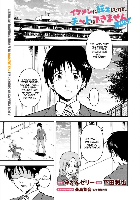


  ✅ Cell 10 সফল — Cell 11 চালানো যাবে


In [ ]:
# ═══════════════════════════════════════════════════════════
# 📤 CELL 10 — Input (Fixed)
# ═══════════════════════════════════════════════════════════

global uploaded_images, text_lines, CHECKPOINT

print("=" * 55)
print("  📤 MangaBD — Input")
print("=" * 55)
print()

# ── Fix: fresh import ──
from google.colab import files as colab_files

uploaded_images = {}
text_lines = []

print("  📂 মাঙ্গা ইমেজ আপলোড করো")
print("     (jpg, jpeg, png — একটি বা একাধিক)")
print()

try:
    upload_result = colab_files.upload()

    if not upload_result:
        print("  ❌ কোনো ফাইল upload হয়নি")
        print("  👉 আবার এই cell চালাও")
    else:
        success = 0
        fail = 0

        for filename, file_data in upload_result.items():
            ext = filename.lower().split('.')[-1] if '.' in filename else ''

            if ext not in ('jpg', 'jpeg', 'png', 'webp', 'bmp'):
                print(f"  ⚠️ {filename} — supported format না")
                fail += 1
                continue

            try:
                file_bytes = np.frombuffer(file_data, dtype=np.uint8)
                img_np = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

                if img_np is None or img_np.size == 0:
                    print(f"  ❌ {filename} — decode হয়নি")
                    fail += 1
                    continue

                img_h, img_w = img_np.shape[:2]

                if img_h < 50 or img_w < 50:
                    print(f"  ⚠️ {filename} — খুব ছোট ({img_w}×{img_h})")
                    fail += 1
                    continue

                uploaded_images[filename] = img_np

                if filename not in CHECKPOINT.get('pages', {}):
                    if 'pages' not in CHECKPOINT:
                        CHECKPOINT['pages'] = {}
                    CHECKPOINT['pages'][filename] = {
                        'regions': [], 'ocr_done': False,
                        'inpaint_done': False, 'render_done': False
                    }

                print(f"  ✅ {filename} ({img_w}×{img_h} px)")
                success += 1
                log_event(f"Image loaded: {filename} ({img_w}×{img_h})")

            except Exception as e:
                print(f"  ❌ {filename} — {str(e)[:50]}")
                fail += 1

        print()

        if success > 0:
            save_checkpoint()

            # Preview
            print(f"  📂 {success}টি ইমেজ লোড হয়েছে ✅")
            if fail > 0:
                print(f"  ⚠️ {fail}টি skip হয়েছে")
            print()

            for fname, img in uploaded_images.items():
                h, w = img.shape[:2]
                scale = min(300/w, 200/h, 1.0)
                nw, nh = int(w*scale), int(h*scale)
                thumb = cv2.resize(img, (nw, nh))
                thumb_rgb = cv2.cvtColor(thumb, cv2.COLOR_BGR2RGB)
                print(f"  📄 {fname} ({w}×{h}):")
                display(Image.fromarray(thumb_rgb))
                print()

            print("  ✅ Cell 10 সফল — Cell 11 চালানো যাবে")
        else:
            print("  ❌ কোনো ইমেজ লোড হয়নি")
            print("  👉 আবার এই cell চালাও")

except KeyboardInterrupt:
    print("\n  ⚠️ বাতিল — আবার চালাও")
except Exception as e:
    print(f"\n  ❌ Error: {str(e)[:60]}")
    print("  👉 আবার এই cell চালাও")

print("=" * 55)

  🔍 MangaBD — Detection + OCR

  📂 1টি ইমেজ process হবে
  🔤 শুধু English text ধরা হবে (জাপানি/কোরিয়ান বাদ)

  ╔═══════════════════════════════════════════╗
  ║  📄 [1/1] 01.jpg
  ╚═══════════════════════════════════════════╝

    🔎 Detection Level 1...
      🔍 EasyOCR detection (English only)...
         → 24 English regions
      🔍 OpenCV detection...
         → 3 regions
      📊 Raw total: 27
      ✅ Final: 6 regions

    📖 OCR + English filter চলছে...


    📖 OCR:   0%|          | 0/6 [00:00<?, ?it/s]


    🗺️ 01.jpg (6 English regions)
    🟢bubble 🟡thought 🔵narrator 🔴sfx 🟣overlay


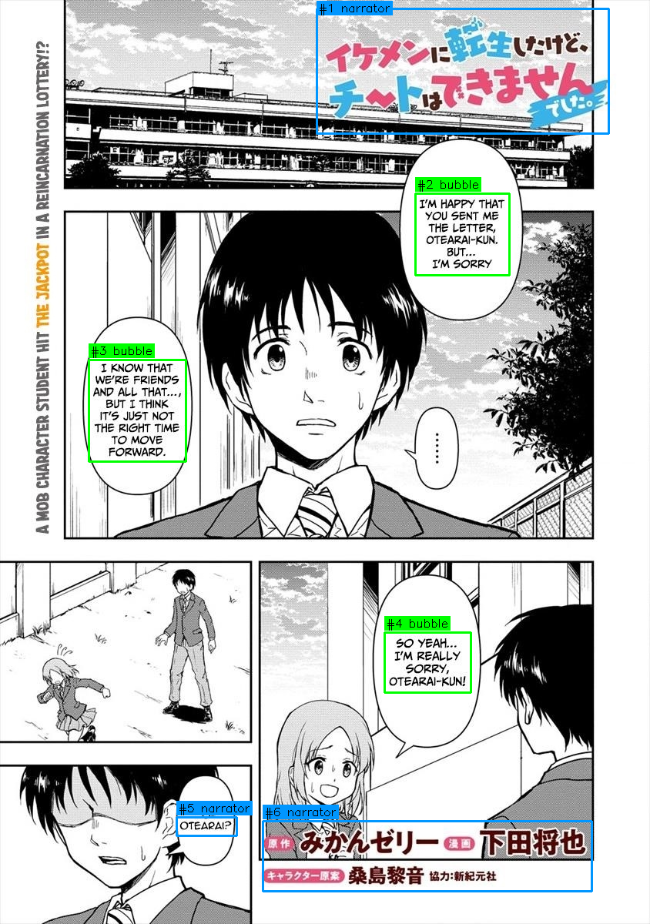


    ─── প্রতিটি Region-এর ছবি + OCR Text ───

      ┌── #1 📋 narrator ──
      │ OCR: "47 Ute."
      │ Conf: 🔴 0.49
      └────────────────


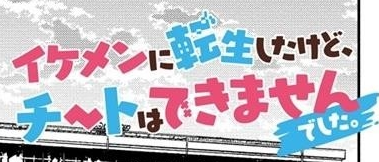


      ┌── #2 💬 bubble ──
      │ OCR: "I’M HAPPY THAT YOU SENT ME THE LETTER, OTEARAI-KUN. BUT... IM SORRY"
      │ Conf: 🟢 0.85
      └────────────────


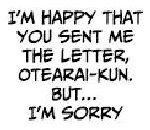


      ┌── #3 💬 bubble ──
      │ OCR: "T_KNOW THAT WE'RE FRIENDS AND ALL THAT..., BUT I THINK IS JUST NOT THE RIGHT TIME TO MOVE \ FORWARD. |"
      │ Conf: 🟡 0.78
      └────────────────


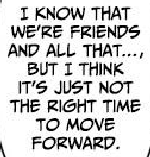


      ┌── #4 💬 bubble ──
      │ OCR: "50 YEAH... I’M REALLY SORRY, OTEARAI-KUN!"
      │ Conf: 🟢 0.84
      └────────────────


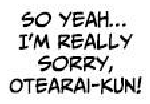


      ┌── #5 📋 narrator ──
      │ OCR: "OTEARAP?"
      │ Conf: 🔴 0.59
      └────────────────


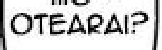


      ┌── #6 📋 narrator ──
      │ OCR: "POA EY — co RBS wren"
      │ Conf: 🔴 0.45
      └────────────────


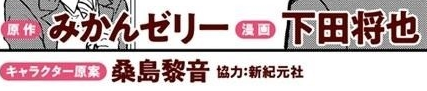


    ─── মোট 6 টি region ───

    📊 narrator: 3, bubble: 3
    💾 Checkpoint saved ✅

    ╔══════════════════════════════════════╗
    ║  ✅ সব ঠিক থাকলে Cell 12 চালাও      ║
    ║  ❌ সমস্যা থাকলে Cell 10 থেকে আবার  ║
    ╚══════════════════════════════════════╝


╔═════════════════════════════════════════════════════╗
║  📊 Overall Summary                                  ║
╚═════════════════════════════════════════════════════╝

  মোট English regions : 6
  Pages               : 1

    💬 bubble    : 3
    📋 narrator  : 3

    📖 EasyOCR: 0 | Tesseract: 0
    ⚠️ Low confidence: 3

  ✅ Cell 11 সফল — মোট 6 টি region
  👉 Cell 12 চালানো যাবে
═══════════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔍 CELL 11 — Detection + OCR + Visual Verification (V4)
# ═══════════════════════════════════════════════════════════
# 🆕 Fix: Button stuck সমস্যা সমাধান
# 🆕 Fix: শুধু English text — জাপানি/কোরিয়ান filter
# 🆕 প্রতিটি region crop + OCR text দেখাবে
# ═══════════════════════════════════════════════════════════

global translation_df, CHECKPOINT

print("=" * 55)
print("  🔍 MangaBD — Detection + OCR")
print("=" * 55)
print()

# ═══════════════════════════════════════════════════════════
# PART 1: HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════

def is_english_text(text):
    """
    Text English কিনা check করো।
    জাপানি, কোরিয়ান, চাইনিজ text বাদ দেবে।
    """
    if not text or not text.strip():
        return False

    text = text.strip()

    # শুধু special markers — রাখো
    if text in ['[SFX]', '[EMPTY]', '[OCR_FAILED]']:
        return True

    english_count = 0
    non_english_count = 0

    for ch in text:
        code = ord(ch)

        # English letters, numbers, punctuation, space
        if (0x0020 <= code <= 0x007E):  # Basic ASCII
            english_count += 1
        # Common punctuation
        elif ch in '…—–''""•·«»¡¿':
            english_count += 1
        # Japanese Hiragana (3040-309F)
        elif 0x3040 <= code <= 0x309F:
            non_english_count += 1
        # Japanese Katakana (30A0-30FF)
        elif 0x30A0 <= code <= 0x30FF:
            non_english_count += 1
        # CJK (Chinese/Japanese/Korean) (4E00-9FFF)
        elif 0x4E00 <= code <= 0x9FFF:
            non_english_count += 1
        # Korean Hangul (AC00-D7AF)
        elif 0xAC00 <= code <= 0xD7AF:
            non_english_count += 1
        # Korean Jamo (1100-11FF)
        elif 0x1100 <= code <= 0x11FF:
            non_english_count += 1
        # Japanese punctuation
        elif 0x3000 <= code <= 0x303F:
            non_english_count += 1
        # Fullwidth forms
        elif 0xFF00 <= code <= 0xFFEF:
            non_english_count += 1

    total = english_count + non_english_count

    if total == 0:
        return False

    # 50% English হলে রাখো
    english_ratio = english_count / total
    return english_ratio > 0.50


def merge_nearby_regions(regions, distance_threshold=15):
    """কাছাকাছি regions merge করো।"""
    if len(regions) <= 1:
        return regions
    try:
        merged = list(regions)
        changed = True
        while changed:
            changed = False
            new_merged = []
            used = set()
            for i in range(len(merged)):
                if i in used:
                    continue
                cx1, cy1, cw, ch = merged[i]
                cx2_end = cx1 + cw
                cy2_end = cy1 + ch
                for j in range(i + 1, len(merged)):
                    if j in used:
                        continue
                    ox1, oy1, ow, oh = merged[j]
                    ox2_end = ox1 + ow
                    oy2_end = oy1 + oh
                    v_gap = max(0, max(cy1, oy1) - min(cy2_end, oy2_end))
                    h_overlap = min(cx2_end, ox2_end) - max(cx1, ox1)
                    if v_gap < distance_threshold and h_overlap > -distance_threshold:
                        cx1 = min(cx1, ox1)
                        cy1 = min(cy1, oy1)
                        cx2_end = max(cx2_end, ox2_end)
                        cy2_end = max(cy2_end, oy2_end)
                        cw = cx2_end - cx1
                        ch = cy2_end - cy1
                        used.add(j)
                        changed = True
                new_merged.append((cx1, cy1, cw, ch))
                used.add(i)
            merged = new_merged
        return merged
    except Exception:
        return regions


def deduplicate_regions(regions):
    """Duplicate বাদ দাও।"""
    if len(regions) <= 1:
        return regions
    sorted_r = sorted(regions, key=lambda r: r[2] * r[3], reverse=True)
    keep = []
    removed = set()
    for i in range(len(sorted_r)):
        if i in removed:
            continue
        keep.append(sorted_r[i])
        for j in range(i + 1, len(sorted_r)):
            if j in removed:
                continue
            iou_val = iou(sorted_r[i], sorted_r[j])
            try:
                ax1, ay1, aw, ah = sorted_r[i]
                bx1, by1, bw, bh = sorted_r[j]
                ix1, iy1 = max(ax1, bx1), max(ay1, by1)
                ix2, iy2 = min(ax1+aw, bx1+bw), min(ay1+ah, by1+bh)
                if ix2 > ix1 and iy2 > iy1:
                    inter = (ix2-ix1)*(iy2-iy1)
                    smaller = min(aw*ah, bw*bh)
                    overlap_val = inter/smaller if smaller > 0 else 0
                else:
                    overlap_val = 0
            except Exception:
                overlap_val = 0
            if iou_val > CONFIG['iou_threshold'] or overlap_val > 0.70:
                removed.add(j)
    return keep


def add_padding_to_regions(regions, img_h, img_w, pad=4):
    """Padding যোগ করো।"""
    padded = []
    for (x, y, w, h) in regions:
        nx = max(0, x - pad)
        ny = max(0, y - pad)
        nw = min(img_w - nx, w + pad * 2)
        nh = min(img_h - ny, h + pad * 2)
        padded.append((nx, ny, nw, nh))
    return padded


# ═══════════════════════════════════════════════════════════
# PART 2: DETECTION (English only)
# ═══════════════════════════════════════════════════════════

def detect_english_regions(image_np, level=1):
    """
    শুধু English text regions detect করো।
    জাপানি/কোরিয়ান/চাইনিজ বাদ যাবে।
    """
    try:
        img_h, img_w = image_np.shape[:2]
        all_regions = []

        # ── EasyOCR (English only) ──
        print(f"      🔍 EasyOCR detection (English only)...")
        easyocr_count = 0
        try:
            if ocr_reader is not None:
                results = ocr_reader.readtext(image_np, detail=1, paragraph=False)
                for det in results:
                    if len(det) < 3:
                        continue
                    try:
                        text = str(det[1]).strip()
                        conf = float(det[2])

                        # English text filter
                        if not is_english_text(text):
                            continue

                        # খুব ছোট/meaningless text বাদ
                        clean = ''.join(c for c in text if c.isalnum())
                        if len(clean) < 2:
                            continue

                        bbox = det[0]
                        xs = [int(p[0]) for p in bbox]
                        ys = [int(p[1]) for p in bbox]
                        x, y = min(xs), min(ys)
                        w, h = max(xs) - x, max(ys) - y
                        if w > 5 and h > 5:
                            all_regions.append((x, y, w, h))
                            easyocr_count += 1
                    except Exception:
                        continue
            print(f"         → {easyocr_count} English regions")
        except Exception as e:
            print(f"         → ⚠️ Error: {str(e)[:40]}")

        # ── OpenCV ──
        print(f"      🔍 OpenCV detection...")
        opencv_count = 0
        try:
            gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            enhanced = clahe.apply(gray)
            binary = cv2.adaptiveThreshold(
                enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 11, 2
            )

            if level == 1:
                kernels = [(15, 8), (10, 5), (22, 10)]
            elif level == 2:
                kernels = [(12, 6), (8, 4), (18, 8), (6, 3), (25, 12)]
            else:
                kernels = [(10, 5), (6, 3), (15, 7), (4, 2), (20, 10), (8, 4)]

            for k in kernels:
                kernel = cv2.getStructuringElement(cv2.MORPH_RECT, k)
                dilated = cv2.dilate(binary, kernel, iterations=2)
                contours, _ = cv2.findContours(
                    dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )
                for cnt in contours:
                    x, y, w, h = cv2.boundingRect(cnt)
                    all_regions.append((x, y, w, h))
                    opencv_count += 1
            print(f"         → {opencv_count} regions")
        except Exception as e:
            print(f"         → ⚠️ Error: {str(e)[:40]}")

        # ── MSER (Level 2+) ──
        if level >= 2:
            print(f"      🔍 MSER detection...")
            try:
                mser = cv2.MSER_create()
                mser.setMinArea(50 if level == 2 else 30)
                mser.setMaxArea(img_w * img_h // 4)
                gray2 = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
                msers, _ = mser.detectRegions(gray2)
                mser_count = 0
                for region in msers:
                    x, y, w, h = cv2.boundingRect(region)
                    if w > 10 and h > 8:
                        all_regions.append((x, y, w, h))
                        mser_count += 1
                print(f"         → {mser_count} regions")
            except Exception:
                pass

        print(f"      📊 Raw total: {len(all_regions)}")

        if len(all_regions) == 0:
            return []

        # ── Filter ──
        min_w = CONFIG['min_region_width'] - (10 if level >= 2 else 0)
        min_h = CONFIG['min_region_height'] - (4 if level >= 2 else 0)
        min_w = max(10, min_w)
        min_h = max(6, min_h)

        filtered = []
        for (x, y, w, h) in all_regions:
            if w < min_w or h < min_h:
                continue
            if w > img_w * CONFIG['max_region_ratio'] and h > img_h * CONFIG['max_region_ratio']:
                continue
            if h > 0 and w / h > 20:
                continue
            if w > 0 and h / w > 20:
                continue
            filtered.append((x, y, w, h))

        if not filtered:
            return []

        # ── Merge + Dedup + Pad + Sort ──
        merged = merge_nearby_regions(filtered, 15)
        unique = deduplicate_regions(merged)
        padded = add_padding_to_regions(unique, img_h, img_w)
        sorted_regs = sorted(padded, key=lambda r: (r[1], r[0]))

        # ── Classify ──
        results = []
        for (x, y, w, h) in sorted_regs:
            region_type = classify_region(image_np, x, y, w, h)
            results.append({'x': x, 'y': y, 'width': w, 'height': h,
                           'region_type': region_type})

        print(f"      ✅ Final: {len(results)} regions")
        return results

    except Exception as e:
        log_event(f"Detection failed: {str(e)[:60]}", level='ERROR')
        return []


# ═══════════════════════════════════════════════════════════
# PART 3: VISUAL FUNCTIONS
# ═══════════════════════════════════════════════════════════

def draw_detection_map(image_np, regions, filename, title_extra=""):
    """Detection map দেখাও।"""
    try:
        marked = image_np.copy()
        color_map = {
            'bubble': (0,255,0), 'thought': (0,255,255),
            'narrator': (255,150,0), 'sfx': (0,0,255),
            'overlay': (255,0,255),
        }
        for i, reg in enumerate(regions, 1):
            x, y, w, h = reg['x'], reg['y'], reg['width'], reg['height']
            color = color_map.get(reg['region_type'], (255,255,255))
            cv2.rectangle(marked, (x,y), (x+w,y+h), color, 2)
            label = f"#{i} {reg['region_type']}"
            lsz = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]
            ly = max(y-5, lsz[1]+5)
            cv2.rectangle(marked, (x, ly-lsz[1]-4), (x+lsz[0]+4, ly+2), color, -1)
            cv2.putText(marked, label, (x+2, ly-2),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

        scale = min(CONFIG['preview_max_width'] / marked.shape[1], 1.0)
        dw, dh = int(marked.shape[1]*scale), int(marked.shape[0]*scale)
        resized = cv2.resize(marked, (dw, dh))
        rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)

        title = f"🗺️ {filename}"
        if title_extra:
            title += f" ({title_extra})"
        print(f"\n    {title}")
        print(f"    🟢bubble 🟡thought 🔵narrator 🔴sfx 🟣overlay")
        display(pil)
    except Exception as e:
        print(f"    ⚠️ Map error: {str(e)[:50]}")


def show_all_crops(image_np, regions, ocr_results):
    """প্রতিটি region-এর crop + OCR text দেখাও।"""
    try:
        img_h, img_w = image_np.shape[:2]
        type_emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                      'sfx':'💥','overlay':'📝'}

        print(f"\n    ─── প্রতিটি Region-এর ছবি + OCR Text ───")

        for i, (reg, ocr) in enumerate(zip(regions, ocr_results), 1):
            x, y, w, h = reg['x'], reg['y'], reg['width'], reg['height']
            rtype = reg['region_type']

            x1, y1 = max(0, x), max(0, y)
            x2, y2 = min(img_w, x+w), min(img_h, y+h)
            if x2 <= x1 or y2 <= y1:
                continue

            crop = image_np[y1:y2, x1:x2].copy()
            if crop.size == 0:
                continue

            # Scale up
            ch, cw = crop.shape[:2]
            s = min(max(1.0, 50/ch, 150/cw), 5.0)
            nw, nh = int(cw*s), int(ch*s)
            if nw > 500:
                ratio = 500/nw
                nw, nh = 500, int(nh*ratio)
            crop_r = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_NEAREST)
            crop_rgb = cv2.cvtColor(crop_r, cv2.COLOR_BGR2RGB)
            crop_pil = Image.fromarray(crop_rgb)

            emoji = type_emoji.get(rtype, '❓')
            ocr_text = ocr.get('text', '[EMPTY]')
            ocr_conf = ocr.get('confidence', 0.0)

            conf_icon = "🟢" if ocr_conf >= 0.80 else ("🟡" if ocr_conf >= 0.60 else "🔴")

            print(f"\n      ┌── #{i} {emoji} {rtype} ──")
            print(f"      │ OCR: \"{ocr_text}\"")
            print(f"      │ Conf: {conf_icon} {ocr_conf:.2f}")

            if ocr.get('flagged'):
                if ocr_text == '[SFX]':
                    print(f"      │ ⚠️ SFX — CSV-তে নিজে লেখো")
                elif ocr_text == '[EMPTY]':
                    print(f"      │ ⚠️ Empty — ইমেজ দেখে CSV-তে লেখো")
                elif ocr_text == '[OCR_FAILED]':
                    print(f"      │ ❌ Failed — CSV-তে নিজে লেখো")

            print(f"      └────────────────")
            display(crop_pil)

        print(f"\n    ─── মোট {len(regions)} টি region ───")
    except Exception as e:
        print(f"    ⚠️ Crop display error: {str(e)[:50]}")


# ═══════════════════════════════════════════════════════════
# PART 4: OCR WITH ENGLISH FILTER
# ═══════════════════════════════════════════════════════════

def run_ocr_english_only(image_np, regions):
    """
    OCR চালাও + non-English results filter করো।
    Returns: (filtered_regions, ocr_results)
    """
    final_regions = []
    final_ocr = []

    for reg in tqdm(regions, desc="    📖 OCR", leave=True):
        try:
            result = run_ocr(
                image_np, reg['x'], reg['y'],
                reg['width'], reg['height'],
                reg['region_type']
            )
        except Exception:
            result = {'text':'[OCR_FAILED]', 'confidence':0.0,
                     'method':'failed', 'flagged':True}

        ocr_text = result.get('text', '')

        # English filter (SFX/EMPTY/FAILED রাখো)
        if ocr_text in ['[SFX]', '[EMPTY]', '[OCR_FAILED]']:
            final_regions.append(reg)
            final_ocr.append(result)
        elif is_english_text(ocr_text):
            final_regions.append(reg)
            final_ocr.append(result)
        else:
            # Non-English — skip
            pass

    return final_regions, final_ocr


# ═══════════════════════════════════════════════════════════
# PART 5: MAIN PIPELINE (NO BLOCKING WAIT)
# ═══════════════════════════════════════════════════════════

has_images = len(uploaded_images) > 0
has_text = len(text_lines) > 0

if not has_images and not has_text:
    print("  ❌ কোনো input নেই! আগে Cell 10 চালাও")
    print("=" * 55)
else:
    records = []
    region_id = 1
    total_stats = {
        'bubble':0, 'thought':0, 'narrator':0, 'sfx':0, 'overlay':0,
        'low_conf':0, 'skipped':0, 'failed':0,
        'easyocr':0, 'tesseract':0, 'filtered_non_english':0,
    }

    if has_images:
        print(f"  📂 {len(uploaded_images)}টি ইমেজ process হবে")
        print(f"  🔤 শুধু English text ধরা হবে (জাপানি/কোরিয়ান বাদ)")
        print()

        for page_idx, (filename, img_np) in enumerate(uploaded_images.items(), 1):

            print(f"  ╔═══════════════════════════════════════════╗")
            print(f"  ║  📄 [{page_idx}/{len(uploaded_images)}] {filename}")
            print(f"  ╚═══════════════════════════════════════════╝")

            # Resume check
            if is_page_done(filename, 'ocr'):
                print(f"    ⏭️ Checkpoint skip")
                try:
                    saved = CHECKPOINT['pages'].get(filename, {}).get('regions', [])
                    if saved:
                        for reg in saved:
                            rc = reg.copy()
                            rc['id'] = region_id
                            records.append(rc)
                            region_id += 1
                        print(f"    📊 {len(saved)} regions loaded")
                except Exception:
                    reset_page(filename)
                if is_page_done(filename, 'ocr'):
                    print()
                    continue

            # ── Level 1 Detection ──
            print(f"\n    🔎 Detection Level 1...")
            regions = detect_english_regions(img_np, level=1)

            if len(regions) == 0:
                print(f"    🔎 Level 1 empty, trying Level 2...")
                regions = detect_english_regions(img_np, level=2)

            if len(regions) == 0:
                print(f"    🔎 Level 2 empty, trying Level 3...")
                regions = detect_english_regions(img_np, level=3)

            if len(regions) == 0:
                print(f"    ⚠️ কোনো region পাওয়া যায়নি")
                mark_page_done(filename, 'ocr')
                print()
                continue

            # ── OCR + English Filter ──
            print(f"\n    📖 OCR + English filter চলছে...")
            before_count = len(regions)
            regions, ocr_results = run_ocr_english_only(img_np, regions)
            after_count = len(regions)

            filtered_out = before_count - after_count
            if filtered_out > 0:
                print(f"    🔤 {filtered_out} টি non-English region বাদ দেওয়া হয়েছে")
                total_stats['filtered_non_english'] += filtered_out

            if len(regions) == 0:
                print(f"    ⚠️ কোনো English text পাওয়া যায়নি")
                mark_page_done(filename, 'ocr')
                print()
                continue

            # ── Detection Map ──
            draw_detection_map(img_np, regions, filename,
                              f"{len(regions)} English regions")

            # ── Region Crops + OCR Text ──
            show_all_crops(img_np, regions, ocr_results)

            # ── Build Records ──
            page_records = []
            for reg, ocr in zip(regions, ocr_results):
                record = {
                    'id': region_id, 'page': filename,
                    'x': reg['x'], 'y': reg['y'],
                    'width': reg['width'], 'height': reg['height'],
                    'region_type': reg['region_type'],
                    'original_text': ocr['text'],
                    'confidence': round(ocr['confidence'], 2),
                    'ocr_method': ocr['method'],
                    'low_confidence': ocr['confidence'] < CONFIG['ocr_confidence_threshold'],
                    'needs_review': ocr['flagged'],
                    'translated_text': ''
                }
                records.append(record)
                page_records.append(record)
                region_id += 1

                rtype = reg['region_type']
                if rtype in total_stats:
                    total_stats[rtype] += 1
                if ocr['confidence'] < CONFIG['ocr_confidence_threshold']:
                    total_stats['low_conf'] += 1
                if ocr['method'] == 'easyocr':
                    total_stats['easyocr'] += 1
                elif ocr['method'] == 'tesseract':
                    total_stats['tesseract'] += 1
                elif ocr['method'] == 'skipped':
                    total_stats['skipped'] += 1
                elif ocr['method'] == 'failed':
                    total_stats['failed'] += 1

            # ── Checkpoint ──
            try:
                CHECKPOINT['pages'][filename]['regions'] = page_records
                mark_page_done(filename, 'ocr')
            except Exception:
                save_checkpoint()

            # ── Page Summary ──
            page_types = {}
            for rec in page_records:
                rt = rec['region_type']
                page_types[rt] = page_types.get(rt, 0) + 1
            type_str = ', '.join([f"{t}: {c}" for t, c in page_types.items()])
            print(f"\n    📊 {type_str}")
            print(f"    💾 Checkpoint saved ✅")

            # ── সমস্যা থাকলে জানাও ──
            print()
            print(f"    ╔══════════════════════════════════════╗")
            print(f"    ║  ✅ সব ঠিক থাকলে Cell 12 চালাও      ║")
            print(f"    ║  ❌ সমস্যা থাকলে Cell 10 থেকে আবার  ║")
            print(f"    ╚══════════════════════════════════════╝")
            print()

            gc.collect()

    # ── Text-only mode ──
    if has_text and not has_images:
        print(f"  📝 Text-only: {len(text_lines)} lines")
        for i, line in enumerate(text_lines, 1):
            records.append({
                'id': region_id, 'page': 'text_only',
                'x': 0, 'y': 0, 'width': 0, 'height': 0,
                'region_type': 'text_only', 'original_text': line,
                'confidence': 1.0, 'ocr_method': 'manual',
                'low_confidence': False, 'needs_review': False,
                'translated_text': ''
            })
            region_id += 1
            print(f"    {i}. {line[:50]}")

    # ── DataFrame ──
    if records:
        translation_df = pd.DataFrame(records)

        print()
        print("╔" + "═" * 53 + "╗")
        print("║  📊 Overall Summary" + " " * 34 + "║")
        print("╚" + "═" * 53 + "╝")
        print()
        print(f"  মোট English regions : {len(translation_df)}")

        if has_images:
            print(f"  Pages               : {len(uploaded_images)}")
            if total_stats['filtered_non_english'] > 0:
                print(f"  🔤 Non-English বাদ  : {total_stats['filtered_non_english']}")
            print()
            for key in ['bubble','thought','narrator','sfx','overlay']:
                count = total_stats[key]
                if count > 0:
                    emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                             'sfx':'💥','overlay':'📝'}[key]
                    print(f"    {emoji} {key:10s}: {count}")
            print()
            print(f"    📖 EasyOCR: {total_stats['easyocr']} | "
                  f"Tesseract: {total_stats['tesseract']}")
            if total_stats['low_conf'] > 0:
                print(f"    ⚠️ Low confidence: {total_stats['low_conf']}")

        print()
        print(f"  ✅ Cell 11 সফল — মোট {len(translation_df)} টি region")
        print(f"  👉 Cell 12 চালানো যাবে")
        print("═" * 55)

        log_event(f"Detection+OCR: {len(translation_df)} English regions")
    else:
        translation_df = pd.DataFrame()
        print("  ❌ কোনো English region পাওয়া যায়নি")
        print("  👉 Cell 10 থেকে আবার চেষ্টা করো")
        print("=" * 55)

In [ ]:
# ═══════════════════════════════════════════════════════════
# 💾 CELL 12 — JSON & CSV Export (Fixed)
# ═══════════════════════════════════════════════════════════

from google.colab import files as colab_files

print("=" * 55)
print("  💾 MangaBD — JSON & CSV Export")
print("=" * 55)
print()

if translation_df is None or len(translation_df) == 0:
    print("  ❌ কোনো data নেই! আগে Cell 11 চালাও")
    print("=" * 55)
else:
    # ── JSON Export ──
    json_path = 'manga_to_translate.json'
    json_ok = False

    try:
        json_data = {
            'project': 'MangaBD',
            'instruction': 'Translate original_text to Bengali. Write in translated_text.',
            'total_regions': len(translation_df),
            'regions': []
        }

        for _, row in translation_df.iterrows():
            region = {
                'id': int(row['id']),
                'page': str(row['page']),
                'x': int(row['x']), 'y': int(row['y']),
                'width': int(row['width']), 'height': int(row['height']),
                'region_type': str(row['region_type']),
                'original_text': str(row['original_text']),
                'confidence': float(row['confidence']),
                'needs_review': bool(row['needs_review']),
                'translated_text': ''
            }
            json_data['regions'].append(region)

        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, ensure_ascii=False, indent=2)

        json_size = os.path.getsize(json_path)
        json_ok = True
        print(f"  📋 JSON: {json_path} ({json_size // 1024} KB) ✅")
    except Exception as e:
        print(f"  ❌ JSON failed: {str(e)[:50]}")

    # ── AI-Ready Text ──
    ai_path = 'manga_for_ai.txt'
    ai_ok = False

    try:
        lines_out = [
            "=" * 50,
            "MangaBD — English to Bengali Translation",
            "=" * 50, "",
            "INSTRUCTION: Translate each English text to Bengali.",
            "Keep the ID numbers. Write Bengali after →", "",
            "-" * 50, ""
        ]

        for _, row in translation_df.iterrows():
            rid = int(row['id'])
            orig = str(row['original_text']).strip()
            if orig in ['[EMPTY]', '[OCR_FAILED]']:
                continue
            if orig == '[SFX]':
                lines_out.append(f"[{rid}] (SFX sound effect) → ")
            else:
                lines_out.append(f"[{rid}] {orig} → ")

        lines_out.extend(["", "-" * 50])

        with open(ai_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines_out))

        ai_ok = True
        print(f"  🤖 AI Text: {ai_path} ✅")
    except Exception as e:
        print(f"  ⚠️ AI text failed: {str(e)[:50]}")

    # ── CSV Export ──
    csv_path = CONFIG['csv_filename']
    csv_ok = False

    try:
        translation_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
        csv_ok = True
        print(f"  📄 CSV: {csv_path} ✅")
    except Exception as e:
        print(f"  ⚠️ CSV failed: {str(e)[:50]}")

    # ── Summary ──
    print()
    total = len(translation_df)
    type_emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                  'sfx':'💥','overlay':'📝','text_only':'📝'}

    print(f"  📊 মোট regions: {total}")
    for rtype, count in translation_df['region_type'].value_counts().items():
        emoji = type_emoji.get(rtype, '❓')
        print(f"    {emoji} {rtype:10s}: {count}")

    # ── Preview ──
    print()
    print(f"  📝 Preview:")
    for _, row in translation_df.head(8).iterrows():
        rid = row['id']
        orig = str(row['original_text'])[:40]
        rtype = row['region_type']
        emoji = type_emoji.get(rtype, '❓')
        status = "🔴" if row['needs_review'] else ("🟡" if row['low_confidence'] else "🟢")
        print(f"    {status} [{rid:2d}] {emoji} \"{orig}\"")

    # ── AI Format Preview ──
    print()
    print(f"  🤖 AI-তে paste করো:")
    print(f"  ┌─────────────────────────────────")
    shown = 0
    for _, row in translation_df.iterrows():
        orig = str(row['original_text']).strip()
        if orig in ['[EMPTY]', '[OCR_FAILED]']:
            continue
        rid = int(row['id'])
        print(f"  │ [{rid}] {orig} → ")
        shown += 1
        if shown >= 5:
            print(f"  │ ...")
            break
    print(f"  └─────────────────────────────────")

    # ── Download ──
    print()
    print(f"  📥 Download:")

    try:
        if json_ok:
            colab_files.download(json_path)
            print(f"  ✅ {json_path}")
        if ai_ok:
            colab_files.download(ai_path)
            print(f"  ✅ {ai_path}")
        if csv_ok:
            colab_files.download(csv_path)
            print(f"  ✅ {csv_path}")
    except Exception:
        print(f"  ⚠️ Auto-download হয়নি")
        print(f"     👉 বাম পাশে 📁 Files tab থেকে download করো")

    # ── Instructions ──
    print()
    print("╔" + "═" * 53 + "╗")
    print("║  📋 এখন তোমার কাজ:                                ║")
    print("║  1. JSON/TXT download করো                          ║")
    print("║  2. translated_text field-এ বাংলা লেখো            ║")
    print("║  3. অথবা AI-তে txt paste করে translate করো        ║")
    print("║  4. Cell 13 চালাও এবং file upload করো             ║")
    print("╚" + "═" * 53 + "╝")

    print()
    print("  ✅ Cell 12 সফল — অনুবাদ শেষে Cell 13 চালাও")
    print("=" * 55)

  💾 MangaBD — JSON & CSV Export

  📋 JSON: manga_to_translate.json (1 KB) ✅
  🤖 AI Text: manga_for_ai.txt ✅
  📄 CSV: manga_to_translate.csv ✅

  📊 মোট regions: 6
    📋 narrator  : 3
    💬 bubble    : 3

  📝 Preview:
    🔴 [ 1] 📋 "47 Ute."
    🟢 [ 2] 💬 "I’M HAPPY THAT YOU SENT ME THE LETTER, O"
    🟢 [ 3] 💬 "T_KNOW THAT WE'RE FRIENDS AND ALL THAT.."
    🟢 [ 4] 💬 "50 YEAH... I’M REALLY SORRY, OTEARAI-KUN"
    🔴 [ 5] 📋 "OTEARAP?"
    🔴 [ 6] 📋 "POA EY — co RBS wren"

  🤖 AI-তে paste করো:
  ┌─────────────────────────────────
  │ [1] 47 Ute. → 
  │ [2] I’M HAPPY THAT YOU SENT ME THE LETTER, OTEARAI-KUN. BUT... IM SORRY → 
  │ [3] T_KNOW THAT WE'RE FRIENDS AND ALL THAT..., BUT I THINK IS JUST NOT THE RIGHT TIME TO MOVE \ FORWARD. | → 
  │ [4] 50 YEAH... I’M REALLY SORRY, OTEARAI-KUN! → 
  │ [5] OTEARAP? → 
  │ ...
  └─────────────────────────────────

  📥 Download:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ manga_to_translate.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ manga_for_ai.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ manga_to_translate.csv

╔═════════════════════════════════════════════════════╗
║  📋 এখন তোমার কাজ:                                ║
║  1. JSON/TXT download করো                          ║
║  2. translated_text field-এ বাংলা লেখো            ║
║  3. অথবা AI-তে txt paste করে translate করো        ║
║  4. Cell 13 চালাও এবং file upload করো             ║
╚═════════════════════════════════════════════════════╝

  ✅ Cell 12 সফল — অনুবাদ শেষে Cell 13 চালাও


In [ ]:
# ═══════════════════════════════════════════════════════════
# 📤 CELL 13 — Translation Upload (Fixed)
# ═══════════════════════════════════════════════════════════

from google.colab import files as colab_files
global translation_df

print("=" * 55)
print("  📤 MangaBD — Translation Upload")
print("=" * 55)
print()

if translation_df is None or len(translation_df) == 0:
    print("  ❌ আগে Cell 11 ও Cell 12 চালাও")
    print("=" * 55)
else:
    original_count = len(translation_df)
    print(f"  📊 আগের data: {original_count} টি region")
    print()
    print("  📂 অনুবাদ করা file upload করো")
    print("     (.json / .csv / .xlsx / .txt)")
    print()

    try:
        upload_result = colab_files.upload()

        if not upload_result:
            print("  ❌ কোনো file upload হয়নি")
            print("=" * 55)
        else:
            fname = list(upload_result.keys())[0]
            fdata = upload_result[fname]
            ext = fname.lower().split('.')[-1] if '.' in fname else ''

            print(f"  ✅ Upload: {fname} ({len(fdata) // 1024} KB)")
            print()

            translations = {}
            parse_ok = False

            # ── JSON ──
            if ext == 'json':
                print(f"  📋 JSON parsing...")
                try:
                    jc = json.loads(fdata.decode('utf-8'))
                    if 'regions' in jc:
                        for r in jc['regions']:
                            rid = int(r.get('id', 0))
                            t = str(r.get('translated_text', '')).strip()
                            if t:
                                translations[rid] = t
                    elif isinstance(jc, dict):
                        for k, v in jc.items():
                            try:
                                translations[int(k)] = str(v).strip()
                            except (ValueError, TypeError):
                                pass
                    if translations:
                        parse_ok = True
                        print(f"  ✅ {len(translations)} translations")
                except Exception as e:
                    print(f"  ❌ JSON error: {str(e)[:50]}")

            # ── TXT ──
            elif ext == 'txt':
                print(f"  📝 Text parsing...")
                try:
                    text = fdata.decode('utf-8')
                    for line in text.split('\n'):
                        line = line.strip()
                        if '→' in line and '[' in line and ']' in line:
                            try:
                                rid = int(line.split(']')[0].replace('[','').strip())
                                trans = line.split('→')[-1].strip()
                                if trans:
                                    translations[rid] = trans
                            except (ValueError, IndexError):
                                pass
                    if translations:
                        parse_ok = True
                        print(f"  ✅ {len(translations)} translations")
                except Exception as e:
                    print(f"  ❌ Text error: {str(e)[:50]}")

            # ── CSV / Excel ──
            elif ext in ('csv', 'xlsx', 'xls'):
                print(f"  📄 {'Excel' if 'xls' in ext else 'CSV'} parsing...")
                try:
                    if 'xls' in ext:
                        df = pd.read_excel(io.BytesIO(fdata), engine='openpyxl')
                    else:
                        for enc in ['utf-8-sig', 'utf-8', 'cp1252', 'latin-1']:
                            try:
                                df = pd.read_csv(io.BytesIO(fdata), encoding=enc)
                                if len(df.columns) >= 3:
                                    break
                            except Exception:
                                continue

                    df.columns = [str(c).strip().lower().replace(' ','_') for c in df.columns]

                    if 'id' in df.columns and 'translated_text' in df.columns:
                        for _, row in df.iterrows():
                            try:
                                rid = int(row['id'])
                                t = str(row['translated_text']).strip()
                                if t and t != 'nan':
                                    translations[rid] = t
                            except (ValueError, TypeError):
                                pass

                    if translations:
                        parse_ok = True
                        print(f"  ✅ {len(translations)} translations")
                except Exception as e:
                    print(f"  ❌ Parse error: {str(e)[:50]}")

            else:
                print(f"  ❌ Unknown: .{ext} — json/txt/csv/xlsx supported")

            # ── Apply ──
            if parse_ok and translations:
                print()
                applied = 0
                for rid, trans in translations.items():
                    mask = translation_df['id'] == rid
                    if mask.any():
                        translation_df.loc[mask, 'translated_text'] = trans
                        applied += 1

                # Empty fill
                empty_filled = 0
                for idx in translation_df.index:
                    t = str(translation_df.loc[idx, 'translated_text']).strip()
                    if not t or t == 'nan':
                        orig = str(translation_df.loc[idx, 'original_text']).strip()
                        if orig not in ['[EMPTY]', '[OCR_FAILED]', '[SFX]']:
                            translation_df.loc[idx, 'translated_text'] = orig
                            empty_filled += 1
                        else:
                            translation_df.loc[idx, 'translated_text'] = orig

                print(f"  ✅ Applied: {applied}")
                if empty_filled > 0:
                    print(f"  ⚠️ Auto-filled: {empty_filled}")

                # Bangla check
                bangla = sum(1 for _, r in translation_df.iterrows()
                            if any('\u0980' <= ch <= '\u09FF'
                                   for ch in str(r.get('translated_text',''))))
                print(f"  🔤 বাংলা: {bangla} regions")

                # Preview
                print()
                print(f"  📝 Preview:")
                type_emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                              'sfx':'💥','overlay':'📝','text_only':'📝'}

                for _, row in translation_df.head(8).iterrows():
                    rid = row['id']
                    orig = str(row.get('original_text',''))[:20]
                    trans = str(row.get('translated_text',''))[:20]
                    rtype = str(row.get('region_type',''))
                    emoji = type_emoji.get(rtype, '❓')
                    has = trans and trans not in ['[EMPTY]','[SFX]','[OCR_FAILED]','','nan'] and trans != orig
                    print(f"    {'✅' if has else '⚠️'} [{rid:2d}] {emoji} \"{orig}\" → \"{trans}\"")

                save_checkpoint()
                print()
                print("  ✅ Cell 13 সফল — Cell 14 চালানো যাবে")
            else:
                print()
                print("  ⚠️ কোনো translation পাওয়া যায়নি")
                print("  👉 সঠিক format-এ file upload করো")

    except KeyboardInterrupt:
        print("\n  ⚠️ বাতিল — আবার চালাও")
    except Exception as e:
        print(f"\n  ❌ Error: {str(e)[:60]}")
        print("  👉 আবার এই cell চালাও")

    print("=" * 55)

  📤 MangaBD — Translation Upload

  📊 আগের data: 6 টি region

  📂 অনুবাদ করা file upload করো
     (.json / .csv / .xlsx / .txt)



Saving manga_2for_ai.txt to manga_2for_ai.txt
  ✅ Upload: manga_2for_ai.txt (1 KB)

  📝 Text parsing...
  ✅ 1 translations

  ✅ Applied: 1
  ⚠️ Auto-filled: 5
  🔤 বাংলা: 1 regions

  📝 Preview:
    ✅ [ 1] 📋 "47 Ute." → "৪৭... (অস্পষ্ট/সম্ভব"
    ⚠️ [ 2] 💬 "I’M HAPPY THAT YOU S" → "I’M HAPPY THAT YOU S"
    ⚠️ [ 3] 💬 "T_KNOW THAT WE'RE FR" → "T_KNOW THAT WE'RE FR"
    ⚠️ [ 4] 💬 "50 YEAH... I’M REALL" → "50 YEAH... I’M REALL"
    ⚠️ [ 5] 📋 "OTEARAP?" → "OTEARAP?"
    ⚠️ [ 6] 📋 "POA EY — co RBS wren" → "POA EY — co RBS wren"

  ✅ Cell 13 সফল — Cell 14 চালানো যাবে


In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔄 CHECKPOINT RESET — এটা চালাও তারপর Cell 14 আবার চালাও
# ═══════════════════════════════════════════════════════════

print("🔄 Checkpoint Reset...")
print()

# সব page-এর inpaint ও render checkpoint reset করো
for filename in list(CHECKPOINT.get('pages', {}).keys()):
    if filename in CHECKPOINT['pages']:
        CHECKPOINT['pages'][filename]['inpaint_done'] = False
        CHECKPOINT['pages'][filename]['render_done'] = False
        print(f"  ✅ {filename}: inpaint + render reset")

# Inpainted files মুছে দাও
import glob
for f in glob.glob('inpainted_*'):
    try:
        os.remove(f)
        print(f"  🗑️ {f} deleted")
    except:
        pass

for f in glob.glob('translated_*'):
    try:
        os.remove(f)
        print(f"  🗑️ {f} deleted")
    except:
        pass

save_checkpoint()

print()
print("✅ Reset done!")
print("👉 এখন Cell 14 আবার চালাও")

In [ ]:
# ═══════════════════════════════════════════════════════════
# ✂️ CELL 14 — Full Page Inpainting (Comic Text Mask)
# ═══════════════════════════════════════════════════════════
# ⭐ Comic Text Detector-এর pixel mask দিয়ে পুরো page
#    একবারে inpaint — শুধু text pixel মুছবে
# 🆕 Full page mode: সবচেয়ে ভালো result
# 🆕 Per-region fallback: mask না থাকলে
# 🆕 Before/After + Mask visualization
#
# Global variables used:
#   uploaded_images, translation_df, inpainted_images,
#   page_text_masks, CHECKPOINT, CONFIG, session_log,
#   lama_model, comic_detector_session
# ═══════════════════════════════════════════════════════════

global inpainted_images

print("=" * 55)
print("  ✂️ MangaBD — Full Page Inpainting")
print("=" * 55)
print()

if translation_df is None or len(translation_df) == 0:
    print("  ❌ Translation data নেই! আগে Cell 13 চালাও")
    print("=" * 55)
elif len(uploaded_images) == 0:
    print("  ❌ কোনো ইমেজ নেই! আগে Cell 10 চালাও")
    print("=" * 55)
else:
    inpainted_images = {}
    inpaint_stats = {}

    total_pages = len(uploaded_images)
    has_comic = comic_detector_session is not None

    print(f"  📂 {total_pages} টি page process হবে")
    print(f"  🎯 Comic Text Detector: {'✅ Active' if has_comic else '❌ Not available'}")
    print(f"  🎨 LaMa: {'✅ Active' if lama_model is not None else '⚠️ OpenCV fallback'}")
    print()

    if has_comic:
        print(f"  ⭐ Full Page Mode:")
        print(f"     → পুরো page-এর text একবারে মুছবে")
        print(f"     → শুধু text pixel (comic mask)")
        print(f"     → চেহারা/artwork/bubble border অক্ষত")
    else:
        print(f"  🔧 Per-Region Mode:")
        print(f"     → Region-by-region process")
    print()

    for page_idx, (filename, img_np) in enumerate(uploaded_images.items(), 1):

        print(f"  ╔═══════════════════════════════════════════╗")
        print(f"  ║  📄 [{page_idx}/{total_pages}] {filename}")
        print(f"  ╚═══════════════════════════════════════════╝")

        # ── Resume Check ──
        if is_page_done(filename, 'inpaint'):
            saved_path = f'inpainted_{filename}'
            if os.path.exists(saved_path):
                try:
                    loaded = cv2.imread(saved_path)
                    if loaded is not None and loaded.size > 0:
                        inpainted_images[filename] = loaded
                        print(f"    ⏭️ Checkpoint load")
                        print()
                        continue
                except Exception:
                    pass
            reset_page(filename)

        page_df = translation_df[translation_df['page'] == filename]

        if len(page_df) == 0:
            inpainted_images[filename] = img_np.copy()
            mark_page_done(filename, 'inpaint')
            print(f"    ⚠️ কোনো region নেই")
            print()
            continue

        print(f"    📊 {len(page_df)} টি text region")

        # ══════════════════════════════════════════════
        # STEP 1: Generate Comic Text Mask
        # ══════════════════════════════════════════════

        page_mask_available = False

        if has_comic:
            print(f"\n    🎯 Comic Text Detector চলছে...")

            try:
                comic_result = comic_detect(img_np)

                if comic_result is not None:
                    text_mask = comic_result['text_mask']
                    bubble_mask = comic_result.get('bubble_mask', None)

                    text_pixels = np.sum(text_mask > 0)
                    total_pixels = text_mask.size
                    text_ratio = text_pixels / total_pixels if total_pixels > 0 else 0

                    print(f"    ✅ Text mask generated!")
                    print(f"       Text pixels: {text_pixels:,} ({text_ratio:.2%} of image)")

                    if bubble_mask is not None:
                        bubble_pixels = np.sum(bubble_mask > 0)
                        print(f"       Bubble pixels: {bubble_pixels:,}")

                    # Store for this page
                    page_text_masks[filename] = {
                        'text_mask': text_mask,
                        'bubble_mask': bubble_mask,
                        'text_det_mask': comic_result.get('text_det_mask', None)
                    }
                    page_text_masks['current'] = page_text_masks[filename]

                    page_mask_available = True

                else:
                    print(f"    ⚠️ Comic detector failed — fallback mode")

            except Exception as e:
                print(f"    ⚠️ Comic detector error: {str(e)[:40]}")

        # ══════════════════════════════════════════════
        # STEP 2: INPAINTING
        # ══════════════════════════════════════════════

        work = img_np.copy()
        method_used = 'none'

        if page_mask_available:
            # ⭐ FULL PAGE MODE — Best approach
            print(f"\n    ⭐ Full page inpainting (comic mask)...")

            result, method = inpaint_full_page(work, filename)

            if result is not None:
                work = result
                method_used = method
                print(f"    ✅ Full page inpaint: {method}")
                inpaint_stats['full_page_comic'] = inpaint_stats.get('full_page_comic', 0) + 1
            else:
                print(f"    ⚠️ Full page failed ({method}) — per-region fallback")
                method_used = 'per_region_fallback'

        if method_used in ('none', 'per_region_fallback', 'no_mask', 'all_failed', 'error'):
            # 🔧 PER-REGION MODE — Fallback
            print(f"\n    🔧 Per-region inpainting...")

            page_methods = []

            for _, row in tqdm(list(page_df.iterrows()),
                               desc="    ✂️ Processing",
                               leave=True):

                x = int(row['x'])
                y = int(row['y'])
                w = int(row['width'])
                h = int(row['height'])
                rtype = str(row.get('region_type', 'overlay'))

                if w <= 0 or h <= 0:
                    page_methods.append('skipped')
                    continue

                work, m = smart_remove_text(work, x, y, w, h, rtype)
                page_methods.append(m)
                inpaint_stats[m] = inpaint_stats.get(m, 0) + 1

            # Methods summary
            mc = {}
            for m in page_methods:
                mc[m] = mc.get(m, 0) + 1

            print(f"\n    📊 Per-region methods:")
            for m, c in mc.items():
                print(f"      {m}: {c}")

        # ── Save result ──
        inpainted_images[filename] = work

        try:
            cv2.imwrite(f'inpainted_{filename}', work)
        except Exception:
            pass

        mark_page_done(filename, 'inpaint')

        # ══════════════════════════════════════════════
        # STEP 3: PREVIEW
        # ══════════════════════════════════════════════

        img_h, img_w = img_np.shape[:2]
        scale = min(CONFIG['preview_max_width'] / img_w, 1.0)
        dw, dh = int(img_w * scale), int(img_h * scale)

        # ── Show text mask (if available) ──
        if page_mask_available:
            print(f"\n    📸 TEXT MASK (লাল = যেটুকু মুছবে):")
            try:
                mask_viz = cv2.cvtColor(img_np.copy(), cv2.COLOR_BGR2RGB)
                tm = page_text_masks.get(filename, {}).get('text_mask', None)

                if tm is not None:
                    # Red overlay where text detected
                    mask_viz[tm > 0] = [255, 50, 50]

                mask_r = cv2.resize(mask_viz, (dw, dh))
                display(Image.fromarray(mask_r))
            except Exception:
                pass

        # ── Before ──
        print(f"\n    📸 BEFORE (Original):")
        before_r = cv2.resize(img_np, (dw, dh))
        before_rgb = cv2.cvtColor(before_r, cv2.COLOR_BGR2RGB)
        display(Image.fromarray(before_rgb))

        # ── After ──
        print(f"\n    📸 AFTER (Text Removed):")
        after_r = cv2.resize(work, (dw, dh))
        after_rgb = cv2.cvtColor(after_r, cv2.COLOR_BGR2RGB)
        display(Image.fromarray(after_rgb))

        # ── Closeup ──
        print(f"\n    🔍 Closeup (আগে → পরে):")

        show_n = min(5, len(page_df))
        for ci, (_, row) in enumerate(page_df.head(show_n).iterrows()):
            x, y = int(row['x']), int(row['y'])
            w, h = int(row['width']), int(row['height'])
            orig = str(row.get('original_text', ''))[:20]

            if w <= 5 or h <= 5:
                continue

            try:
                oh, ow = img_np.shape[:2]
                wh, ww = work.shape[:2]
                y1, y2 = max(0,y), min(min(oh,wh), y+h)
                x1, x2 = max(0,x), min(min(ow,ww), x+w)
                if y2<=y1 or x2<=x1:
                    continue

                oc = cv2.cvtColor(img_np[y1:y2,x1:x2].copy(), cv2.COLOR_BGR2RGB)
                rc = cv2.cvtColor(work[y1:y2,x1:x2].copy(), cv2.COLOR_BGR2RGB)

                # Mask crop (if available)
                mask_crop = None
                if page_mask_available:
                    tm = page_text_masks.get(filename, {}).get('text_mask', None)
                    if tm is not None:
                        mc = tm[y1:y2, x1:x2]
                        mask_crop = oc.copy()
                        mask_crop[mc > 0] = [255, 50, 50]

                ch, cw = oc.shape[:2]
                s = min(max(1.0, 50/ch, 150/cw), 4.0)
                nw, nh = int(cw*s), int(ch*s)
                if nw > 200:
                    r = 200/nw; nw, nh = 200, int(nh*r)

                ou = cv2.resize(oc, (nw,nh), interpolation=cv2.INTER_NEAREST)
                ru = cv2.resize(rc, (nw,nh), interpolation=cv2.INTER_NEAREST)

                gap = np.ones((nh, 5, 3), dtype=np.uint8) * 220
                arr = np.ones((nh, 18, 3), dtype=np.uint8) * 220
                cv2.putText(arr, '>', (1,nh//2+4),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

                if mask_crop is not None:
                    mu = cv2.resize(mask_crop, (nw,nh), interpolation=cv2.INTER_NEAREST)
                    combined = np.hstack([ou, gap, arr, gap, mu, gap, arr, gap, ru])
                    print(f"\n      \"{orig}\":")
                    print(f"      Original → Mask (লাল) → Result:")
                else:
                    combined = np.hstack([ou, gap, arr, gap, ru])
                    print(f"\n      \"{orig}\":")
                    print(f"      Original → Result:")

                display(Image.fromarray(combined))

            except Exception:
                pass

        print(f"\n    💾 Saved ✅")
        print(f"    Method: {method_used}")
        print()

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════
    # SUMMARY
    # ══════════════════════════════════════════════════

    print()
    print("╔" + "═" * 53 + "╗")
    print("║  📊 Inpainting Summary" + " " * 31 + "║")
    print("╚" + "═" * 53 + "╝")
    print()

    print(f"  Pages: {len(inpainted_images)}")
    print()

    if inpaint_stats:
        print(f"  Methods:")
        for method, count in inpaint_stats.items():
            if 'comic' in method:
                icon = '⭐'
            elif 'lama' in method:
                icon = '🤖'
            elif 'opencv' in method:
                icon = '🔧'
            elif 'simple' in method:
                icon = '⬜'
            else:
                icon = '❓'
            print(f"    {icon} {method}: {count}")

    comic_used = inpaint_stats.get('full_page_comic', 0)
    if comic_used > 0:
        print(f"\n  ⭐ {comic_used} page(s) comic text mask দিয়ে inpaint হয়েছে!")
        print(f"     → শুধু text pixel মুছেছে")
        print(f"     → চেহারা/artwork/bubble border অক্ষত!")

    print()
    print("  ✅ Cell 14 সফল — Cell 15 চালানো যাবে")
    print("═" * 55)

    log_event(f"Inpainting: {dict(inpaint_stats)}")

In [ ]:
# ═══════════════════════════════════════════════════════════
# ✍️ CELL 15 — Bengali Text Rendering (V3 — No Buttons)
# ═══════════════════════════════════════════════════════════
# 🆕 কোনো button নেই — সরাসরি কাজ করে
# 🆕 Smart font size — bubble আকার অনুযায়ী
# 🆕 Font upload Cell শুরুতেই (simple)
# 🆕 Better text remove verification
#
# Global variables used:
#   inpainted_images, translation_df, output_images,
#   CHECKPOINT, CONFIG, session_log, quality_warnings
# ═══════════════════════════════════════════════════════════

global output_images, quality_warnings

print("=" * 55)
print("  ✍️ MangaBD — Bengali Text Rendering")
print("=" * 55)
print()

# ═══════════════════════════════════════════════════════════
# PART 1: FONT SETUP (No buttons — simple upload)
# ═══════════════════════════════════════════════════════════

available_fonts = {}

# Check default font
try:
    ImageFont.truetype(CONFIG['font_path'], 20)
    fsize_kb = os.path.getsize(CONFIG['font_path']) // 1024
    available_fonts['default'] = CONFIG['font_path']
    print(f"  🔤 Default font: {CONFIG['font_path']} ({fsize_kb} KB) ✅")
except Exception:
    print(f"  ⚠️ Default font নেই")

# Check for any other .ttf files in directory
for f in os.listdir('.'):
    if f.endswith('.ttf') or f.endswith('.otf'):
        if f != CONFIG['font_path'] and f not in available_fonts.values():
            try:
                ImageFont.truetype(f, 20)
                label = f.replace('.ttf','').replace('.otf','')
                available_fonts[label] = f
                fsize = os.path.getsize(f) // 1024
                print(f"  🔤 Extra font: {f} ({fsize} KB) ✅")
            except Exception:
                pass

if not available_fonts:
    print(f"  ⚠️ কোনো font নেই — Pillow default ব্যবহার হবে")
    available_fonts['default'] = None

print(f"  📝 Fonts: {list(available_fonts.keys())}")
print()

# ── Custom font upload (optional, no blocking) ──
print("  📂 Custom font upload করতে চাইলে:")
print("     Colab-এর বাম পাশে 📁 Files tab → Upload")
print("     .ttf file upload করো → এই cell আবার চালাও")
print()


def get_smart_font(region_type, size):
    """Region type অনুযায়ী font দাও।"""
    try:
        # Available fonts থেকে প্রথমটা ব্যবহার করো
        font_path = list(available_fonts.values())[0]
        if font_path:
            return ImageFont.truetype(font_path, size)
        return ImageFont.load_default()
    except Exception:
        try:
            return ImageFont.load_default()
        except Exception:
            return ImageFont.load_default()


# ═══════════════════════════════════════════════════════════
# PART 2: SMART FONT SIZE
# ═══════════════════════════════════════════════════════════

def calculate_smart_size(w, h, text, region_type, image_pil):
    """
    Bubble আকার অনুযায়ী font size ঠিক করো।
    বড় bubble → বড় font, ছোট → ছোট।
    """
    try:
        padding = CONFIG['font_padding']
        avail_w = max(w - padding * 2, 15)
        avail_h = max(h - padding * 2, 15)

        # Region আকার অনুযায়ী max size
        area = w * h

        if area > 30000:       # বড়
            smart_max = 32
        elif area > 15000:     # মাঝারি-বড়
            smart_max = 28
        elif area > 8000:      # মাঝারি
            smart_max = 24
        elif area > 4000:      # ছোট-মাঝারি
            smart_max = 20
        elif area > 2000:      # ছোট
            smart_max = 16
        elif area > 1000:      # খুব ছোট
            smart_max = 12
        else:                  # অতি ছোট
            smart_max = 10

        # Height-based adjustment
        if h > 120:
            smart_max = max(smart_max, 28)
        elif h > 80:
            smart_max = max(smart_max, 22)
        elif h < 30:
            smart_max = min(smart_max, 12)

        # SFX → bigger
        if region_type == 'sfx':
            smart_max = min(smart_max + 8, 40)

        min_size = max(CONFIG['font_size_min'], 8)

        # Prepare text
        prepared = prepare_bangla_text(text)
        draw = ImageDraw.Draw(image_pil)

        best_size = min_size
        best_font = get_smart_font(region_type, min_size)
        best_lines = [prepared]

        for size in range(smart_max, min_size - 1, -1):
            font = get_smart_font(region_type, size)
            lines = wrap_text(draw, prepared, font, avail_w)
            line_h = size + 4
            total_h = len(lines) * line_h

            if total_h <= avail_h:
                all_fit = True
                for line in lines:
                    lw, _ = get_text_bbox(draw, line, font)
                    if lw > avail_w + 5:
                        all_fit = False
                        break
                if all_fit:
                    best_size = size
                    best_font = font
                    best_lines = lines
                    break

        return best_font, best_lines, best_size

    except Exception:
        font = get_smart_font(region_type, 14)
        return font, [text], 14


# ═══════════════════════════════════════════════════════════
# PART 3: CHECK INPUT
# ═══════════════════════════════════════════════════════════

if translation_df is None or len(translation_df) == 0:
    print("  ❌ Translation data নেই!")
    print("=" * 55)
elif len(inpainted_images) == 0:
    print("  ❌ Inpainted images নেই!")
    print("=" * 55)
else:
    output_images = {}
    quality_warnings = []
    total_pages = len(inpainted_images)

    print(f"  📂 {total_pages} টি page render হবে")
    print()

    render_stats = {
        'rendered': 0, 'skipped': 0, 'errors': 0,
        'font_warnings': 0, 'sizes': {}
    }

    # ═══════════════════════════════════════════════════
    # PART 4: RENDER EACH PAGE
    # ═══════════════════════════════════════════════════

    for page_idx, (filename, img_np) in enumerate(inpainted_images.items(), 1):

        print(f"  ╔═══════════════════════════════════════════╗")
        print(f"  ║  📄 [{page_idx}/{total_pages}] {filename}")
        print(f"  ╚═══════════════════════════════════════════╝")

        # Resume
        if is_page_done(filename, 'render'):
            sp = f"translated_{filename}"
            if os.path.exists(sp):
                try:
                    output_images[filename] = Image.open(sp)
                    print(f"    ⏭️ Checkpoint load")
                    print()
                    continue
                except Exception:
                    pass
            reset_page(filename)

        page_df = translation_df[translation_df['page'] == filename]

        if len(page_df) == 0:
            rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
            output_images[filename] = Image.fromarray(rgb)
            mark_page_done(filename, 'render')
            print(f"    ⚠️ কোনো region নেই")
            print()
            continue

        translatable = sum(1 for _, r in page_df.iterrows()
                          if str(r.get('translated_text','')).strip()
                          not in ['','[EMPTY]','[SFX]','[OCR_FAILED]','nan'])

        print(f"    📊 Regions: {len(page_df)} | অনুবাদিত: {translatable}")

        # Convert to PIL
        rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
        result_pil = Image.fromarray(rgb)

        # Render
        page_details = []
        type_emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                      'sfx':'💥','overlay':'📝'}

        for _, row in tqdm(list(page_df.iterrows()),
                           desc="    ✍️ Rendering", leave=True):

            rid = row['id']
            x, y = int(row['x']), int(row['y'])
            w, h = int(row['width']), int(row['height'])
            rtype = str(row.get('region_type', 'overlay'))
            orig = str(row.get('original_text', ''))[:25]
            trans = str(row.get('translated_text', '')).strip()

            emoji = type_emoji.get(rtype, '❓')

            # Skip
            if w <= 5 or h <= 5 or not trans or trans in ['[EMPTY]','[SFX]','[OCR_FAILED]','nan','']:
                render_stats['skipped'] += 1
                page_details.append(f"      ⏭️ [{rid:2d}] {emoji} \"{orig}\" — skip")
                continue

            try:
                # Smart font size
                font, lines, fsize = calculate_smart_size(
                    w, h, trans, rtype, result_pil
                )

                # Track size
                render_stats['sizes'][fsize] = render_stats['sizes'].get(fsize, 0) + 1

                if fsize < CONFIG['font_warn_size']:
                    render_stats['font_warnings'] += 1
                    quality_warnings.append({
                        'page': filename, 'region_id': rid,
                        'issue': f'font {fsize}px', 'severity': 'warning'
                    })

                # Text color
                text_color = get_text_color(result_pil, x, y, w, h, rtype)

                # Draw
                draw = ImageDraw.Draw(result_pil)
                padding = CONFIG['font_padding']
                avail_w = max(w - padding*2, 15)
                avail_h = max(h - padding*2, 15)

                line_h = fsize + 4
                total_th = len(lines) * line_h
                start_y = y + padding + max(0, (avail_h - total_th) // 2)

                for li, line in enumerate(lines):
                    if not line.strip():
                        continue
                    lw, _ = get_text_bbox(draw, line, font)
                    lx = x + padding + max(0, (avail_w - lw) // 2)
                    ly = start_y + li * line_h

                    pw, ph = result_pil.size
                    if lx >= pw or ly >= ph or lx < 0 or ly < 0:
                        continue

                    try:
                        draw.text((lx, ly), line, fill=text_color, font=font)
                    except Exception:
                        try:
                            draw.text((lx, ly), line, fill=text_color)
                        except Exception:
                            pass

                render_stats['rendered'] += 1
                trans_short = trans[:18]
                page_details.append(
                    f"      ✅ [{rid:2d}] {emoji} \"{orig}\" → \"{trans_short}\" "
                    f"({fsize}px, {len(lines)}L)"
                )

            except Exception as e:
                render_stats['errors'] += 1
                page_details.append(
                    f"      ❌ [{rid:2d}] {emoji} \"{orig}\" — {str(e)[:25]}"
                )

        # Save
        output_images[filename] = result_pil
        try:
            sp = f"translated_{filename}"
            if filename.lower().endswith('.png'):
                result_pil.save(sp, 'PNG')
            else:
                result_pil.save(sp, 'JPEG', quality=CONFIG['output_quality'])
        except Exception:
            pass

        mark_page_done(filename, 'render')

        # Details
        print(f"\n    📝 Details:")
        for d in page_details:
            print(d)

        # Font size chart
        page_sizes = {}
        for d in page_details:
            if 'px,' in d:
                try:
                    fs = int(d.split('(')[1].split('px')[0])
                    page_sizes[fs] = page_sizes.get(fs, 0) + 1
                except Exception:
                    pass

        if page_sizes:
            print(f"\n    📊 Font sizes:")
            for sz in sorted(page_sizes.keys(), reverse=True):
                bar = '█' * page_sizes[sz]
                print(f"      {sz:2d}px: {bar} ({page_sizes[sz]})")

        # Preview
        print(f"\n    📸 FINAL:")
        scale = min(CONFIG['preview_max_width'] / img_np.shape[1], 1.0)
        dw = int(img_np.shape[1] * scale)
        dh = int(img_np.shape[0] * scale)
        final_r = result_pil.resize((dw, dh), Image.LANCZOS)
        display(final_r)

        # Closeup
        print(f"\n    🔍 Closeup:")
        final_np = np.array(result_pil)

        for ci, (_, row) in enumerate(page_df.head(5).iterrows()):
            x, y = int(row['x']), int(row['y'])
            w, h = int(row['width']), int(row['height'])
            trans = str(row.get('translated_text', '')).strip()
            orig = str(row.get('original_text', ''))[:20]

            if w<=5 or h<=5 or not trans or trans in ['[EMPTY]','[SFX]','[OCR_FAILED]','nan','']:
                continue

            try:
                pw, ph = result_pil.size
                y1, y2 = max(0,y), min(min(ph,img_np.shape[0]), y+h)
                x1, x2 = max(0,x), min(min(pw,img_np.shape[1]), x+w)
                if y2<=y1 or x2<=x1:
                    continue

                oc = cv2.cvtColor(img_np[y1:min(img_np.shape[0],y2),
                                         x1:min(img_np.shape[1],x2)].copy(),
                                  cv2.COLOR_BGR2RGB)
                fc = final_np[y1:y2, x1:x2].copy()

                ch, cw = oc.shape[:2]
                s = min(max(1.0, 60/ch, 180/cw), 5.0)
                nw, nh = int(cw*s), int(ch*s)
                if nw > 300:
                    r = 300/nw; nw, nh = 300, int(nh*r)

                ou = cv2.resize(oc, (nw,nh), interpolation=cv2.INTER_NEAREST)
                fu = cv2.resize(fc, (nw,nh), interpolation=cv2.INTER_NEAREST)

                gap = np.ones((nh,8,3), dtype=np.uint8)*200
                arr = np.ones((nh,25,3), dtype=np.uint8)*200
                cv2.putText(arr,'>',(3,nh//2+5),cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)

                comb = np.hstack([ou,gap,arr,gap,fu])
                print(f"\n      \"{orig}\" → \"{trans[:18]}\":")
                display(Image.fromarray(comb))
            except Exception:
                pass

        print(f"\n    💾 Saved ✅")
        print()
        gc.collect()

    # ═══════════════════════════════════════════════════
    # PART 5: SUMMARY
    # ═══════════════════════════════════════════════════

    print("╔" + "═" * 53 + "╗")
    print("║  📊 Summary" + " " * 42 + "║")
    print("╚" + "═" * 53 + "╝")
    print()
    print(f"  ✅ Rendered: {render_stats['rendered']}")
    if render_stats['skipped'] > 0:
        print(f"  ⏭️ Skipped : {render_stats['skipped']}")
    if render_stats['errors'] > 0:
        print(f"  ❌ Errors  : {render_stats['errors']}")

    if render_stats['sizes']:
        print(f"\n  📊 All font sizes:")
        for sz in sorted(render_stats['sizes'].keys(), reverse=True):
            cnt = render_stats['sizes'][sz]
            bar = '█' * cnt
            print(f"    {sz:2d}px: {bar} ({cnt})")

    print()
    print("  ✅ Cell 15 সফল — Cell 16 চালানো যাবে")
    print("=" * 55)

In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔬 CELL 16 — Quality Inspector
# ═══════════════════════════════════════════════════════════
# এই cell output-এর quality automatically check করবে।
# সমস্যা থাকলে report দেবে — কোথায় কী fix করতে হবে।
# কোনো button নেই — সরাসরি কাজ করবে।
#
# Global variables used:
#   output_images, translation_df, uploaded_images,
#   inpainted_images, quality_warnings, session_log
# ═══════════════════════════════════════════════════════════

print("=" * 55)
print("  🔬 MangaBD — Quality Inspector")
print("=" * 55)
print()

# ── Check ─────────────────────────────────────────────

if not output_images or len(output_images) == 0:
    print("  ❌ Output images নেই! আগে Cell 15 চালাও")
    print("=" * 55)
elif translation_df is None or len(translation_df) == 0:
    print("  ❌ Translation data নেই!")
    print("=" * 55)
else:

    all_issues = []
    page_reports = {}

    total_pages = len(output_images)
    print(f"  📂 {total_pages} টি page inspect হবে")
    print()

    # ═══════════════════════════════════════════════════
    # PART 1: INSPECT EACH PAGE
    # ═══════════════════════════════════════════════════

    for page_idx, (filename, output_pil) in enumerate(output_images.items(), 1):

        print(f"  ╔═══════════════════════════════════════════╗")
        print(f"  ║  🔬 [{page_idx}/{total_pages}] {filename}")
        print(f"  ╚═══════════════════════════════════════════╝")

        page_df = translation_df[translation_df['page'] == filename]
        page_issues = []

        if len(page_df) == 0:
            print(f"    ℹ️ কোনো region নেই — skip")
            print()
            continue

        output_np = np.array(output_pil)
        pil_w, pil_h = output_pil.size

        # Get original image for comparison
        original_np = uploaded_images.get(filename, None)

        type_emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                      'sfx':'💥','overlay':'📝'}

        for _, row in page_df.iterrows():
            rid = int(row['id'])
            x, y = int(row['x']), int(row['y'])
            w, h = int(row['width']), int(row['height'])
            rtype = str(row.get('region_type', 'overlay'))
            orig = str(row.get('original_text', '')).strip()
            trans = str(row.get('translated_text', '')).strip()
            conf = float(row.get('confidence', 0))
            emoji = type_emoji.get(rtype, '❓')

            # ── Check 1: Empty translation ──
            if not trans or trans in ['', 'nan']:
                page_issues.append({
                    'id': rid, 'type': rtype, 'emoji': emoji,
                    'issue': 'অনুবাদ খালি',
                    'severity': '🔴',
                    'fix': 'Cell 13-এ translation upload করো'
                })
                continue

            # ── Check 2: Untranslated markers ──
            if trans in ['[EMPTY]', '[OCR_FAILED]', '[SFX]']:
                if trans == '[SFX]':
                    page_issues.append({
                        'id': rid, 'type': rtype, 'emoji': emoji,
                        'issue': f'SFX অনুবাদ হয়নি ({orig[:20]})',
                        'severity': '🟡',
                        'fix': 'JSON-এ SFX-এর বাংলা লেখো (যেমন: ধুম!, ঝড়াম!)'
                    })
                else:
                    page_issues.append({
                        'id': rid, 'type': rtype, 'emoji': emoji,
                        'issue': f'OCR fail, অনুবাদ নেই',
                        'severity': '🟡',
                        'fix': 'ইমেজ দেখে JSON-এ নিজে text লেখো'
                    })
                continue

            # ── Check 3: Translation same as original ──
            if trans == orig:
                page_issues.append({
                    'id': rid, 'type': rtype, 'emoji': emoji,
                    'issue': f'অনুবাদ = original (বাংলা লেখা হয়নি)',
                    'severity': '🟡',
                    'fix': 'JSON-এ বাংলা অনুবাদ লেখো'
                })

            # ── Check 4: Font size too small ──
            # quality_warnings থেকে check
            region_warns = [w for w in quality_warnings
                           if w.get('region_id') == rid or
                           (w.get('page') == filename and
                            str(rid) in str(w.get('region', '')))]
            for warn in region_warns:
                if 'font' in str(warn.get('issue', '')).lower():
                    page_issues.append({
                        'id': rid, 'type': rtype, 'emoji': emoji,
                        'issue': warn['issue'],
                        'severity': '🟡',
                        'fix': 'অনুবাদ ছোট করো বা region বড় করো'
                    })

            # ── Check 5: Text overflow check ──
            if w > 5 and h > 5:
                try:
                    y1 = max(0, y)
                    y2 = min(pil_h, y + h)
                    x1 = max(0, x)
                    x2 = min(pil_w, x + w)

                    if y2 > y1 and x2 > x1:
                        region_crop = output_np[y1:y2, x1:x2]

                        if region_crop.size > 0:
                            # Check if text goes to edges (possible overflow)
                            edge_size = 2
                            if region_crop.shape[0] > edge_size * 2 and region_crop.shape[1] > edge_size * 2:
                                # Bottom edge — text overflow হলে bottom-এ text থাকবে
                                bottom_strip = region_crop[-edge_size:, :]
                                bottom_dark = np.mean(bottom_strip) < 100

                                # Right edge
                                right_strip = region_crop[:, -edge_size:]
                                right_dark = np.mean(right_strip) < 100

                                if bottom_dark and rtype in ('bubble', 'thought'):
                                    page_issues.append({
                                        'id': rid, 'type': rtype, 'emoji': emoji,
                                        'issue': 'Text overflow হতে পারে (নিচে)',
                                        'severity': '🟡',
                                        'fix': 'অনুবাদ সংক্ষেপ করো'
                                    })

                except Exception:
                    pass

            # ── Check 6: Low OCR confidence ──
            if conf < CONFIG['ocr_confidence_threshold'] and trans != orig:
                page_issues.append({
                    'id': rid, 'type': rtype, 'emoji': emoji,
                    'issue': f'OCR confidence কম ({conf:.2f})',
                    'severity': '🟡',
                    'fix': 'original text ঠিক আছে কিনা verify করো'
                })

            # ── Check 7: Very long translation ──
            if len(trans) > len(orig) * 3 and len(orig) > 5:
                page_issues.append({
                    'id': rid, 'type': rtype, 'emoji': emoji,
                    'issue': f'অনুবাদ অনেক লম্বা ({len(trans)} chars vs {len(orig)})',
                    'severity': '🟡',
                    'fix': 'সংক্ষেপ করো — bubble-তে নাও ধরতে পারে'
                })

        # ── Check 8: Original English text still visible ──
        if original_np is not None and original_np.size > 0:
            try:
                # Re-run OCR on output to check remaining English
                if ocr_reader is not None:
                    output_bgr = cv2.cvtColor(output_np, cv2.COLOR_RGB2BGR)
                    remaining = ocr_reader.readtext(output_bgr, detail=1, paragraph=False)

                    english_remaining = 0
                    for det in remaining:
                        if len(det) >= 3:
                            det_text = str(det[1]).strip()
                            det_conf = float(det[2])

                            if det_conf > 0.5 and is_english_text(det_text):
                                clean = ''.join(c for c in det_text if c.isalnum())
                                if len(clean) >= 3:
                                    english_remaining += 1

                    if english_remaining > 0:
                        page_issues.append({
                            'id': 0, 'type': 'page', 'emoji': '📄',
                            'issue': f'{english_remaining} টি English text এখনো দেখা যাচ্ছে',
                            'severity': '🔴',
                            'fix': 'Cell 14 আবার চালাও বা manually fix করো'
                        })

            except Exception:
                pass

        # ── Store page issues ──
        page_reports[filename] = page_issues
        all_issues.extend(page_issues)

        # ── Print page report ──
        if page_issues:
            # Separate by severity
            critical = [i for i in page_issues if i['severity'] == '🔴']
            warnings = [i for i in page_issues if i['severity'] == '🟡']

            if critical:
                print(f"\n    🔴 Critical Issues ({len(critical)}):")
                for issue in critical:
                    print(f"      [{issue['id']:2d}] {issue['emoji']} {issue['issue']}")
                    print(f"           Fix: {issue['fix']}")

            if warnings:
                print(f"\n    🟡 Warnings ({len(warnings)}):")
                for issue in warnings:
                    print(f"      [{issue['id']:2d}] {issue['emoji']} {issue['issue']}")
                    print(f"           Fix: {issue['fix']}")

            print()
        else:
            print(f"    ✅ কোনো সমস্যা নেই!")
            print()

        # ── Visual comparison (Original vs Final) ──
        if original_np is not None:
            print(f"    📸 Original vs Final:")

            img_h, img_w = original_np.shape[:2]
            scale = min(CONFIG['preview_max_width'] / img_w, 1.0)
            dw, dh = int(img_w * scale), int(img_h * scale)

            orig_r = cv2.resize(original_np, (dw, dh))
            orig_rgb = cv2.cvtColor(orig_r, cv2.COLOR_BGR2RGB)
            orig_pil = Image.fromarray(orig_rgb)

            final_r = output_pil.resize((dw, dh), Image.LANCZOS)

            print(f"\n    📸 ORIGINAL (English):")
            display(orig_pil)

            print(f"\n    📸 FINAL (বাংলা):")
            display(final_r)

        print()

    # ═══════════════════════════════════════════════════
    # PART 2: OVERALL REPORT
    # ═══════════════════════════════════════════════════

    print()
    print("╔" + "═" * 53 + "╗")
    print("║  📊 Quality Report" + " " * 35 + "║")
    print("╚" + "═" * 53 + "╝")
    print()

    total_issues = len(all_issues)
    critical_count = sum(1 for i in all_issues if i['severity'] == '🔴')
    warning_count = sum(1 for i in all_issues if i['severity'] == '🟡')

    if total_issues == 0:
        print("  🎉 কোনো সমস্যা পাওয়া যায়নি!")
        print("  ✅ Output quality ভালো!")
    else:
        print(f"  মোট issues    : {total_issues}")
        if critical_count > 0:
            print(f"  🔴 Critical    : {critical_count}")
        if warning_count > 0:
            print(f"  🟡 Warnings    : {warning_count}")

    # ── Issue category breakdown ──
    if all_issues:
        print()
        print("  📋 Issue Categories:")

        categories = {}
        for issue in all_issues:
            cat = issue['issue'].split('(')[0].strip()
            categories[cat] = categories.get(cat, 0) + 1

        for cat, count in sorted(categories.items(), key=lambda x: x[1], reverse=True):
            print(f"    • {cat}: {count}")

    # ── Per-page summary ──
    print()
    print("  📄 Page-wise:")
    for filename, issues in page_reports.items():
        if issues:
            c = sum(1 for i in issues if i['severity'] == '🔴')
            w = sum(1 for i in issues if i['severity'] == '🟡')
            parts = []
            if c > 0:
                parts.append(f"🔴{c}")
            if w > 0:
                parts.append(f"🟡{w}")
            print(f"    {filename}: {', '.join(parts)}")
        else:
            print(f"    {filename}: ✅ No issues")

    # ═══════════════════════════════════════════════════
    # PART 3: FIX SUGGESTIONS
    # ═══════════════════════════════════════════════════

    if total_issues > 0:
        print()
        print("  ─" * 27)
        print("  🔧 Fix করার উপায়:")
        print("  ─" * 27)
        print()

        if critical_count > 0:
            print("  🔴 Critical fixes:")
            print("     1. Cell 17 (Manual Fix) ব্যবহার করো")
            print("     2. translation_df edit করো")
            print("     3. Cell 14 → Cell 15 আবার চালাও")
            print()

        if warning_count > 0:
            print("  🟡 Warning fixes:")
            print("     1. JSON file edit করো (অনুবাদ ঠিক করো)")
            print("     2. Cell 13 → Cell 14 → Cell 15 আবার চালাও")
            print()

        # Specific fix suggestions
        has_empty = any('খালি' in i['issue'] for i in all_issues)
        has_untrans = any('original' in i['issue'] for i in all_issues)
        has_english = any('English' in i['issue'] for i in all_issues)
        has_overflow = any('overflow' in i['issue'] for i in all_issues)

        if has_empty or has_untrans:
            print("  📝 অনুবাদ সমস্যা:")
            print("     → JSON file-এ translated_text ভরো")
            print("     → Cell 13 → 14 → 15 আবার চালাও")
            print()

        if has_english:
            print("  🔤 English text রয়ে গেছে:")
            print("     → Cell 14 (Inpainting) আবার চালাও")
            print("     → সমস্যা থাকলে Cell 17-এ manually fix করো")
            print()

        if has_overflow:
            print("  📏 Text overflow:")
            print("     → অনুবাদ সংক্ষেপ করো (ছোট বাক্য ব্যবহার করো)")
            print("     → Cell 13 → 15 আবার চালাও")
            print()

    # ═══════════════════════════════════════════════════
    # PART 4: SCORE
    # ═══════════════════════════════════════════════════

    print()
    total_regions = len(translation_df)
    issue_regions = len(set(i['id'] for i in all_issues if i['id'] > 0))

    if total_regions > 0:
        clean_regions = total_regions - issue_regions
        score = (clean_regions / total_regions) * 100

        if score >= 90:
            grade = "🌟 Excellent"
        elif score >= 75:
            grade = "✅ Good"
        elif score >= 60:
            grade = "🟡 Acceptable"
        elif score >= 40:
            grade = "🟠 Needs Work"
        else:
            grade = "🔴 Poor"

        print(f"  📊 Quality Score: {score:.0f}% — {grade}")
        print(f"     ({clean_regions}/{total_regions} regions issue-free)")

    print()

    if total_issues == 0:
        print("  🎉 সব ঠিক আছে! Cell 18 চালাও (Download)")
    elif critical_count == 0:
        print("  ✅ Critical issue নেই — Cell 18 চালাতে পারো")
        print("     (warnings পরে fix করতে পারো)")
    else:
        print("  ⚠️ Critical issues আছে — Cell 17 দিয়ে fix করো")
        print("     তারপর Cell 14 → 15 → 16 আবার চালাও")

    print()
    print("  ✅ Cell 16 সফল — Cell 17 বা Cell 18 চালানো যাবে")
    print("=" * 55)

    log_event(f"Quality: {total_issues} issues "
              f"({critical_count} critical, {warning_count} warnings)")

In [ ]:
# ═══════════════════════════════════════════════════════════
# 🔧 CELL 17 — Manual Fix
# ═══════════════════════════════════════════════════════════
# Quality Inspector-এ যেসব সমস্যা পাওয়া গেছে সেগুলো
# manually ঠিক করো। কোনো button নেই — code চালাও।
#
# Global variables used:
#   translation_df, CHECKPOINT, quality_warnings, session_log
# ═══════════════════════════════════════════════════════════

print("=" * 55)
print("  🔧 MangaBD — Manual Fix")
print("=" * 55)
print()

if translation_df is None or len(translation_df) == 0:
    print("  ❌ Translation data নেই!")
    print("=" * 55)
else:

    # ═══════════════════════════════════════════════════
    # PART 1: CURRENT DATA দেখাও
    # ═══════════════════════════════════════════════════

    print("  📊 Current Data:")
    print("  ─" * 27)
    print()

    type_emoji = {'bubble':'💬','thought':'💭','narrator':'📋',
                  'sfx':'💥','overlay':'📝','text_only':'📝'}

    for page_name in translation_df['page'].unique():
        page_df = translation_df[translation_df['page'] == page_name]
        print(f"  📄 {page_name} ({len(page_df)} regions):")
        print()
        print(f"    {'ID':>4} {'Type':10} {'Original':30} {'Translation':30} {'Status'}")
        print(f"    {'─'*4} {'─'*10} {'─'*30} {'─'*30} {'─'*8}")

        for _, row in page_df.iterrows():
            rid = int(row['id'])
            rtype = str(row.get('region_type', ''))
            orig = str(row.get('original_text', ''))[:28]
            trans = str(row.get('translated_text', ''))[:28]
            emoji = type_emoji.get(rtype, '❓')

            # Status
            if not trans or trans in ['', 'nan']:
                status = "🔴 খালি"
            elif trans in ['[EMPTY]', '[OCR_FAILED]', '[SFX]']:
                status = "🟡 marker"
            elif trans == orig:
                status = "🟡 same"
            elif any('\u0980' <= ch <= '\u09FF' for ch in trans):
                status = "✅ বাংলা"
            else:
                status = "🟡 eng?"

            print(f"    {rid:4d} {emoji}{rtype:9s} {orig:30s} {trans:30s} {status}")

        print()

    # ═══════════════════════════════════════════════════
    # PART 2: FIX EXAMPLES
    # ═══════════════════════════════════════════════════

    print("  ─" * 27)
    print("  🔧 Fix করার উপায়:")
    print("  ─" * 27)
    print()
    print("  নিচের code examples থেকে যেটা দরকার copy করো,")
    print("  একটি নতুন cell-এ paste করো, edit করো, চালাও।")
    print()

    # ── Fix 1: Translation edit ──
    print("  ┌─────────────────────────────────────────────")
    print("  │ 📝 Fix 1: অনুবাদ পরিবর্তন করো")
    print("  │")
    print("  │ # একটি region-এর অনুবাদ ঠিক করো:")
    print("  │ translation_df.loc[translation_df['id'] == 1, 'translated_text'] = 'নতুন বাংলা অনুবাদ'")
    print("  │")
    print("  │ # একাধিক region ঠিক করো:")
    print("  │ fixes = {")
    print("  │     1: 'আমি সবাইকে রক্ষা করবো!',")
    print("  │     2: 'তুমি বোকা!',")
    print("  │     3: 'ইতিমধ্যে...',")
    print("  │     4: 'ধুম!',  # SFX")
    print("  │ }")
    print("  │ for rid, text in fixes.items():")
    print("  │     translation_df.loc[translation_df['id'] == rid, 'translated_text'] = text")
    print("  │ print('✅ Fixed!')")
    print("  └─────────────────────────────────────────────")
    print()

    # ── Fix 2: Region type change ──
    print("  ┌─────────────────────────────────────────────")
    print("  │ 🏷️ Fix 2: Region type পরিবর্তন করো")
    print("  │")
    print("  │ # overlay → bubble (সাদা fill হবে, AI restore না)")
    print("  │ translation_df.loc[translation_df['id'] == 5, 'region_type'] = 'bubble'")
    print("  │")
    print("  │ # bubble → overlay (AI restore হবে)")
    print("  │ translation_df.loc[translation_df['id'] == 8, 'region_type'] = 'overlay'")
    print("  │ print('✅ Type changed!')")
    print("  └─────────────────────────────────────────────")
    print()

    # ── Fix 3: Delete region ──
    print("  ┌─────────────────────────────────────────────")
    print("  │ 🗑️ Fix 3: Region বাদ দাও (অনুবাদ করতে চাও না)")
    print("  │")
    print("  │ # একটি region বাদ দাও:")
    print("  │ translation_df = translation_df[translation_df['id'] != 7]")
    print("  │ print('✅ Region 7 বাদ দেওয়া হয়েছে')")
    print("  │")
    print("  │ # একাধিক বাদ দাও:")
    print("  │ remove_ids = [7, 9, 12]")
    print("  │ translation_df = translation_df[~translation_df['id'].isin(remove_ids)]")
    print("  │ print(f'✅ {len(remove_ids)} টি region বাদ দেওয়া হয়েছে')")
    print("  └─────────────────────────────────────────────")
    print()

    # ── Fix 4: Batch translate from dict ──
    print("  ┌─────────────────────────────────────────────")
    print("  │ 📋 Fix 4: JSON/Dict থেকে batch translate")
    print("  │")
    print("  │ # সব অনুবাদ একসাথে:")
    print("  │ all_translations = {")

    # Show actual IDs from data
    shown = 0
    for _, row in translation_df.iterrows():
        if shown >= 5:
            print("  │     # ... আরো যোগ করো")
            break
        rid = int(row['id'])
        orig = str(row.get('original_text', ''))[:30]
        if orig in ['[EMPTY]', '[OCR_FAILED]']:
            continue
        print(f"  │     {rid}: 'বাংলা অনুবাদ লেখো',  # {orig}")
        shown += 1

    print("  │ }")
    print("  │ for rid, text in all_translations.items():")
    print("  │     translation_df.loc[translation_df['id'] == rid, 'translated_text'] = text")
    print("  │ print(f'✅ {len(all_translations)} টি অনুবাদ update হয়েছে')")
    print("  └─────────────────────────────────────────────")
    print()

    # ── Fix 5: Re-run specific cells ──
    print("  ┌─────────────────────────────────────────────")
    print("  │ 🔄 Fix 5: নির্দিষ্ট page re-process করো")
    print("  │")
    print("  │ # একটি page-এর checkpoint reset করো:")

    for page_name in translation_df['page'].unique():
        if page_name != 'text_only':
            print(f"  │ reset_page('{page_name}')")
            break

    print("  │")
    print("  │ # তারপর Cell 14 → 15 আবার চালাও")
    print("  │ # (শুধু reset করা page re-process হবে)")
    print("  └─────────────────────────────────────────────")
    print()

    # ── Fix 6: Export updated JSON ──
    print("  ┌─────────────────────────────────────────────")
    print("  │ 💾 Fix 6: Updated data export করো")
    print("  │")
    print("  │ # JSON export:")
    print("  │ import json")
    print("  │ export = {'regions': []}")
    print("  │ for _, row in translation_df.iterrows():")
    print("  │     export['regions'].append({")
    print("  │         'id': int(row['id']),")
    print("  │         'original_text': str(row['original_text']),")
    print("  │         'translated_text': str(row['translated_text']),")
    print("  │     })")
    print("  │ with open('updated_translation.json', 'w', encoding='utf-8') as f:")
    print("  │     json.dump(export, f, ensure_ascii=False, indent=2)")
    print("  │ files.download('updated_translation.json')")
    print("  │ print('✅ Export done!')")
    print("  └─────────────────────────────────────────────")
    print()

    # ═══════════════════════════════════════════════════
    # PART 3: QUICK FIX — সব অনুবাদ দেখাও
    # ═══════════════════════════════════════════════════

    print("  ─" * 27)
    print("  📝 Quick Reference — সব region-এর ID ও text:")
    print("  ─" * 27)
    print()

    # Generate ready-to-use dict
    print("  # এটা copy করে নতুন cell-এ paste করো,")
    print("  # বাংলা অনুবাদ লেখো, চালাও:")
    print()
    print("  fixes = {")

    for _, row in translation_df.iterrows():
        rid = int(row['id'])
        orig = str(row.get('original_text', '')).strip()
        trans = str(row.get('translated_text', '')).strip()

        if orig in ['[EMPTY]', '[OCR_FAILED]']:
            continue

        # Show current translation or placeholder
        if trans and trans not in ['[EMPTY]', '[SFX]', '[OCR_FAILED]', 'nan', ''] and trans != orig:
            display_trans = trans.replace("'", "\\'")
        elif orig == '[SFX]':
            display_trans = 'বাংলা SFX লেখো'
        else:
            display_trans = 'বাংলা অনুবাদ লেখো'

        orig_display = orig.replace("'", "\\'")[:40]
        print(f"      {rid}: '{display_trans}',  # {orig_display}")

    print("  }")
    print()
    print("  for rid, text in fixes.items():")
    print("      translation_df.loc[translation_df['id'] == rid, 'translated_text'] = text")
    print("  print(f'✅ {len(fixes)} টি region update হয়েছে')")

    # ═══════════════════════════════════════════════════
    # PART 4: AFTER FIX INSTRUCTIONS
    # ═══════════════════════════════════════════════════

    print()
    print("╔" + "═" * 53 + "╗")
    print("║  📋 Fix করার পর:                                   ║")
    print("╠" + "═" * 53 + "╣")
    print("║                                                     ║")
    print("║  অনুবাদ পরিবর্তন করলে:                             ║")
    print("║    → page reset করো (Fix 5)                        ║")
    print("║    → Cell 14 চালাও (inpainting)                    ║")
    print("║    → Cell 15 চালাও (rendering)                     ║")
    print("║    → Cell 16 চালাও (quality check)                 ║")
    print("║                                                     ║")
    print("║  সব ঠিক থাকলে:                                     ║")
    print("║    → Cell 18 চালাও (download)                      ║")
    print("║                                                     ║")
    print("╚" + "═" * 53 + "╝")
    print()
    print("  ✅ Cell 17 সফল — Fix করো, তারপর Cell 14/18 চালাও")
    print("=" * 55)

In [ ]:

# ═══════════════════════════════════════════════════════════
# 🖼️ CELL 18 — Preview & Download
# ═══════════════════════════════════════════════════════════
# ফাইনাল ইমেজ দেখাও এবং download করো।
# Single image বা ZIP file download।
# Original vs Final comparison।
#
# Global variables used:
#   output_images, uploaded_images, CONFIG, session_log
# ═══════════════════════════════════════════════════════════

from IPython.display import Javascript, display as ipy_display
import base64

def force_download(filepath):
    """JavaScript দিয়ে force download — সবচেয়ে reliable"""
    try:
        with open(filepath, 'rb') as f:
            data = base64.b64encode(f.read()).decode()

        fname = os.path.basename(filepath)
        ext = filepath.rsplit('.', 1)[-1].lower()
        mime = 'application/zip' if ext == 'zip' else \
               'image/png' if ext == 'png' else 'image/jpeg'

        js = Javascript(f"""
            var link = document.createElement('a');
            link.href = 'data:{mime};base64,{data}';
            link.download = '{fname}';
            document.body.appendChild(link);
            link.click();
            document.body.removeChild(link);
        """)
        ipy_display(js)
        print(f"  ✅ {fname} download শুরু হয়েছে...")
        return True
    except Exception as e:
        print(f"  ⚠️ Download হয়নি: {str(e)[:50]}")
        print(f"     👉 Files tab → {filepath} → Download করো")
        return False

print("=" * 55)
print("  🖼️ MangaBD — Preview & Download")
print("=" * 55)
print()

if not output_images or len(output_images) == 0:
    print("  ❌ Output images নেই! আগে Cell 15 চালাও")
    print("=" * 55)
else:

    total_pages = len(output_images)
    print(f"  📂 {total_pages} টি translated page প্রস্তুত")
    print()

    # ═══════════════════════════════════════════════════
    # PART 1: FULL PREVIEW — ORIGINAL vs FINAL
    # ═══════════════════════════════════════════════════

    saved_files = []

    for page_idx, (filename, output_pil) in enumerate(output_images.items(), 1):

        print(f"  ╔═══════════════════════════════════════════╗")
        print(f"  ║  🖼️ [{page_idx}/{total_pages}] {filename}")
        print(f"  ╚═══════════════════════════════════════════╝")
        print()

        # Output image info
        out_w, out_h = output_pil.size
        print(f"    📐 Size: {out_w} × {out_h} px")

        # ── Save final image ──
        output_filename = f"{CONFIG['output_prefix']}{filename}"

        try:
            if filename.lower().endswith('.png'):
                output_pil.save(output_filename, 'PNG')
            else:
                output_pil.save(output_filename, 'JPEG',
                               quality=CONFIG['output_quality'])

            file_size = os.path.getsize(output_filename)
            saved_files.append(output_filename)
            print(f"    💾 Saved: {output_filename} ({file_size // 1024} KB)")

        except Exception as e:
            # Fallback filename
            try:
                output_filename = f"translated_{page_idx}.jpg"
                output_pil.save(output_filename, 'JPEG', quality=95)
                saved_files.append(output_filename)
                print(f"    💾 Saved: {output_filename} (fallback name)")
            except Exception as e2:
                print(f"    ❌ Save failed: {str(e2)[:40]}")

        # ── Preview: scaling ──
        max_w = CONFIG['preview_max_width']
        scale = min(max_w / out_w, 1.0)
        dw = int(out_w * scale)
        dh = int(out_h * scale)

        # ── Original image ──
        original_np = uploaded_images.get(filename, None)

        if original_np is not None:
            print(f"\n    📸 ORIGINAL (English):")
            orig_resized = cv2.resize(original_np, (dw, dh))
            orig_rgb = cv2.cvtColor(orig_resized, cv2.COLOR_BGR2RGB)
            orig_pil = Image.fromarray(orig_rgb)
            display(orig_pil)

        # ── Final image ──
        print(f"\n    📸 FINAL (বাংলা):")
        final_resized = output_pil.resize((dw, dh), Image.LANCZOS)
        display(final_resized)

        # ── Side by side closeup (if original exists) ──
        if original_np is not None and translation_df is not None:
            page_df = translation_df[translation_df['page'] == filename]

            if len(page_df) > 0:
                print(f"\n    🔍 Closeup Comparison (আগে → পরে):")

                final_np = np.array(output_pil)
                show_n = min(4, len(page_df))

                for ci, (_, row) in enumerate(page_df.head(show_n).iterrows()):
                    x, y = int(row['x']), int(row['y'])
                    w, h = int(row['width']), int(row['height'])
                    trans = str(row.get('translated_text', '')).strip()
                    orig_text = str(row.get('original_text', ''))[:20]

                    if w <= 5 or h <= 5:
                        continue
                    if not trans or trans in ['[EMPTY]','[SFX]','[OCR_FAILED]','nan','']:
                        continue

                    try:
                        pw, ph = output_pil.size
                        oh, ow = original_np.shape[:2]

                        y1 = max(0, y)
                        y2 = min(min(ph, oh), y + h)
                        x1 = max(0, x)
                        x2 = min(min(pw, ow), x + w)

                        if y2 <= y1 or x2 <= x1:
                            continue

                        # Original crop
                        oc = cv2.cvtColor(
                            original_np[y1:y2, x1:x2].copy(),
                            cv2.COLOR_BGR2RGB
                        )
                        # Final crop
                        fc = final_np[y1:y2, x1:x2].copy()

                        # Scale up
                        ch, cw = oc.shape[:2]
                        s = min(max(1.0, 60/ch, 180/cw), 4.0)
                        nw, nh = int(cw * s), int(ch * s)
                        if nw > 280:
                            r = 280 / nw
                            nw, nh = 280, int(nh * r)

                        ou = cv2.resize(oc, (nw, nh), interpolation=cv2.INTER_NEAREST)
                        fu = cv2.resize(fc, (nw, nh), interpolation=cv2.INTER_NEAREST)

                        # Arrow
                        gap = np.ones((nh, 6, 3), dtype=np.uint8) * 220
                        arr = np.ones((nh, 22, 3), dtype=np.uint8) * 220
                        cv2.putText(arr, '>', (2, nh//2 + 5),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

                        combined = np.hstack([ou, gap, arr, gap, fu])
                        combined_pil = Image.fromarray(combined)

                        trans_short = trans[:18]
                        print(f"\n      \"{orig_text}\" → \"{trans_short}\":")
                        display(combined_pil)

                    except Exception:
                        pass

        print()

    # ═══════════════════════════════════════════════════
    # PART 2: DOWNLOAD
    # ═══════════════════════════════════════════════════

    print("  ─" * 27)
    print("  📥 Download")
    print("  ─" * 27)
    print()

    if len(saved_files) == 0:
        print("  ❌ কোনো file save হয়নি")
        print("=" * 55)

    elif len(saved_files) == 1:
        # Single file — সরাসরি download
        print(f"  📄 Single file download:")
        print()

        if not force_download(saved_files[0]):
            print(f"     👉 বাম পাশে 📁 Files tab → {saved_files[0]} → Download")

    else:
        # Multiple files → ZIP
        zip_path = CONFIG['zip_filename']
        print(f"  📦 {len(saved_files)} টি file → ZIP:")
        print()

        try:
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
                for sf in saved_files:
                    if os.path.exists(sf):
                        zf.write(sf)
                        print(f"    📄 {sf} added")

            zip_size = os.path.getsize(zip_path)
            print(f"\n  📦 {zip_path} ({zip_size // 1024} KB)")

            if not force_download(zip_path):
                print(f"     👉 বাম পাশে 📁 Files tab → {zip_path} → Download")

        except Exception as e:
            print(f"  ❌ ZIP failed: {str(e)[:40]}")
            print()
            print(f"  📄 আলাদা আলাদা download:")
            for sf in saved_files:
                if not force_download(sf):
                    print(f"    ⚠️ {sf} — Files tab থেকে download করো")

    # ── Also offer individual downloads ──
    if len(saved_files) > 1:
        print()
        print(f"  📄 আলাদা আলাদাও download করতে পারো:")
        for sf in saved_files:
            sf_size = os.path.getsize(sf) // 1024 if os.path.exists(sf) else 0
            print(f"    • {sf} ({sf_size} KB)")
        print(f"    👉 বাম পাশে 📁 Files tab থেকে download করো")

    # ═══════════════════════════════════════════════════
    # PART 3: FILE LIST
    # ═══════════════════════════════════════════════════

    print()
    print("  ─" * 27)
    print("  📁 Generated Files:")
    print("  ─" * 27)
    print()

    all_generated = []

    # Output images
    for sf in saved_files:
        if os.path.exists(sf):
            sz = os.path.getsize(sf) // 1024
            all_generated.append((sf, sz, '🖼️ Translated image'))

    # ZIP
    if os.path.exists(CONFIG['zip_filename']):
        sz = os.path.getsize(CONFIG['zip_filename']) // 1024
        all_generated.append((CONFIG['zip_filename'], sz, '📦 ZIP archive'))

    # JSON
    if os.path.exists('manga_to_translate.json'):
        sz = os.path.getsize('manga_to_translate.json') // 1024
        all_generated.append(('manga_to_translate.json', sz, '📋 Translation JSON'))

    # CSV
    if os.path.exists(CONFIG['csv_filename']):
        sz = os.path.getsize(CONFIG['csv_filename']) // 1024
        all_generated.append((CONFIG['csv_filename'], sz, '📄 Translation CSV'))

    # Checkpoint
    if os.path.exists(CONFIG['checkpoint_file']):
        sz = os.path.getsize(CONFIG['checkpoint_file']) // 1024
        all_generated.append((CONFIG['checkpoint_file'], sz, '💾 Checkpoint'))

    # Inpainted
    for filename in output_images.keys():
        inp_path = f'inpainted_{filename}'
        if os.path.exists(inp_path):
            sz = os.path.getsize(inp_path) // 1024
            all_generated.append((inp_path, sz, '✂️ Inpainted'))

    for fname, fsize, ftype in all_generated:
        print(f"    {ftype:25s} {fname:35s} ({fsize} KB)")

    # ═══════════════════════════════════════════════════
    # PART 4: FINAL MESSAGE
    # ═══════════════════════════════════════════════════

    print()
    print("╔" + "═" * 53 + "╗")
    print("║                                                     ║")
    print("║  🎉 তোমার বাংলা মাঙ্গা তৈরি!                      ║")
    print("║                                                     ║")
    print("║  Downloaded files:                                  ║")

    for sf in saved_files:
        sf_display = sf[:45]
        padding = 49 - len(sf_display)
        print(f"║    📄 {sf_display}{' ' * max(1, padding)}║")

    print("║                                                     ║")
    print("║  📋 Cell 19 চালাও — Session log save হবে           ║")
    print("║                                                     ║")
    print("║  🔄 আরো page translate করতে চাইলে:                 ║")
    print("║     Cell 10 থেকে আবার শুরু করো                     ║")
    print("║                                                     ║")
    print("╚" + "═" * 53 + "╝")

    print()
    print("  ✅ Cell 18 সফল — Cell 19 চালানো যাবে")
    print("=" * 55)

    log_event(f"Download: {len(saved_files)} files")

In [ ]:
# ═══════════════════════════════════════════════════════════
# 📋 CELL 19 — Session Log
# ═══════════════════════════════════════════════════════════
# পুরো session-এর summary log তৈরি করবে এবং save করবে।
# সব statistics, methods, warnings একসাথে।
#
# Global variables used:
#   session_log, CHECKPOINT, translation_df, output_images,
#   uploaded_images, inpainted_images, quality_warnings,
#   CONFIG, ocr_reader, lama_model
# ═══════════════════════════════════════════════════════════

print("=" * 55)
print("  📋 MangaBD — Session Log")
print("=" * 55)
print()

# ═══════════════════════════════════════════════════════════
# PART 1: COLLECT STATISTICS
# ═══════════════════════════════════════════════════════════

# ── Session info ──
session_id = CHECKPOINT.get('session_id', 'unknown')
session_start = CHECKPOINT.get('created_at', 'unknown')
session_end = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Calculate duration
try:
    start_dt = datetime.strptime(session_start, '%Y-%m-%d %H:%M:%S')
    end_dt = datetime.strptime(session_end, '%Y-%m-%d %H:%M:%S')
    duration = end_dt - start_dt
    duration_mins = int(duration.total_seconds() // 60)
    duration_secs = int(duration.total_seconds() % 60)
    duration_str = f"{duration_mins} মিনিট {duration_secs} সেকেন্ড"
except Exception:
    duration_str = "unknown"

# ── Pages info ──
total_pages = len(uploaded_images) if uploaded_images else 0
output_pages = len(output_images) if output_images else 0

# ── Translation stats ──
total_regions = 0
translated_regions = 0
empty_regions = 0
marker_regions = 0
bangla_regions = 0

ocr_easyocr = 0
ocr_tesseract = 0
ocr_skipped = 0
ocr_failed = 0
low_conf_count = 0

region_types = {}

if translation_df is not None and len(translation_df) > 0:
    total_regions = len(translation_df)

    for _, row in translation_df.iterrows():
        # Translation status
        trans = str(row.get('translated_text', '')).strip()
        orig = str(row.get('original_text', '')).strip()

        if not trans or trans in ['', 'nan']:
            empty_regions += 1
        elif trans in ['[EMPTY]', '[SFX]', '[OCR_FAILED]']:
            marker_regions += 1
        elif any('\u0980' <= ch <= '\u09FF' for ch in trans):
            bangla_regions += 1
            translated_regions += 1
        elif trans != orig:
            translated_regions += 1
        else:
            empty_regions += 1

        # OCR method
        method = str(row.get('ocr_method', '')).strip()
        if method == 'easyocr':
            ocr_easyocr += 1
        elif method == 'tesseract':
            ocr_tesseract += 1
        elif method == 'skipped':
            ocr_skipped += 1
        elif method == 'failed':
            ocr_failed += 1

        # Low confidence
        if bool(row.get('low_confidence', False)):
            low_conf_count += 1

        # Region types
        rtype = str(row.get('region_type', 'unknown'))
        region_types[rtype] = region_types.get(rtype, 0) + 1

# ── Quality stats ──
total_warnings = len(quality_warnings) if quality_warnings else 0
font_warnings = sum(1 for w in (quality_warnings or [])
                    if 'font' in str(w.get('issue', '')).lower())

# ── GPU info ──
gpu_name = "CPU"
try:
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
except Exception:
    pass

# ── Model info ──
lama_status = "Active" if lama_model is not None else "Not loaded (OpenCV fallback)"
ocr_status = "Active" if ocr_reader is not None else "Not loaded"

# ═══════════════════════════════════════════════════════════
# PART 2: BUILD LOG
# ═══════════════════════════════════════════════════════════

log_lines = []

log_lines.append("═" * 55)
log_lines.append("  MangaBD — Session Log")
log_lines.append("═" * 55)
log_lines.append("")
log_lines.append(f"  Session ID    : {session_id}")
log_lines.append(f"  Started       : {session_start}")
log_lines.append(f"  Ended         : {session_end}")
log_lines.append(f"  Duration      : {duration_str}")
log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  ENVIRONMENT")
log_lines.append("─" * 55)
log_lines.append(f"  GPU           : {gpu_name}")
log_lines.append(f"  EasyOCR       : {ocr_status}")
log_lines.append(f"  LaMa          : {lama_status}")
log_lines.append(f"  Font          : {CONFIG['font_path']}")
log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  STATISTICS")
log_lines.append("─" * 55)
log_lines.append(f"  Pages uploaded : {total_pages}")
log_lines.append(f"  Pages output   : {output_pages}")
log_lines.append(f"  Total regions  : {total_regions}")
log_lines.append(f"  Translated     : {translated_regions}")
log_lines.append(f"  বাংলা text     : {bangla_regions}")
log_lines.append(f"  Empty/Skipped  : {empty_regions}")
log_lines.append(f"  Markers        : {marker_regions}")
log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  REGION TYPES")
log_lines.append("─" * 55)

type_emoji_text = {
    'bubble': '💬 Bubble', 'thought': '💭 Thought',
    'narrator': '📋 Narrator', 'sfx': '💥 SFX',
    'overlay': '📝 Overlay', 'text_only': '📝 Text Only'
}

for rtype, count in sorted(region_types.items(), key=lambda x: x[1], reverse=True):
    label = type_emoji_text.get(rtype, f'❓ {rtype}')
    log_lines.append(f"  {label:20s} : {count}")

log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  OCR")
log_lines.append("─" * 55)
log_lines.append(f"  EasyOCR        : {ocr_easyocr}")
log_lines.append(f"  Tesseract      : {ocr_tesseract}")
log_lines.append(f"  Skipped        : {ocr_skipped}")
log_lines.append(f"  Failed         : {ocr_failed}")
log_lines.append(f"  Low confidence : {low_conf_count}")
log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  QUALITY")
log_lines.append("─" * 55)
log_lines.append(f"  Total warnings : {total_warnings}")
log_lines.append(f"  Font warnings  : {font_warnings}")

if total_regions > 0:
    issue_free = total_regions - total_warnings
    score = (issue_free / total_regions) * 100
    log_lines.append(f"  Quality score  : {score:.0f}%")
else:
    log_lines.append(f"  Quality score  : N/A")

log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  OUTPUT FILES")
log_lines.append("─" * 55)

# List all generated files
output_files_info = []

if output_images:
    for filename in output_images.keys():
        out_path = f"{CONFIG['output_prefix']}{filename}"
        if os.path.exists(out_path):
            sz = os.path.getsize(out_path) // 1024
            output_files_info.append((out_path, sz))

if os.path.exists(CONFIG.get('zip_filename', '')):
    sz = os.path.getsize(CONFIG['zip_filename']) // 1024
    output_files_info.append((CONFIG['zip_filename'], sz))

if os.path.exists('manga_to_translate.json'):
    sz = os.path.getsize('manga_to_translate.json') // 1024
    output_files_info.append(('manga_to_translate.json', sz))

if os.path.exists(CONFIG['csv_filename']):
    sz = os.path.getsize(CONFIG['csv_filename']) // 1024
    output_files_info.append((CONFIG['csv_filename'], sz))

for fname, fsize in output_files_info:
    log_lines.append(f"  {fname:35s} ({fsize} KB)")

log_lines.append("")

log_lines.append("─" * 55)
log_lines.append("  SESSION LOG ENTRIES")
log_lines.append("─" * 55)

for entry in session_log:
    log_lines.append(f"  {entry}")

log_lines.append("")
log_lines.append("═" * 55)
log_lines.append("  End of Log")
log_lines.append("═" * 55)

# ═══════════════════════════════════════════════════════════
# PART 3: SAVE LOG
# ═══════════════════════════════════════════════════════════

log_content = '\n'.join(log_lines)
log_path = CONFIG['log_file']

log_saved = False
try:
    with open(log_path, 'w', encoding='utf-8') as f:
        f.write(log_content)
    log_saved = True
except Exception as e:
    print(f"  ⚠️ Log save failed: {str(e)[:40]}")

# ═══════════════════════════════════════════════════════════
# PART 4: DISPLAY LOG
# ═══════════════════════════════════════════════════════════

print(log_content)

# ═══════════════════════════════════════════════════════════
# PART 5: DOWNLOAD LOG
# ═══════════════════════════════════════════════════════════

print()

if log_saved:
    try:
        files.download(log_path)
        print(f"  📥 {log_path} download হচ্ছে...")
    except Exception:
        print(f"  ⚠️ Auto-download হয়নি")
        print(f"     👉 Files tab → {log_path} → Download")

# ═══════════════════════════════════════════════════════════
# PART 6: FINAL GOODBYE
# ═══════════════════════════════════════════════════════════

print()
print()
print("╔" + "═" * 53 + "╗")
print("║                                                     ║")
print("║       🎉 MangaBD Session সম্পন্ন! 🎉              ║")
print("║                                                     ║")
print("╠" + "═" * 53 + "╣")
print("║                                                     ║")
print(f"║  📄 Pages       : {total_pages:<5}                            ║")
print(f"║  📝 Regions     : {total_regions:<5}                            ║")
print(f"║  ✅ Translated  : {translated_regions:<5}                            ║")
print(f"║  🔤 বাংলা       : {bangla_regions:<5}                            ║")
print("║                                                     ║")

if total_regions > 0:
    rate = (translated_regions / total_regions) * 100
    print(f"║  📊 Success     : {rate:.0f}%                              ║")
    print("║                                                     ║")

print("╠" + "═" * 53 + "╣")
print("║                                                     ║")
print("║  🔄 আরো page করতে চাইলে:                          ║")
print("║     Cell 10 থেকে আবার শুরু করো                     ║")
print("║                                                     ║")
print("║  💡 Tips:                                            ║")
print("║     • Checkpoint আছে — session resume করা যাবে     ║")
print("║     • JSON file রাখো — পরে edit করতে পারবে        ║")
print("║     • Log file রাখো — reference-এর জন্য           ║")
print("║                                                     ║")
print("║  🙏 ধন্যবাদ MangaBD ব্যবহার করার জন্য!            ║")
print("║                                                     ║")
print("╚" + "═" * 53 + "╝")
print()
print("  ✅ Cell 19 সফল — Session complete!")
print("=" * 55)